In [1]:
# ============================================================================
# STEP 1: IMPORTS AND INITIAL SETUP
# ============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

# Image processing
from PIL import Image
import cv2

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ModelCheckpoint, 
    ReduceLROnPlateau
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-02-19 18:20:01.759635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771525201.949900      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771525202.008188      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771525202.453829      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771525202.453899      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771525202.453902      55 computation_placer.cc:177] computation placer alr

✅ All imports successful!
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# STEP 2: SET RANDOM SEEDS FOR REPRODUCIBILITY
# ============================================================================

RANDOM_SEED = 42

def set_seeds(seed=42):
    """Set seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
set_seeds(RANDOM_SEED)

print(f"✅ Random seeds set to {RANDOM_SEED}")

✅ Random seeds set to 42


In [3]:
# ============================================================================
# STEP 3: CONFIGURATION
# ============================================================================

class Config:
    """Central configuration"""
    
    # Paths
    ROOT_HGG = "/kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/HGG"
    ROOT_LGG = "/kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/LGG"
    
    # Data
    MODALITIES = ["t1n", "t1c", "t2w", "t2f"]
    IMG_HEIGHT = 240
    IMG_WIDTH = 240
    NUM_CHANNELS = 4  # 4 modalities
    NUM_CLASSES = 2   # HGG vs LGG
    
    # Class-specific rules (you already have these)
    CLASS_RULES = {
        0: {"min": 6, "target": 12},   # HGG
        1: {"min": 9, "target": 17},   # LGG
    }
    
    # Class labels
    CLASS_ROOTS = {
        0: ("HGG", ROOT_HGG),
        1: ("LGG", ROOT_LGG),
    }
    CLASS_NAMES = ["HGG", "LGG"]
    
    # Training
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 1e-4
    
    # Data split (case-level)
    TRAIN_SIZE = 0.70
    VAL_SIZE = 0.15
    TEST_SIZE = 0.15
    
    # NEW: Balancing strategy
    USE_CLASS_WEIGHTS = True  # Use weighted loss instead of oversampling
    USE_OVERSAMPLING = False  # We'll turn this OFF initially
    
    # NEW: Augmentation (we'll implement this next)
    USE_AUGMENTATION = True
    
    # Random seed
    RANDOM_SEED = 42

# Create config instance
cfg = Config()

print("✅ Configuration loaded")
print(f"   Dataset roots: HGG={cfg.ROOT_HGG}")
print(f"                  LGG={cfg.ROOT_LGG}")
print(f"   Image size: {cfg.IMG_HEIGHT}x{cfg.IMG_WIDTH}")
print(f"   Batch size: {cfg.BATCH_SIZE}")
print(f"   Class weights: {cfg.USE_CLASS_WEIGHTS}")
print(f"   Oversampling: {cfg.USE_OVERSAMPLING}")

✅ Configuration loaded
   Dataset roots: HGG=/kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/HGG
                  LGG=/kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/LGG
   Image size: 240x240
   Batch size: 32
   Class weights: True
   Oversampling: False


In [4]:
 
    # Paths
    ROOT_HGG = "/kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/HGG"
    ROOT_LGG = "/kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/LGG"
    
    # Data
    MODALITIES = ["t1n", "t1c", "t2w", "t2f"]
    IMG_HEIGHT = 240
    IMG_WIDTH = 240
    NUM_CHANNELS = 4  # 4 modalities
    NUM_CLASSES = 2   # HGG vs LGG
    
    # Class-specific rules (you already have these)
    CLASS_RULES = {
        0: {"min": 6, "target": 12},   # HGG
        1: {"min": 9, "target": 17},   # LGG
    }
    
    # Class labels
    CLASS_ROOTS = {
        0: ("HGG", ROOT_HGG),
        1: ("LGG", ROOT_LGG),
    }
    CLASS_NAMES = ["HGG", "LGG"]
    
    # Training
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 1e-4
    
    # Data split (case-level)
    TRAIN_SIZE = 0.70
    VAL_SIZE = 0.15
    TEST_SIZE = 0.15
    
    # NEW: Balancing strategy
    USE_CLASS_WEIGHTS = True  # Use weighted loss instead of oversampling
    USE_OVERSAMPLING = False  # We'll turn this OFF initially
    
    # NEW: Augmentation (we'll implement this next)
    USE_AUGMENTATION = True
    
    # Random seed
    RANDOM_SEED = 42

In [5]:
# ============================================================================
# STEP 4: VERIFY DATASET
# ============================================================================

def verify_dataset_structure(cfg):
    """Quick check that dataset exists"""
    print("🔍 Verifying dataset structure...")
    
    for class_label, (class_name, root) in cfg.CLASS_ROOTS.items():
        if not os.path.exists(root):
            print(f"❌ ERROR: {class_name} root not found: {root}")
            return False
        
        num_cases = len([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        print(f"   ✓ {class_name}: {num_cases} cases found in {root}")
        
        # Check first case structure
        first_case = sorted(os.listdir(root))[0]
        case_path = os.path.join(root, first_case)
        
        for mod in cfg.MODALITIES:
            mod_path = os.path.join(case_path, mod)
            if os.path.exists(mod_path):
                num_slices = len([f for f in os.listdir(mod_path) if f.endswith('.png')])
                print(f"      • {mod}: {num_slices} slices")
            else:
                print(f"      ❌ {mod} folder missing!")
    
    print("✅ Dataset structure verified!\n")
    return True

# Run verification
verify_dataset_structure(cfg)

🔍 Verifying dataset structure...
   ✓ HGG: 259 cases found in /kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/HGG
      • t1n: 12 slices
      • t1c: 12 slices
      • t2w: 12 slices
      • t2f: 12 slices
   ✓ LGG: 76 cases found in /kaggle/input/brats-classification/BRATS_HGG_LGG_dataset/LGG
      • t1n: 17 slices
      • t1c: 17 slices
      • t2w: 17 slices
      • t2f: 17 slices
✅ Dataset structure verified!



True

In [6]:
# ============================================================================
# STEP 5: BUILD CASE INDEX
# ============================================================================

def list_pngs_sorted(folder: str) -> List[str]:
    """Return full paths of .png files in a folder, sorted by name."""
    if not os.path.isdir(folder):
        return []
    files = [f for f in os.listdir(folder) if f.lower().endswith(".png")]
    files.sort()
    return [os.path.join(folder, f) for f in files]


def build_case_index(cfg) -> Dict[str, dict]:
    """
    Build index of all cases with their modality paths.
    
    Returns:
        case_index: dict with structure:
            {
                "HGG:case_id": {
                    "class_label": 0,
                    "class_name": "HGG",
                    "root": "/path/to/HGG",
                    "case_dir": "case_id",
                    "modalities": {
                        "t1n": [list of png paths],
                        "t1c": [list of png paths],
                        ...
                    }
                },
                ...
            }
    """
    case_index = {}
    
    print("📂 Building case index...")
    
    for class_label, (class_name, root) in cfg.CLASS_ROOTS.items():
        case_dirs = sorted([d for d in os.listdir(root) 
                           if os.path.isdir(os.path.join(root, d))])
        
        for case_id in case_dirs:
            case_path = os.path.join(root, case_id)
            
            # Collect paths for each modality
            per_mod_paths = {}
            for mod in cfg.MODALITIES:
                mod_path = os.path.join(case_path, mod)
                per_mod_paths[mod] = list_pngs_sorted(mod_path)
            
            # Create global unique case ID
            global_case_id = f"{class_name}:{case_id}"
            
            # Store entry
            case_index[global_case_id] = {
                "class_label": class_label,
                "class_name": class_name,
                "root": root,
                "case_dir": case_id,
                "modalities": per_mod_paths,
            }
    
    # Print summary
    class_counts = {0: 0, 1: 0}
    for entry in case_index.values():
        class_counts[entry["class_label"]] += 1
    
    print(f"✅ Total cases indexed: {len(case_index)}")
    print(f"   HGG cases: {class_counts[0]}")
    print(f"   LGG cases: {class_counts[1]}")
    
    # Show example
    first_key = next(iter(case_index.keys()))
    print(f"\n📋 Example case: {first_key}")
    example = case_index[first_key]
    print(f"   Class: {example['class_name']} (label={example['class_label']})")
    print(f"   Modalities:")
    for mod in cfg.MODALITIES:
        print(f"      • {mod}: {len(example['modalities'][mod])} slices")
    
    return case_index


# Build the index
case_index = build_case_index(cfg)

📂 Building case index...
✅ Total cases indexed: 335
   HGG cases: 259
   LGG cases: 76

📋 Example case: HGG:BraTS-GLI-00100-000
   Class: HGG (label=0)
   Modalities:
      • t1n: 12 slices
      • t1c: 12 slices
      • t2w: 12 slices
      • t2f: 12 slices


In [7]:
# ============================================================================
# STEP 6: QUALITY CONTROL AND SLICE PLANNING
# ============================================================================

def build_slice_plan_for_case(case_entry, cfg):
    """
    Determine if a case passes QC and plan which slice indices to use.
    
    For each modality:
    - If too few slices (< min): reject case
    - If exact target: use all
    - If more than target: center crop
    - If between min and target: repeat cyclically
    
    Returns:
        (keep_case: bool, slice_plan: dict)
        slice_plan[modality] = list of indices to use
    """
    label = case_entry["class_label"]
    rules = cfg.CLASS_RULES[label]
    min_req = rules["min"]
    target = rules["target"]
    
    planned = {}
    
    for mod, paths in case_entry["modalities"].items():
        n = len(paths)
        
        # QC: Too few slices?
        if n < min_req:
            return False, {}
        
        # Exact match
        if n == target:
            planned[mod] = list(range(n))
        
        # Too many slices - center crop
        elif n > target:
            start = (n - target) // 2
            planned[mod] = list(range(start, start + target))
        
        # Too few but above minimum - repeat cyclically
        else:  # min_req <= n < target
            reps = (target + n - 1) // n  # ceil division
            idxs = (list(range(n)) * reps)[:target]
            planned[mod] = idxs
    
    return True, planned


def apply_qc_and_planning(case_index, cfg):
    """
    Apply QC to all cases and build slice plans.
    
    Returns:
        clean_case_index: dict (same structure as case_index but with 'slice_plan' added)
        dropped_cases: list of case_ids that failed QC
    """
    print("\n🔬 Applying quality control...")
    
    clean_case_index = {}
    dropped_cases = []
    
    for case_id, entry in case_index.items():
        keep, plan = build_slice_plan_for_case(entry, cfg)
        
        if not keep:
            dropped_cases.append(case_id)
            continue
        
        # Add slice plan to entry
        new_entry = dict(entry)
        new_entry["slice_plan"] = plan
        clean_case_index[case_id] = new_entry
    
    # Summary
    per_class_counts = {0: 0, 1: 0}
    for entry in clean_case_index.values():
        per_class_counts[entry["class_label"]] += 1
    
    print(f"✅ QC complete")
    print(f"   Cases kept: {len(clean_case_index)}")
    print(f"   Cases dropped: {len(dropped_cases)}")
    print(f"   Per class after QC:")
    print(f"      HGG: {per_class_counts[0]} cases")
    print(f"      LGG: {per_class_counts[1]} cases")
    
    if dropped_cases:
        print(f"\n⚠️  Dropped cases: {dropped_cases}")
    
    return clean_case_index, dropped_cases


# Apply QC
clean_case_index, dropped_cases = apply_qc_and_planning(case_index, cfg)


🔬 Applying quality control...
✅ QC complete
   Cases kept: 333
   Cases dropped: 2
   Per class after QC:
      HGG: 258 cases
      LGG: 75 cases

⚠️  Dropped cases: ['HGG:BraTS-GLI-01273-000', 'LGG:BraTS-GLI-01500-000']


In [9]:
# ============================================================================
# STEP 7: TRAIN/VAL/TEST SPLIT (CASE-LEVEL)
# ============================================================================

def split_cases_stratified(clean_case_index, cfg):
    """
    Split cases into train/val/test at CASE level with stratification.
    
    Returns:
        train_cases, val_cases, test_cases: sets of case_ids
    """
    print("\n📊 Splitting dataset (case-level, stratified)...")
    
    # Extract case IDs and labels
    case_ids = list(clean_case_index.keys())
    case_labels = [clean_case_index[cid]["class_label"] for cid in case_ids]
    
    # First split: train (70%) vs temp (30%)
    train_ids, temp_ids, train_labels, temp_labels = train_test_split(
        case_ids,
        case_labels,
        test_size=(cfg.VAL_SIZE + cfg.TEST_SIZE),
        random_state=cfg.RANDOM_SEED,
        stratify=case_labels,
    )
    
    # Second split: temp -> val (15%) and test (15%)
    val_ids, test_ids, val_labels, test_labels = train_test_split(
        temp_ids,
        temp_labels,
        test_size=0.5,  # 50% of temp = 15% of total
        random_state=cfg.RANDOM_SEED,
        stratify=temp_labels,
    )
    
    train_cases = set(train_ids)
    val_cases = set(val_ids)
    test_cases = set(test_ids)
    
    # Count per class
    def count_per_class(case_set):
        counts = {0: 0, 1: 0}
        for cid in case_set:
            counts[clean_case_index[cid]["class_label"]] += 1
        return counts
    
    train_counts = count_per_class(train_cases)
    val_counts = count_per_class(val_cases)
    test_counts = count_per_class(test_cases)
    
    print(f"✅ Split complete:")
    print(f"   Train: {len(train_cases)} cases (HGG={train_counts[0]}, LGG={train_counts[1]})")
    print(f"   Val  : {len(val_cases)} cases (HGG={val_counts[0]}, LGG={val_counts[1]})")
    print(f"   Test : {len(test_cases)} cases (HGG={test_counts[0]}, LGG={test_counts[1]})")
    print(f"   Total: {len(train_cases) + len(val_cases) + len(test_cases)} cases")
    
    return train_cases, val_cases, test_cases


# Perform split
train_cases, val_cases, test_cases = split_cases_stratified(clean_case_index, cfg)


📊 Splitting dataset (case-level, stratified)...
✅ Split complete:
   Train: 233 cases (HGG=181, LGG=52)
   Val  : 50 cases (HGG=38, LGG=12)
   Test : 50 cases (HGG=39, LGG=11)
   Total: 333 cases


In [10]:
# ============================================================================
# STEP 8: BUILD SLICE SAMPLES (NO OVERSAMPLING YET)
# ============================================================================

def build_slice_samples(case_set, clean_case_index):
    """
    Build list of (case_id, slice_idx, label) for given cases.
    Each case contributes all its planned slices.
    
    Returns:
        samples: list of (case_id, local_slice_idx, label)
    """
    samples = []
    
    for case_id in case_set:
        entry = clean_case_index[case_id]
        label = entry["class_label"]
        
        # Get number of slices from slice plan (all modalities have same length)
        num_slices = len(entry["slice_plan"]["t1n"])
        
        for slice_idx in range(num_slices):
            samples.append((case_id, slice_idx, label))
    
    return samples


# Build samples for each split
train_samples = build_slice_samples(train_cases, clean_case_index)
val_samples = build_slice_samples(val_cases, clean_case_index)
test_samples = build_slice_samples(test_cases, clean_case_index)


# Count slices per class
def count_slices_per_class(samples):
    counts = {0: 0, 1: 0}
    for _, _, label in samples:
        counts[label] += 1
    return counts


train_counts = count_slices_per_class(train_samples)
val_counts = count_slices_per_class(val_samples)
test_counts = count_slices_per_class(test_samples)

print("\n🔢 Slice counts (NO oversampling):")
print(f"   Train: {len(train_samples)} slices (HGG={train_counts[0]}, LGG={train_counts[1]})")
print(f"   Val  : {len(val_samples)} slices (HGG={val_counts[0]}, LGG={val_counts[1]})")
print(f"   Test : {len(test_samples)} slices (HGG={test_counts[0]}, LGG={test_counts[1]})")
print(f"\n   Class imbalance ratio (HGG:LGG): {train_counts[0]/train_counts[1]:.2f}:1")


🔢 Slice counts (NO oversampling):
   Train: 3056 slices (HGG=2172, LGG=884)
   Val  : 660 slices (HGG=456, LGG=204)
   Test : 655 slices (HGG=468, LGG=187)

   Class imbalance ratio (HGG:LGG): 2.46:1


In [11]:
# ============================================================================
# STEP 9: CALCULATE CLASS WEIGHTS
# ============================================================================

def calculate_class_weights(train_samples):
    """
    Calculate class weights for balanced loss.
    Uses sklearn's 'balanced' strategy.
    
    Returns:
        class_weight_dict: {0: weight_hgg, 1: weight_lgg}
    """
    print("\n⚖️  Calculating class weights...")
    
    # Extract labels
    labels = np.array([label for _, _, label in train_samples])
    
    # Calculate weights
    classes = np.unique(labels)
    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=labels
    )
    
    class_weight_dict = dict(zip(classes, weights))
    
    print(f"✅ Class weights calculated:")
    print(f"   HGG (class 0): {class_weight_dict[0]:.4f}")
    print(f"   LGG (class 1): {class_weight_dict[1]:.4f}")
    print(f"   Ratio (LGG/HGG): {class_weight_dict[1]/class_weight_dict[0]:.2f}x")
    print(f"\n   💡 This means LGG errors will be weighted {class_weight_dict[1]/class_weight_dict[0]:.2f}x more in the loss!")
    
    return class_weight_dict


# Calculate weights
class_weight_dict = calculate_class_weights(train_samples)


⚖️  Calculating class weights...
✅ Class weights calculated:
   HGG (class 0): 0.7035
   LGG (class 1): 1.7285
   Ratio (LGG/HGG): 2.46x

   💡 This means LGG errors will be weighted 2.46x more in the loss!


In [12]:
# ============================================================================
# STEP 10: DATA AUGMENTATION FUNCTIONS
# ============================================================================

class BrainMRIAugmentor:
    """
    Augmentation specifically designed for brain MRI slices.
    Applies geometric and intensity transformations.
    """
    
    def __init__(self, 
                 rotation_range=15,
                 width_shift_range=0.1,
                 height_shift_range=0.1,
                 zoom_range=0.1,
                 horizontal_flip=True,
                 vertical_flip=True,
                 brightness_range=0.2,
                 contrast_range=0.2,
                 noise_std=0.02):
        """
        Args:
            rotation_range: degrees (±)
            width_shift_range: fraction of width
            height_shift_range: fraction of height
            zoom_range: fraction (±)
            horizontal_flip: bool
            vertical_flip: bool
            brightness_range: fraction (±)
            contrast_range: fraction (±)
            noise_std: Gaussian noise std
        """
        self.rotation_range = rotation_range
        self.width_shift_range = width_shift_range
        self.height_shift_range = height_shift_range
        self.zoom_range = zoom_range
        self.horizontal_flip = horizontal_flip
        self.vertical_flip = vertical_flip
        self.brightness_range = brightness_range
        self.contrast_range = contrast_range
        self.noise_std = noise_std
    
    def augment(self, image):
        """
        Apply random augmentation to a single-channel image.
        
        Args:
            image: numpy array of shape (H, W) or (H, W, 1)
        
        Returns:
            augmented: numpy array of same shape
        """
        # Ensure 2D
        if image.ndim == 3:
            image = image[:, :, 0]
        
        h, w = image.shape
        
        # 1. Geometric transformations
        # Random rotation
        if self.rotation_range > 0:
            angle = np.random.uniform(-self.rotation_range, self.rotation_range)
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), 
                                   borderMode=cv2.BORDER_REFLECT,
                                   flags=cv2.INTER_LINEAR)
        
        # Random translation
        tx = np.random.uniform(-self.width_shift_range, self.width_shift_range) * w
        ty = np.random.uniform(-self.height_shift_range, self.height_shift_range) * h
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        image = cv2.warpAffine(image, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT,
                               flags=cv2.INTER_LINEAR)
        
        # Random zoom
        if self.zoom_range > 0:
            zoom_factor = np.random.uniform(1 - self.zoom_range, 1 + self.zoom_range)
            new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
            image_resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
            
            # Center crop or pad
            if zoom_factor > 1:  # Zoomed in - crop
                start_y = (new_h - h) // 2
                start_x = (new_w - w) // 2
                image = image_resized[start_y:start_y+h, start_x:start_x+w]
            else:  # Zoomed out - pad
                pad_y = (h - new_h) // 2
                pad_x = (w - new_w) // 2
                image = np.pad(image_resized, 
                              ((pad_y, h-new_h-pad_y), (pad_x, w-new_w-pad_x)),
                              mode='reflect')
        
        # Random flips
        if self.horizontal_flip and np.random.rand() > 0.5:
            image = np.fliplr(image)
        
        if self.vertical_flip and np.random.rand() > 0.5:
            image = np.flipud(image)
        
        # 2. Intensity transformations
        # Random brightness
        if self.brightness_range > 0:
            brightness_factor = np.random.uniform(1 - self.brightness_range, 
                                                 1 + self.brightness_range)
            image = np.clip(image * brightness_factor, 0, 1)
        
        # Random contrast
        if self.contrast_range > 0:
            contrast_factor = np.random.uniform(1 - self.contrast_range,
                                               1 + self.contrast_range)
            mean = image.mean()
            image = np.clip((image - mean) * contrast_factor + mean, 0, 1)
        
        # Random Gaussian noise
        if self.noise_std > 0:
            noise = np.random.normal(0, self.noise_std, image.shape)
            image = np.clip(image + noise, 0, 1)
        
        return image
    
    def augment_4channel(self, image_4ch):
        """
        Apply augmentation to 4-channel MRI (all channels get same geometric transforms).
        
        Args:
            image_4ch: numpy array of shape (H, W, 4)
        
        Returns:
            augmented: numpy array of shape (H, W, 4)
        """
        # For geometric transforms, we need to apply the SAME transform to all channels
        # So we'll generate random parameters once and apply to all
        
        h, w, c = image_4ch.shape
        augmented = np.zeros_like(image_4ch)
        
        # Generate random parameters (shared across channels for geometric transforms)
        angle = np.random.uniform(-self.rotation_range, self.rotation_range) if self.rotation_range > 0 else 0
        tx = np.random.uniform(-self.width_shift_range, self.width_shift_range) * w
        ty = np.random.uniform(-self.height_shift_range, self.height_shift_range) * h
        zoom_factor = np.random.uniform(1 - self.zoom_range, 1 + self.zoom_range) if self.zoom_range > 0 else 1.0
        do_hflip = self.horizontal_flip and np.random.rand() > 0.5
        do_vflip = self.vertical_flip and np.random.rand() > 0.5
        
        for ch in range(4):
            img = image_4ch[:, :, ch]
            
            # Apply geometric transforms (same for all channels)
            # Rotation
            if angle != 0:
                center = (w // 2, h // 2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                img = cv2.warpAffine(img, M, (w, h), 
                                    borderMode=cv2.BORDER_REFLECT,
                                    flags=cv2.INTER_LINEAR)
            
            # Translation
            M = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(img, M, (w, h),
                                borderMode=cv2.BORDER_REFLECT,
                                flags=cv2.INTER_LINEAR)
            
            # Zoom
            if zoom_factor != 1.0:
                new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
                img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
                
                if zoom_factor > 1:
                    start_y = (new_h - h) // 2
                    start_x = (new_w - w) // 2
                    img = img_resized[start_y:start_y+h, start_x:start_x+w]
                else:
                    pad_y = (h - new_h) // 2
                    pad_x = (w - new_w) // 2
                    img = np.pad(img_resized, 
                                ((pad_y, h-new_h-pad_y), (pad_x, w-new_w-pad_x)),
                                mode='reflect')
            
            # Flips
            if do_hflip:
                img = np.fliplr(img)
            if do_vflip:
                img = np.flipud(img)
            
            # Apply intensity transforms (different for each channel)
            # Brightness
            if self.brightness_range > 0:
                brightness_factor = np.random.uniform(1 - self.brightness_range, 
                                                     1 + self.brightness_range)
                img = np.clip(img * brightness_factor, 0, 1)
            
            # Contrast
            if self.contrast_range > 0:
                contrast_factor = np.random.uniform(1 - self.contrast_range,
                                                   1 + self.contrast_range)
                mean = img.mean()
                img = np.clip((img - mean) * contrast_factor + mean, 0, 1)
            
            # Noise
            if self.noise_std > 0:
                noise = np.random.normal(0, self.noise_std, img.shape)
                img = np.clip(img + noise, 0, 1)
            
            augmented[:, :, ch] = img
        
        return augmented


# Create augmentor instance
augmentor = BrainMRIAugmentor(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=0.15,
    contrast_range=0.15,
    noise_std=0.02
)

print("✅ Augmentor created with settings:")
print(f"   Rotation: ±{augmentor.rotation_range}°")
print(f"   Translation: ±{augmentor.width_shift_range*100}%")
print(f"   Zoom: ±{augmentor.zoom_range*100}%")
print(f"   Brightness: ±{augmentor.brightness_range*100}%")
print(f"   Contrast: ±{augmentor.contrast_range*100}%")
print(f"   Noise std: {augmentor.noise_std}")
print(f"   Flips: H={augmentor.horizontal_flip}, V={augmentor.vertical_flip}")

✅ Augmentor created with settings:
   Rotation: ±15°
   Translation: ±10.0%
   Zoom: ±10.0%
   Brightness: ±15.0%
   Contrast: ±15.0%
   Noise std: 0.02
   Flips: H=True, V=True


In [14]:
# ============================================================================
# STEP 11: CUSTOM DATA GENERATOR WITH AUGMENTATION
# ============================================================================

class BrainTumorDataGenerator(Sequence):
    """
    Custom data generator for brain tumor classification.
    Loads 4-channel MRI slices and applies augmentation.
    """
    
    def __init__(self, 
                 samples,
                 case_index,
                 cfg,
                 augmentor=None,
                 batch_size=32,
                 shuffle=True,
                 augment=False):
        """
        Args:
            samples: list of (case_id, slice_idx, label)
            case_index: dict with case information
            cfg: Config object
            augmentor: BrainMRIAugmentor instance (or None)
            batch_size: int
            shuffle: bool - shuffle samples each epoch
            augment: bool - apply augmentation
        """
        self.samples = samples
        self.case_index = case_index
        self.cfg = cfg
        self.augmentor = augmentor
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        
        self.indices = np.arange(len(self.samples))
        self.on_epoch_end()
    
    def __len__(self):
        """Number of batches per epoch"""
        return int(np.ceil(len(self.samples) / self.batch_size))
    
    def on_epoch_end(self):
        """Shuffle indices after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __getitem__(self, idx):
        """
        Generate one batch of data.
        
        Returns:
            X: (batch_size, H, W, 4) - 4-channel MRI
            y: (batch_size, num_classes) - one-hot labels
        """
        # Get batch indices
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_samples = [self.samples[i] for i in batch_indices]
        
        # Prepare batch arrays
        batch_size_actual = len(batch_samples)
        X = np.zeros((batch_size_actual, self.cfg.IMG_HEIGHT, self.cfg.IMG_WIDTH, 4), 
                     dtype=np.float32)
        y = np.zeros((batch_size_actual, self.cfg.NUM_CLASSES), dtype=np.float32)
        
        # Load each sample
        for i, (case_id, slice_idx, label) in enumerate(batch_samples):
            # Load 4-channel slice
            slice_4ch = self._load_slice(case_id, slice_idx)
            
            # Apply augmentation if enabled
            if self.augment and self.augmentor is not None:
                slice_4ch = self.augmentor.augment_4channel(slice_4ch)
            
            X[i] = slice_4ch
            y[i, label] = 1  # one-hot encoding
        
        return X, y
    
    def _load_slice(self, case_id, slice_idx):
        """
        Load a single 4-channel slice for a given case.
        
        Args:
            case_id: str
            slice_idx: int (local index, not the actual file index)
        
        Returns:
            slice_4ch: numpy array of shape (H, W, 4), normalized to [0, 1]
        """
        entry = self.case_index[case_id]
        slice_plan = entry["slice_plan"]
        
        channels = []
        
        for mod in self.cfg.MODALITIES:
            # Get the actual file index from the slice plan
            paths = entry["modalities"][mod]
            real_idx = slice_plan[mod][slice_idx]
            img_path = paths[real_idx]
            
            # Load image as grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                raise ValueError(f"Failed to load image: {img_path}")
            
            # Resize if needed
            if img.shape != (self.cfg.IMG_HEIGHT, self.cfg.IMG_WIDTH):
                img = cv2.resize(img, (self.cfg.IMG_WIDTH, self.cfg.IMG_HEIGHT),
                               interpolation=cv2.INTER_LINEAR)
            
            # Normalize to [0, 1]
            img = img.astype(np.float32) / 255.0
            
            channels.append(img)
        
        # Stack into 4-channel image
        slice_4ch = np.stack(channels, axis=-1)  # (H, W, 4)
        
        return slice_4ch


# Create data generators
print("\n🔄 Creating data generators...")

train_gen = BrainTumorDataGenerator(
    samples=train_samples,
    case_index=clean_case_index,
    cfg=cfg,
    augmentor=augmentor,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    augment=True  # Augmentation ON for training
)

val_gen = BrainTumorDataGenerator(
    samples=val_samples,
    case_index=clean_case_index,
    cfg=cfg,
    augmentor=None,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    augment=False  # NO augmentation for validation
)

test_gen = BrainTumorDataGenerator(
    samples=test_samples,
    case_index=clean_case_index,
    cfg=cfg,
    augmentor=None,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    augment=False  # NO augmentation for test
)

print(f"✅ Generators created:")
print(f"   Train: {len(train_gen)} batches ({len(train_samples)} slices, augmentation=ON)")
print(f"   Val  : {len(val_gen)} batches ({len(val_samples)} slices, augmentation=OFF)")
print(f"   Test : {len(test_gen)} batches ({len(test_samples)} slices, augmentation=OFF)")

# Test generator
print("\n🧪 Testing generator...")
X_batch, y_batch = train_gen[0]
print(f"   Batch shape: X={X_batch.shape}, y={y_batch.shape}")
print(f"   X range: [{X_batch.min():.3f}, {X_batch.max():.3f}]")
print(f"   Labels in batch: {np.argmax(y_batch, axis=1)[:10]}")
print("✅ Generator test passed!")


🔄 Creating data generators...
✅ Generators created:
   Train: 96 batches (3056 slices, augmentation=ON)
   Val  : 21 batches (660 slices, augmentation=OFF)
   Test : 21 batches (655 slices, augmentation=OFF)

🧪 Testing generator...
   Batch shape: X=(32, 240, 240, 4), y=(32, 2)
   X range: [0.000, 1.000]
   Labels in batch: [0 0 0 1 0 0 0 0 0 0]
✅ Generator test passed!



🎨 Visualizing augmentation effects...


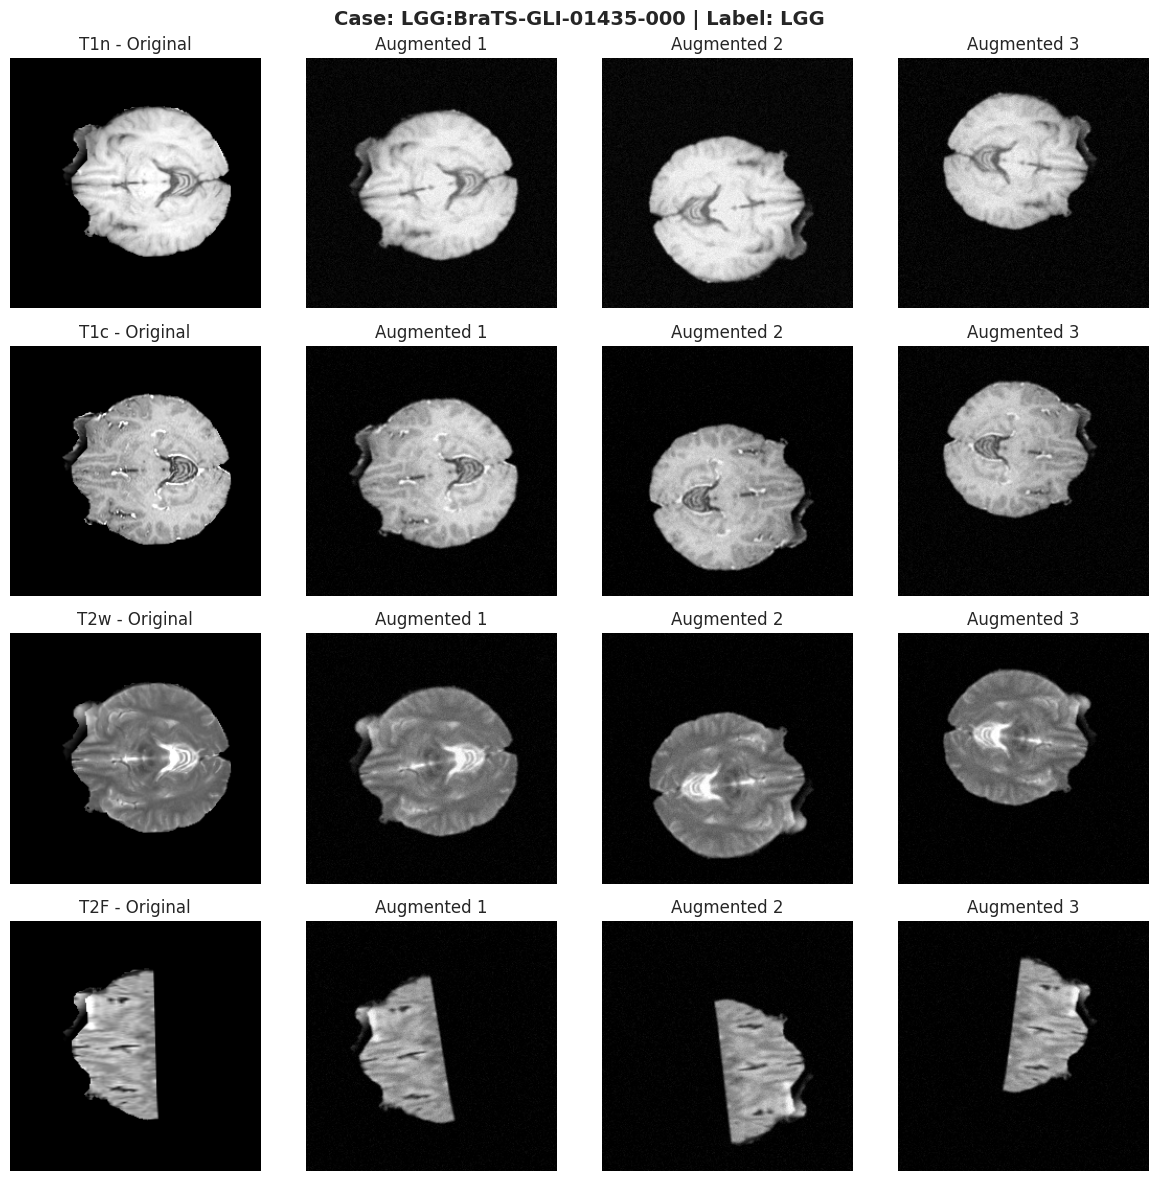

   Example 1: LGG:BraTS-GLI-01435-000 (LGG)


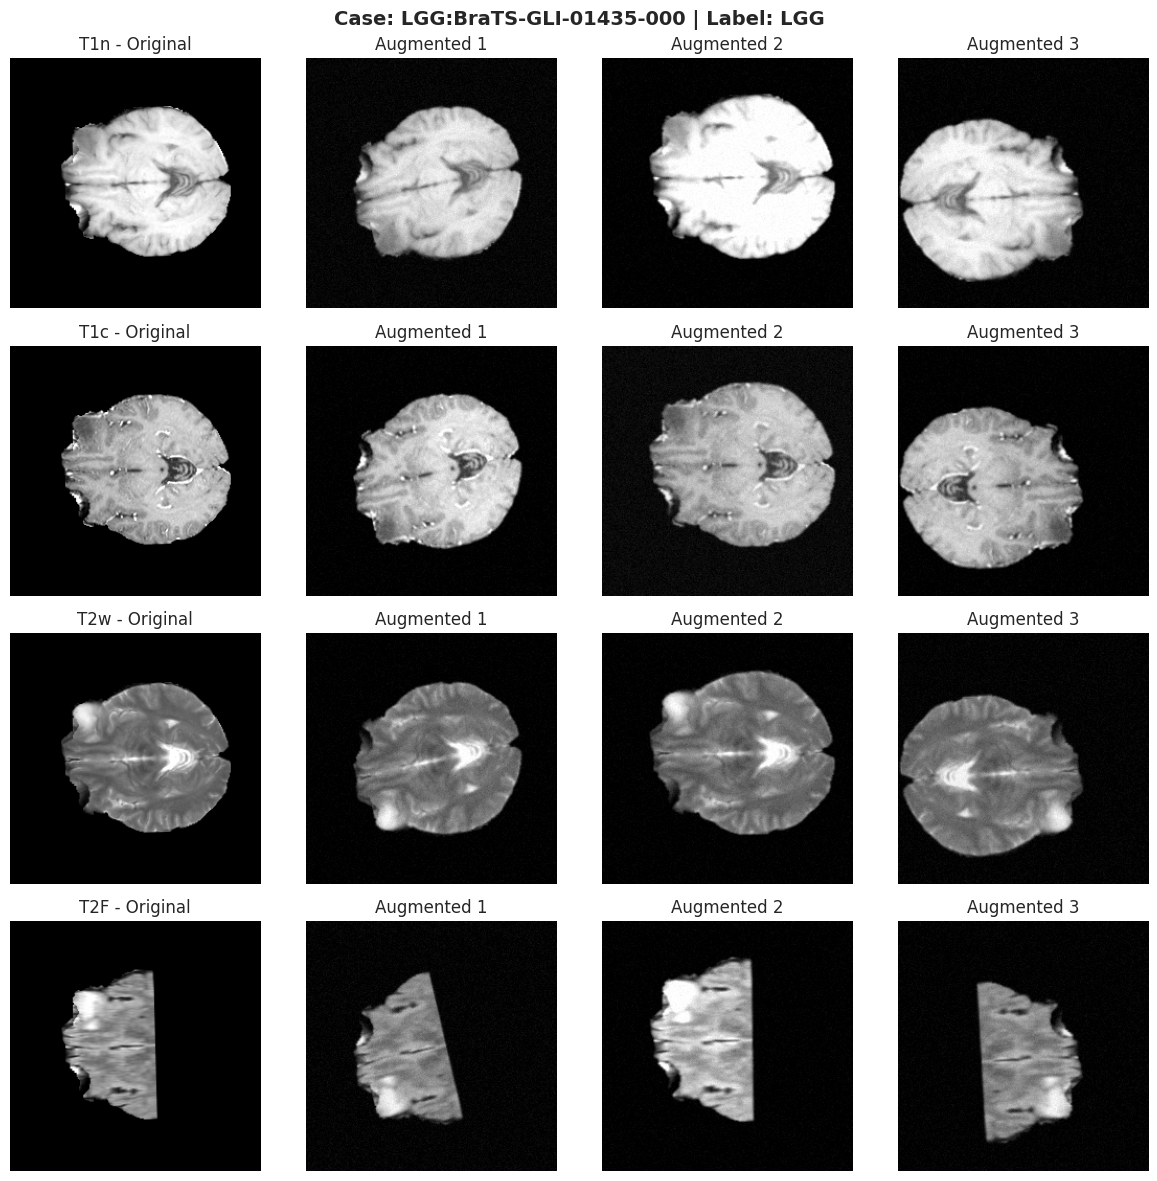

   Example 2: LGG:BraTS-GLI-01435-000 (LGG)


In [15]:
# ============================================================================
# STEP 12: VISUALIZE AUGMENTATION
# ============================================================================

def visualize_augmentation(generator, case_index, num_examples=2):
    """
    Show original vs augmented versions of slices.
    """
    print("\n🎨 Visualizing augmentation effects...")
    
    for example_idx in range(num_examples):
        # Get a sample
        case_id, slice_idx, label = generator.samples[example_idx]
        label_name = cfg.CLASS_NAMES[label]
        
        # Load original (no augmentation)
        slice_original = generator._load_slice(case_id, slice_idx)
        
        # Generate 3 augmented versions
        augmented_versions = []
        for _ in range(3):
            aug = generator.augmentor.augment_4channel(slice_original.copy())
            augmented_versions.append(aug)
        
        # Plot
        fig, axes = plt.subplots(4, 4, figsize=(12, 12))
        modality_names = ["T1n", "T1c", "T2w", "T2F"]
        
        for mod_idx in range(4):
            # Original
            axes[mod_idx, 0].imshow(slice_original[:, :, mod_idx], cmap='gray')
            axes[mod_idx, 0].set_title(f"{modality_names[mod_idx]} - Original")
            axes[mod_idx, 0].axis('off')
            
            # Augmented versions
            for aug_idx in range(3):
                axes[mod_idx, aug_idx + 1].imshow(augmented_versions[aug_idx][:, :, mod_idx], cmap='gray')
                axes[mod_idx, aug_idx + 1].set_title(f"Augmented {aug_idx + 1}")
                axes[mod_idx, aug_idx + 1].axis('off')
        
        plt.suptitle(f"Case: {case_id} | Label: {label_name}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"   Example {example_idx + 1}: {case_id} ({label_name})")


# Visualize
visualize_augmentation(train_gen, clean_case_index, num_examples=2)

In [16]:
# =============================================================================
# CELL 1 — SHOW CURRENT TRAIN SLICE COUNTS (FROM YOUR EXISTING train_samples)
# =============================================================================
from collections import Counter

def show_slice_counts(samples, name="Train"):
    labels = [lbl for (_, _, lbl) in samples]
    c = Counter(labels)
    total = len(labels)
    print(f"📌 {name} slices: {total}")
    print(f"   HGG (0): {c.get(0,0)}")
    print(f"   LGG (1): {c.get(1,0)}")
    if c.get(1,0) > 0:
        print(f"   Imbalance (HGG:LGG) = {c.get(0,0)/c.get(1,0):.2f}:1")
    print()

show_slice_counts(train_samples, "Train")
show_slice_counts(val_samples,   "Val")
show_slice_counts(test_samples,  "Test")


📌 Train slices: 3056
   HGG (0): 2172
   LGG (1): 884
   Imbalance (HGG:LGG) = 2.46:1

📌 Val slices: 660
   HGG (0): 456
   LGG (1): 204
   Imbalance (HGG:LGG) = 2.24:1

📌 Test slices: 655
   HGG (0): 468
   LGG (1): 187
   Imbalance (HGG:LGG) = 2.50:1



In [17]:
# =============================================================================
# CELL — Oversample LGG so that LGG = 1.5 * HGG (slice-level oversampling)
# =============================================================================
import numpy as np
from collections import Counter

def oversample_minority_to_ratio(samples, minority_label=1, majority_label=0, ratio=1.5, seed=42):
    """
    Oversample minority class to reach:
        minority_count = ratio * majority_count
    Example: ratio=1.5 => LGG = 1.5 * HGG

    samples: list of (case_id, slice_idx, label)
    """
    rng = np.random.default_rng(seed)

    maj = [s for s in samples if s[2] == majority_label]
    min_ = [s for s in samples if s[2] == minority_label]

    n_maj = len(maj)
    n_min = len(min_)
    if n_min == 0:
        raise ValueError("Minority class has 0 samples; cannot oversample.")

    target_min = int(np.round(ratio * n_maj))

    if target_min <= n_min:
        # Already above target; downsample to target (rare for your case)
        idx = rng.choice(n_min, size=target_min, replace=False)
        min_new = [min_[i] for i in idx]
    else:
        extra = target_min - n_min
        idx = rng.choice(n_min, size=extra, replace=True)
        min_new = min_ + [min_[i] for i in idx]

    out = maj + min_new
    rng.shuffle(out)
    return out

def show_counts(samples, name="Train"):
    c = Counter([lbl for (_,_,lbl) in samples])
    n0 = c.get(0,0); n1 = c.get(1,0)
    print(f"📌 {name} slices: {len(samples)}")
    print(f"   HGG (0): {n0}")
    print(f"   LGG (1): {n1}")
    if n0 > 0:
        print(f"   LGG/HGG = {n1/n0:.2f}x")
    print()

# Create the 1.5x oversampled training samples
train_samples_lgg_15x = oversample_minority_to_ratio(
    train_samples,
    minority_label=1,  # LGG
    majority_label=0,  # HGG
    ratio=2.5,
    seed=cfg.RANDOM_SEED
)

print("✅ Before:")
show_counts(train_samples, "Train (original)")

print("✅ After (LGG = 1.5× HGG):")
show_counts(train_samples_lgg_15x, "Train (oversampled)")


✅ Before:
📌 Train (original) slices: 3056
   HGG (0): 2172
   LGG (1): 884
   LGG/HGG = 0.41x

✅ After (LGG = 1.5× HGG):
📌 Train (oversampled) slices: 7602
   HGG (0): 2172
   LGG (1): 5430
   LGG/HGG = 2.50x



In [18]:
# =============================================================================
# CELL — Rebuild train generator with LGG=1.5×HGG
# =============================================================================
train_gen_os = BrainTumorDataGenerator(
    samples=train_samples_lgg_15x,
    case_index=clean_case_index,
    cfg=cfg,
    augmentor=augmentor,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    augment=True
)

print(f"✅ Train generator (LGG=1.5×HGG): {len(train_gen_os)} batches | {len(train_gen_os)} slices")


✅ Train generator (LGG=1.5×HGG): 238 batches | 238 slices


# EfficientNet-B0

In [26]:
# ============================================================
# CELL 1 — Imports for EfficientNet staged training/evaluation
# ============================================================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [24]:
# ============================================================
# CELL 2 — Helpers: learning curves + evaluation (slice + case)
# ============================================================
def plot_learning_curves(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "accuracy" in hist:
        plt.figure(figsize=(7,5))
        plt.plot(epochs, hist["accuracy"], label="train_acc")
        plt.plot(epochs, hist["val_accuracy"], label="val_acc")
        plt.title(f"{title_prefix} Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if "auc" in hist:
        plt.figure(figsize=(7,5))
        plt.plot(epochs, hist["auc"], label="train_auc")
        plt.plot(epochs, hist["val_auc"], label="val_auc")
        plt.title(f"{title_prefix} AUC")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.legend()
        plt.tight_layout()
        plt.show()

def plot_cm(y_true, y_pred, title, class_names=cfg.CLASS_NAMES, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm, annot=True, fmt=".2f" if normalize else "d",
        cmap="Blues", xticklabels=class_names, yticklabels=class_names
    )
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=cfg.NUM_CLASSES):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=cfg.NUM_CLASSES))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

def case_level_mean_prob(y_prob_slice, case_keys, clean_case_index):
    df = pd.DataFrame({
        "case_key": case_keys,
        "p_hgg": y_prob_slice[:, 0],
        "p_lgg": y_prob_slice[:, 1],
    })
    mean_probs = df.groupby("case_key")[["p_hgg", "p_lgg"]].mean()
    y_pred_case = mean_probs.values.argmax(axis=1).astype(int)
    y_true_case = mean_probs.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"]).values.astype(int)
    return y_true_case, y_pred_case, mean_probs

def eval_all(model, stage_title, test_gen, clean_case_index):
    print("\n" + "="*80)
    print(f"📊 EVALUATION — {stage_title}")
    print("="*80)

    vals = model.evaluate(test_gen, verbose=1)
    print("\nKeras metrics:", dict(zip(model.metrics_names, vals)))

    y_true_slice, y_pred_slice, y_prob_slice, case_keys = predict_with_metadata(model, test_gen)

    print("\n--- SLICE LEVEL ---")
    print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
    print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))
    plot_cm(y_true_slice, y_pred_slice, f"{stage_title} — Slice CM", normalize=False)
    plot_cm(y_true_slice, y_pred_slice, f"{stage_title} — Slice CM", normalize=True)

    y_true_case_v, y_pred_case_v = case_level_vote(y_pred_slice, case_keys, clean_case_index)
    print("\n--- CASE LEVEL (Majority Vote) ---")
    print(f"Accuracy: {accuracy_score(y_true_case_v, y_pred_case_v)*100:.2f}%\n")
    print(classification_report(y_true_case_v, y_pred_case_v, target_names=CLASS_NAMES, digits=4))
    plot_cm(y_true_case_v, y_pred_case_v, f"{stage_title} — Case CM (Vote)", normalize=False)
    plot_cm(y_true_case_v, y_pred_case_v, f"{stage_title} — Case CM (Vote)", normalize=True)

    y_true_case_p, y_pred_case_p, _ = case_level_mean_prob(y_prob_slice, case_keys, clean_case_index)
    print("\n--- CASE LEVEL (Mean Probability) ---")
    print(f"Accuracy: {accuracy_score(y_true_case_p, y_pred_case_p)*100:.2f}%\n")
    print(classification_report(y_true_case_p, y_pred_case_p, target_names=CLASS_NAMES, digits=4))
    plot_cm(y_true_case_p, y_pred_case_p, f"{stage_title} — Case CM (MeanProb)", normalize=False)
    plot_cm(y_true_case_p, y_pred_case_p, f"{stage_title} — Case CM (MeanProb)", normalize=True)


In [22]:
# ============================================================
# CELL — Model builder with configurable dropout
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

INPUT_SHAPE = (240,240,4)

def build_effnet_b0_4ch(
    input_shape=INPUT_SHAPE,
    num_classes=2,
    adapter_filters=32,
    l2_reg=1e-4,          # ↓ recommend smaller than 1e-2
    dropout1=0.6,         # configurable
    dropout2=0.4,         # configurable
    use_effnet_preprocess=False,   # IMPORTANT (MRI usually better without ImageNet preprocess)
):
    inp = layers.Input(shape=input_shape, name="inp_4ch")

    # Adapter 4ch -> 3ch
    x = layers.Conv2D(adapter_filters, 3, padding="same", activation="relu", name="adapter_conv3x3")(inp)
    x = layers.BatchNormalization(name="adapter_bn")(x)
    x = layers.Conv2D(3, 1, padding="same", activation="linear", name="adapter_to3")(x)

    # Preprocess (optional)
    if use_effnet_preprocess:
        x = tf.keras.applications.efficientnet.preprocess_input(x)

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_shape[0], input_shape[1], 3)
    )
    backbone.trainable = False

    y = backbone(x, training=False)

    y = layers.GlobalAveragePooling2D(name="gap")(y)
    y = layers.Dropout(dropout1, name="drop1")(y)

    y = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg),
        name="dense256"
    )(y)
    y = layers.BatchNormalization(name="bn_head")(y)
    y = layers.Dropout(dropout2, name="drop2")(y)

    out = layers.Dense(num_classes, activation="softmax", name="pred")(y)

    model = models.Model(inp, out, name="EffNetB0_4ch")
    return model, backbone


In [23]:
# ============================================================
# CELL — Compile + callbacks
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks(stage_name):
    return [
        ModelCheckpoint(
            filepath=f"best_effnet_{stage_name}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=6,
            restore_best_weights=True,
            verbose=1
        )
    ]


I0000 00:00:1771499413.600254      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EffNetB0_4ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp_4ch (InputLayer)            │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_conv3x3 (Conv2D)        │ (None, 240, 240, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_bn (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_to3 (Conv2D)            │ (None, 240, 240, 3)    │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,456 (16.71 MB)

 Trainable params: 330,309 (1.26 MB)

 Non-trainable params: 4,050,147 (15.45 MB)

None
Epoch 1/20


I0000 00:00:1771499433.792172     148 service.cc:152] XLA service 0x7f766c002aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771499433.792215     148 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771499436.848649     148 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771499457.042375     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.6183 - auc: 0.6554 - loss: 0.8702 - precision: 0.6183 - recall: 0.6183
Epoch 1: val_auc improved from -inf to 0.39945, saving model to best_effnet_stage0_frozen_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.6186 - auc: 0.6558 - loss: 0.8695 - precision: 0.6186 - recall: 0.6186 - val_accuracy: 0.3091 - val_auc: 0.3994 - val_loss: 1.0521 - val_precision: 0.3091 - val_recall: 0.3091 - learning_rate: 0.0010
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.7928 - auc: 0.8609 - loss: 0.5167 - precision: 0.7928 - recall: 0.7928
Epoch 2: val_auc improved from 0.39945 to 0.56025, saving model to best_effnet_stage0_frozen_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 177s 741ms/step - accuracy: 0.7929 - auc: 0.8609 - loss: 0.5166 - precision: 0.7929 - recall: 0.7929 - val_accuracy: 0.4788 - val_auc: 0.5602 - val_loss: 0.8803 - val_precision: 0.4788 - val_recall: 0.4788 - learning_rate: 0.0010
Epoch

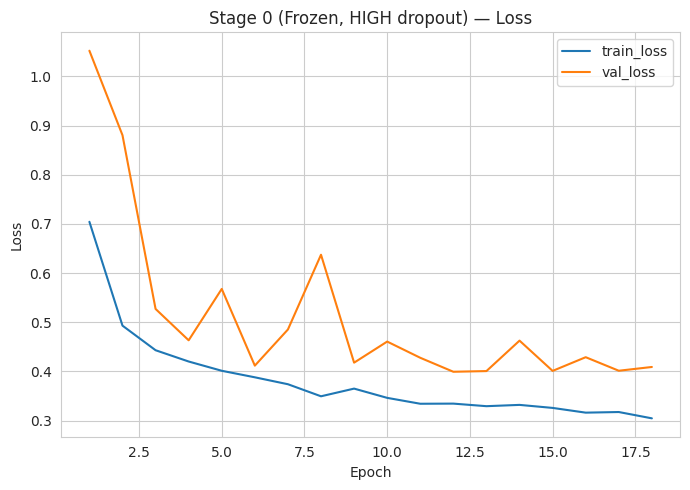

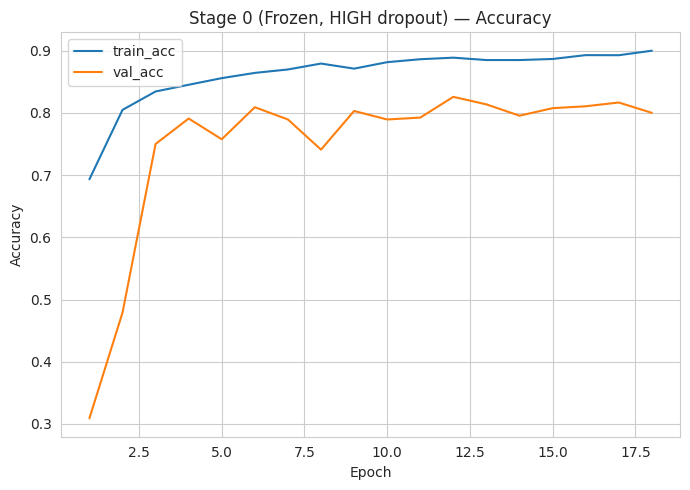

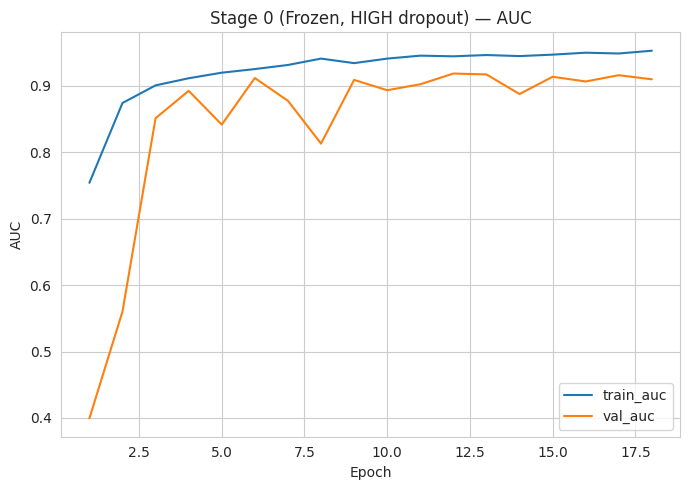


📊 EVALUATION — Stage 0 (Frozen, HIGH dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8235 - auc: 0.9022 - loss: 0.4486 - precision: 0.8235 - recall: 0.8235

Keras metrics: {'loss': 0.45246240496635437, 'compile_metrics': 0.8259541988372803}
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 542ms/step

--- SLICE LEVEL ---
Accuracy: 82.60%

              precision    recall  f1-score   support

         HGG     0.9023    0.8483    0.8744       468
         LGG     0.6698    0.7701    0.7164       187

    accuracy                         0.8260       655
   macro avg     0.7860    0.8092    0.7954       655
weighted avg     0.8359    0.8260    0.8293       655



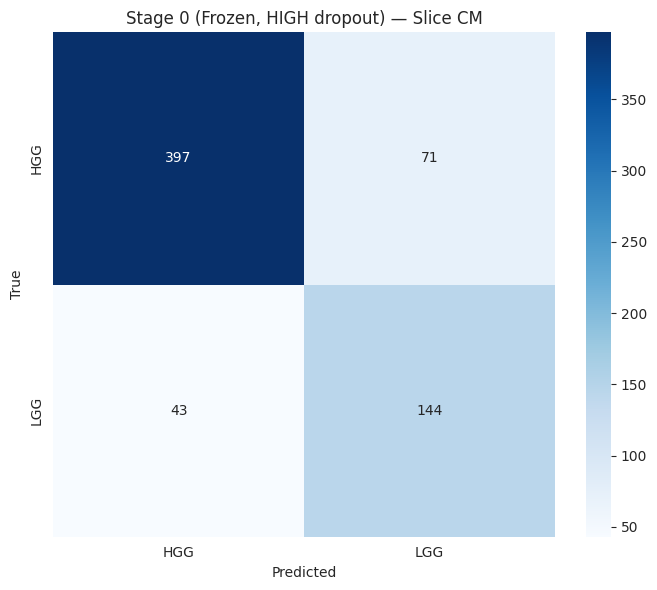

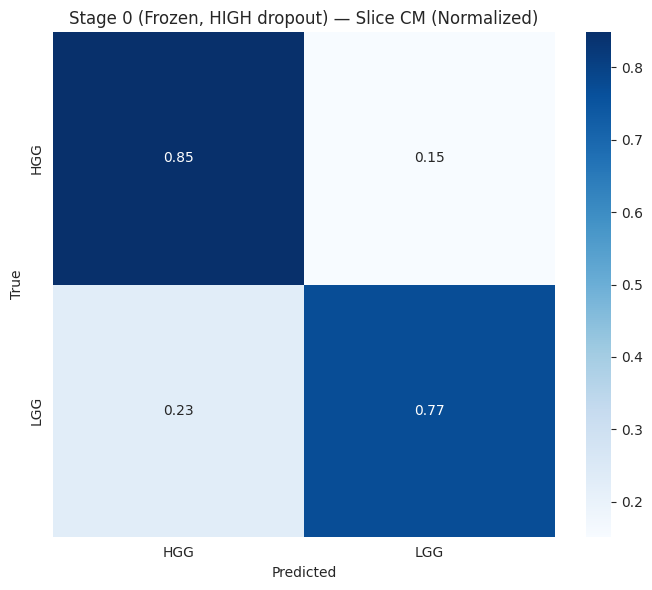


--- CASE LEVEL (Majority Vote) ---
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9474    0.9231    0.9351        39
         LGG     0.7500    0.8182    0.7826        11

    accuracy                         0.9000        50
   macro avg     0.8487    0.8706    0.8588        50
weighted avg     0.9039    0.9000    0.9015        50



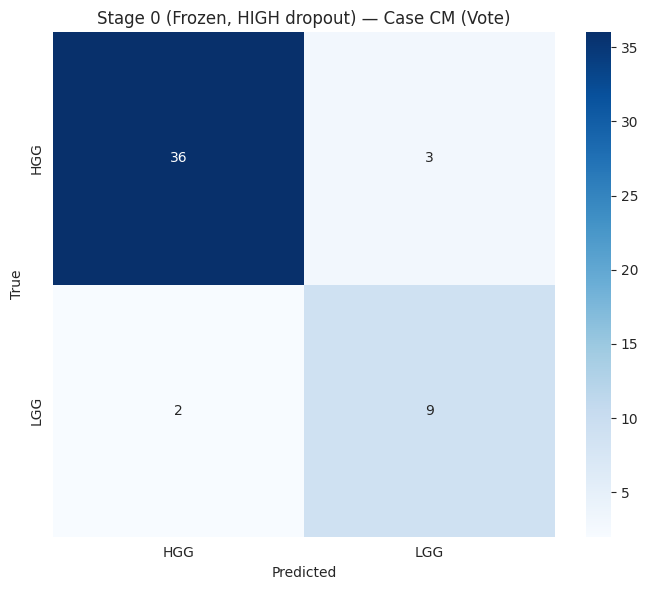

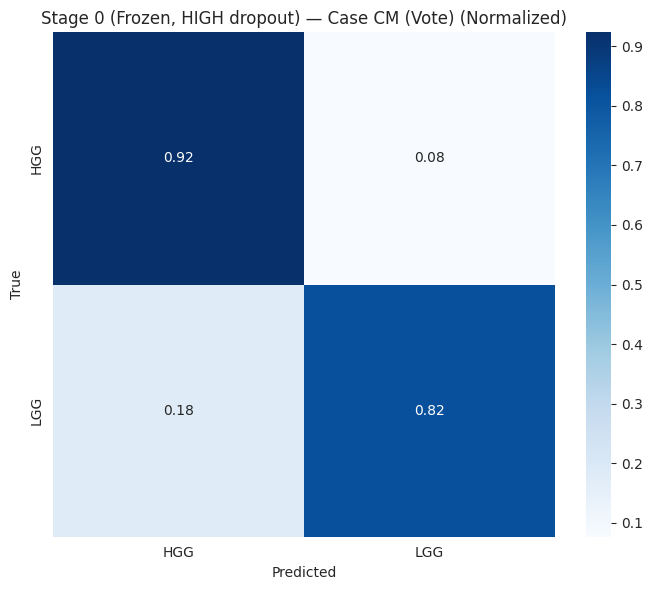


--- CASE LEVEL (Mean Probability) ---
Accuracy: 88.00%

              precision    recall  f1-score   support

         HGG     0.9459    0.8974    0.9211        39
         LGG     0.6923    0.8182    0.7500        11

    accuracy                         0.8800        50
   macro avg     0.8191    0.8578    0.8355        50
weighted avg     0.8901    0.8800    0.8834        50



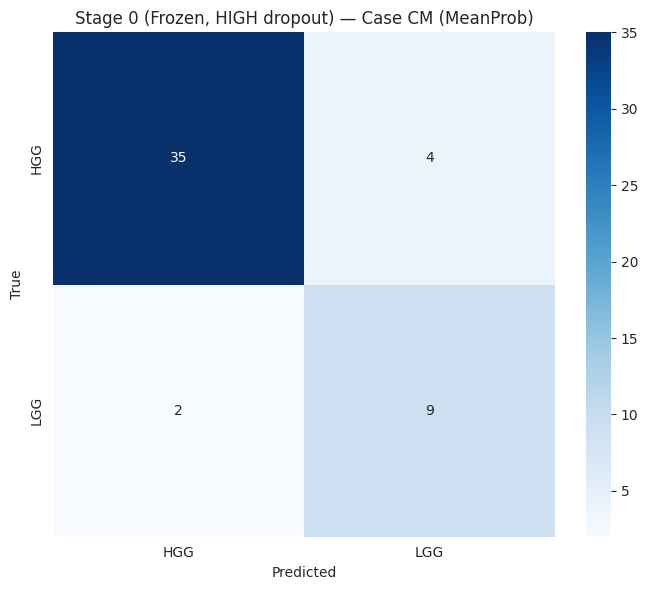

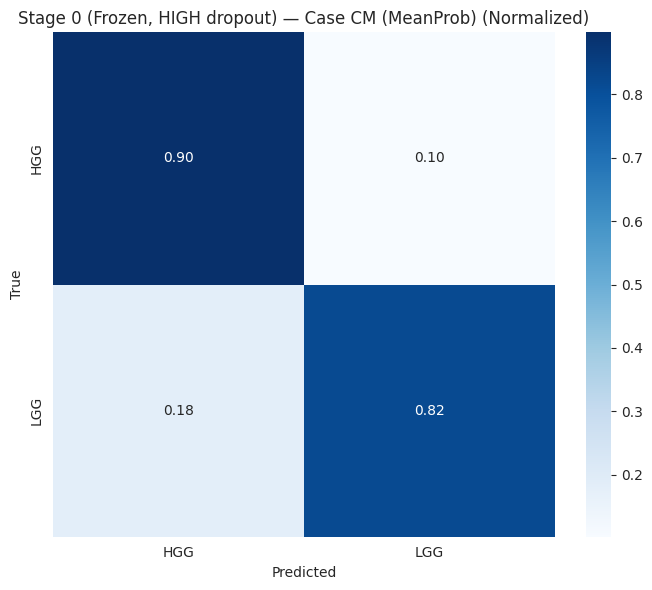

✅ Saved Stage 0 weights.


In [24]:
# ============================================================
# CELL — STAGE 0: Frozen backbone, HIGH dropout
# ============================================================
HIGH_D1, HIGH_D2 = 0.5, 0.4   # higher dropout (you can adjust)

model0, backbone0 = build_effnet_b0_4ch(
    dropout1=HIGH_D1,
    dropout2=HIGH_D2,
    l2_reg=1e-4,                 # recommended
    use_effnet_preprocess=False  # recommended for MRI
)
compile_model(model0, lr=1e-3)

print(model0.summary())

history0 = model0.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks("stage0_frozen_highdrop"),
    verbose=1
)

plot_learning_curves(history0, title_prefix="Stage 0 (Frozen, HIGH dropout) —")
eval_all(model0, "Stage 0 (Frozen, HIGH dropout)", test_gen, clean_case_index)

# Save weights to transfer into Stage 1 model
model0.save_weights("stage0_highdrop_weights.weights.h5")
print("✅ Saved Stage 0 weights.")


In [25]:
# ============================================================
# CELL — Build STAGE 1 model with LOWER dropout + load Stage 0 weights
# ============================================================
LOW_D1, LOW_D2 = 0.3, 0.2   # lower dropout for fine-tuning

model1, backbone1 = build_effnet_b0_4ch(
    dropout1=LOW_D1,
    dropout2=LOW_D2,
    l2_reg=1e-4,
    use_effnet_preprocess=False
)

# IMPORTANT: load weights from stage0
model1.load_weights("stage0_highdrop_weights.weights.h5")
print("✅ Loaded Stage 0 weights into Stage 1 model.")


✅ Loaded Stage 0 weights into Stage 1 model.


In [26]:
# ============================================================
# CELL — Fine-tuning setup: unfreeze last N layers safely
# ============================================================
def unfreeze_last_n_layers(backbone, n=40):
    """
    Unfreeze last n layers of backbone, keep earlier layers frozen.
    Also keep BatchNorm layers frozen (recommended in medical imaging FT).
    """
    backbone.trainable = True

    # Freeze all first
    for layer in backbone.layers:
        layer.trainable = False

    # Unfreeze last N (except BatchNorm)
    for layer in backbone.layers[-n:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Unfreeze last layers
unfreeze_last_n_layers(backbone1, n=40)

# Compile with small LR
compile_model(model1, lr=1e-5)

# Quick check trainable params
trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model1.trainable_weights])
non_trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model1.non_trainable_weights])
print("Trainable params:", trainable_count)
print("Non-trainable params:", non_trainable_count)


Trainable params: 2367829
Non-trainable params: 2012627.0


Epoch 1/20


2026-02-19 12:08:27.678374: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 12:08:27.885698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 12:08:28.157343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 12:08:28.363641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


166/238 ━━━━━━━━━━━━━━━━━━━━ 49s 681ms/step - accuracy: 0.8888 - auc: 0.9500 - loss: 0.3181 - precision: 0.8888 - recall: 0.8888

2026-02-19 12:10:38.949217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 12:10:39.158379: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 12:10:39.432330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 12:10:39.641050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.8913 - auc: 0.9514 - loss: 0.3138 - precision: 0.8913 - recall: 0.8913
Epoch 1: val_auc improved from -inf to 0.91368, saving model to best_effnet_stage1_finetune_lowdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 230s 830ms/step - accuracy: 0.8914 - auc: 0.9514 - loss: 0.3137 - precision: 0.8914 - recall: 0.8914 - val_accuracy: 0.8121 - val_auc: 0.9137 - val_loss: 0.4248 - val_precision: 0.8121 - val_recall: 0.8121 - learning_rate: 1.0000e-05
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.9042 - auc: 0.9611 - loss: 0.2838 - precision: 0.9042 - recall: 0.9042
Epoch 2: val_auc did not improve from 0.91368
238/238 ━━━━━━━━━━━━━━━━━━━━ 169s 711ms/step - accuracy: 0.9042 - auc: 0.9611 - loss: 0.2838 - precision: 0.9042 - recall: 0.9042 - val_accuracy: 0.8106 - val_auc: 0.9130 - val_loss: 0.4216 - val_precision: 0.8106 - val_recall: 0.8106 - learning_rate: 1.0000e-05
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step -

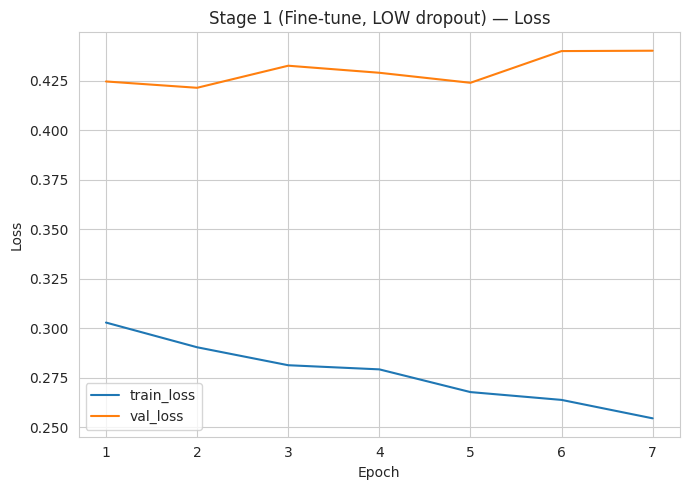

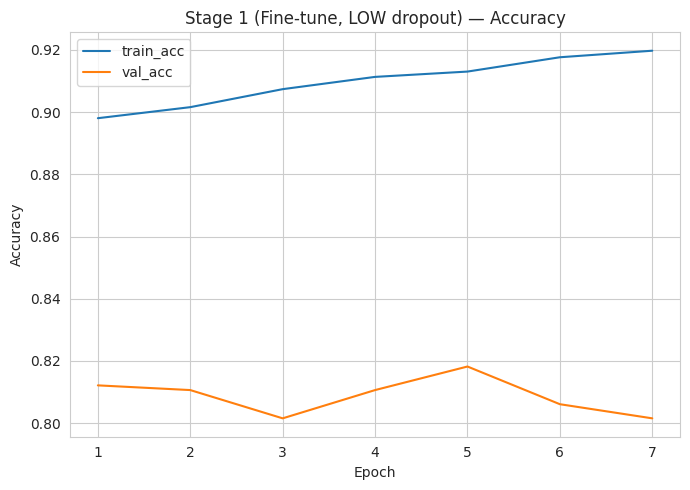

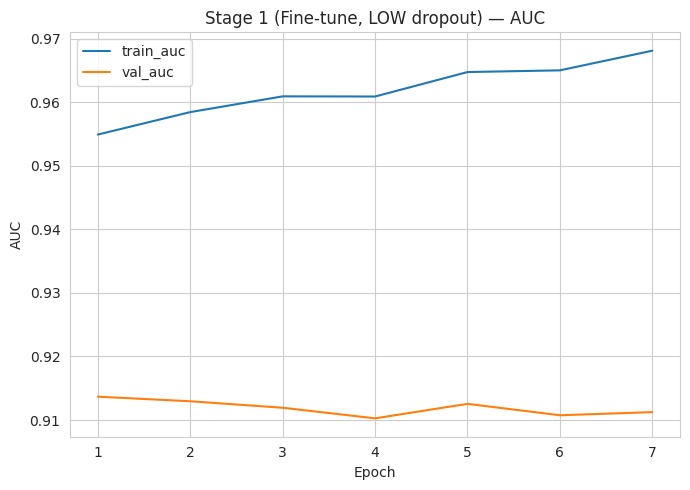


📊 EVALUATION — Stage 1 (Fine-tune, LOW dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 552ms/step - accuracy: 0.8022 - auc: 0.8849 - loss: 0.5184 - precision: 0.8022 - recall: 0.8022

Keras metrics: {'loss': 0.48816680908203125, 'compile_metrics': 0.8244274854660034}
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step

--- SLICE LEVEL ---
Accuracy: 82.44%

              precision    recall  f1-score   support

         HGG     0.8747    0.8803    0.8775       468
         LGG     0.6957    0.6845    0.6900       187

    accuracy                         0.8244       655
   macro avg     0.7852    0.7824    0.7838       655
weighted avg     0.8236    0.8244    0.8240       655



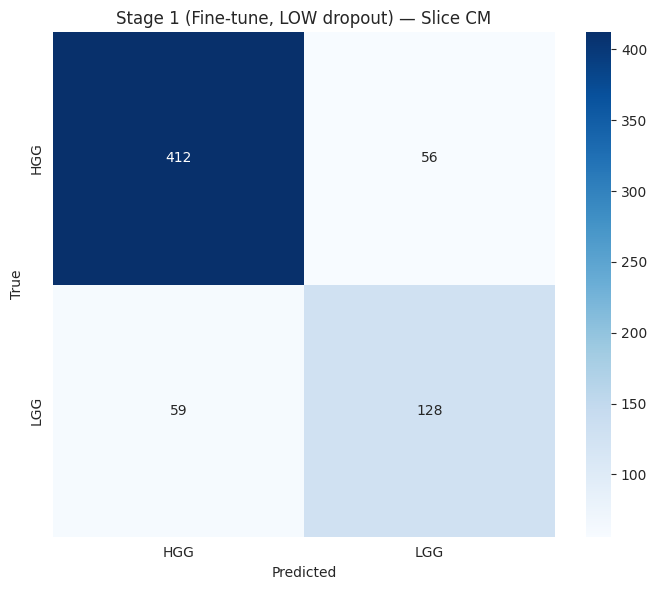

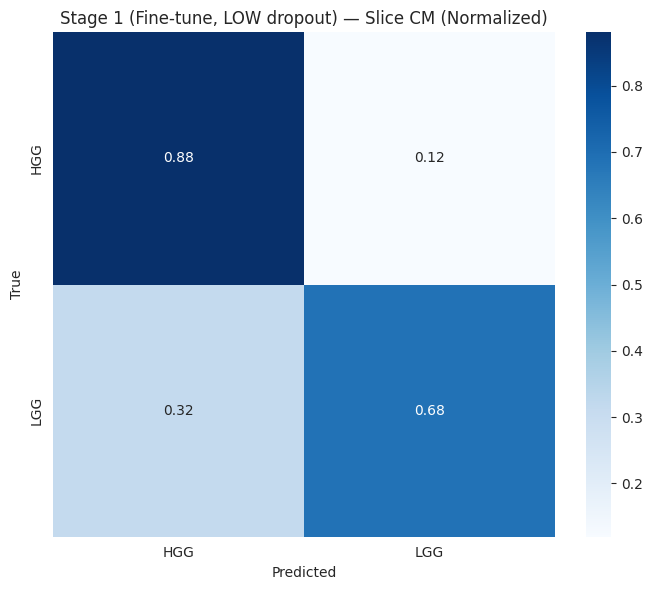


--- CASE LEVEL (Majority Vote) ---
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9474    0.9231    0.9351        39
         LGG     0.7500    0.8182    0.7826        11

    accuracy                         0.9000        50
   macro avg     0.8487    0.8706    0.8588        50
weighted avg     0.9039    0.9000    0.9015        50



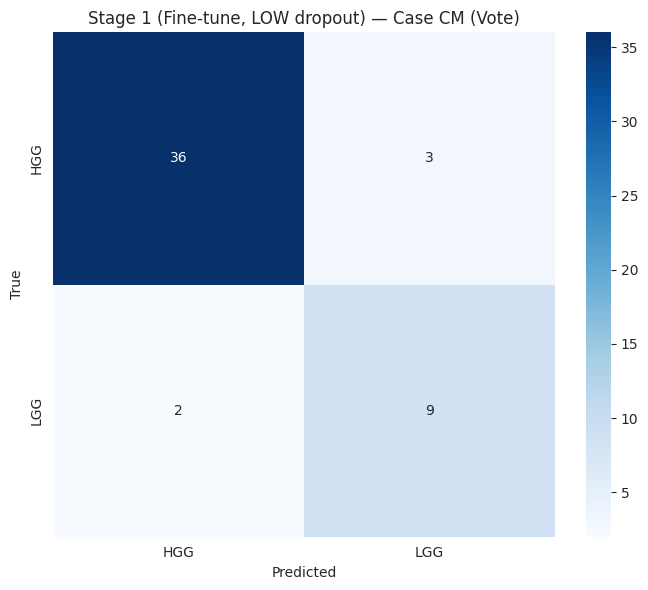

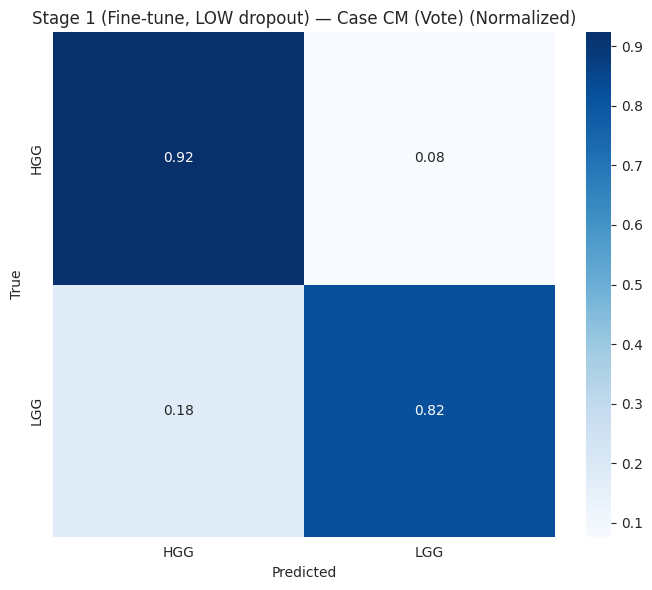


--- CASE LEVEL (Mean Probability) ---
Accuracy: 88.00%

              precision    recall  f1-score   support

         HGG     0.9459    0.8974    0.9211        39
         LGG     0.6923    0.8182    0.7500        11

    accuracy                         0.8800        50
   macro avg     0.8191    0.8578    0.8355        50
weighted avg     0.8901    0.8800    0.8834        50



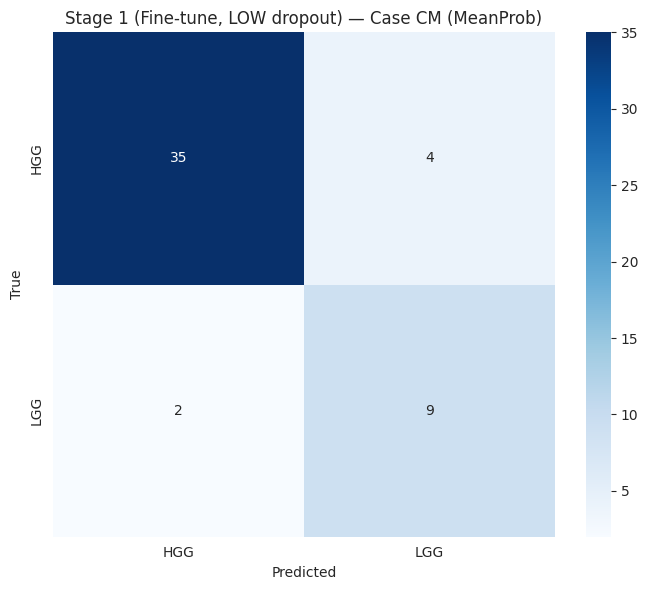

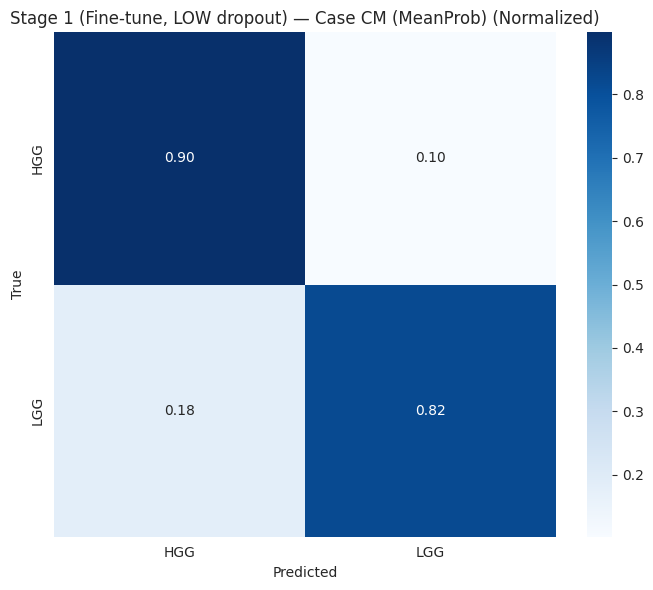

In [27]:
# ============================================================
# CELL — STAGE 1: Fine-tune with LOWER dropout
# ============================================================
history1 = model1.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks("stage1_finetune_lowdrop"),
    verbose=1
)

plot_learning_curves(history1, title_prefix="Stage 1 (Fine-tune, LOW dropout) —")
eval_all(model1, "Stage 1 (Fine-tune, LOW dropout)", test_gen, clean_case_index)


# custom CNN

In [34]:
# ============================================================
# CELL — Custom CNN builder (dropout configurable)
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

INPUT_SHAPE = (240,240,4)

def conv_block(x, filters, k=3, s=1, wd=1e-4, name=""):
    x = layers.Conv2D(filters, k, strides=s, padding="same",
                      kernel_regularizer=regularizers.l2(wd),
                      use_bias=False, name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    return x

def se_block(x, se_ratio=0.25, name=""):
    """Squeeze-and-Excitation block (cheap + helps)"""
    ch = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f"{name}_se_gap")(x)
    se = layers.Dense(max(1, int(ch * se_ratio)), activation="relu", name=f"{name}_se_fc1")(se)
    se = layers.Dense(ch, activation="sigmoid", name=f"{name}_se_fc2")(se)
    se = layers.Reshape((1,1,ch), name=f"{name}_se_reshape")(se)
    return layers.Multiply(name=f"{name}_se_mul")([x, se])

def build_custom_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=2,
    base=32,                 # width of network
    wd=1e-4,                 # weight decay
    drop_feat=0.5,           # dropout inside feature extractor
    drop_head=0.5,           # dropout before final classifier
    use_se=True
):
    inp = layers.Input(shape=input_shape, name="inp_4ch")

    # ----- Stem -----
    x = conv_block(inp, base,   k=3, s=2, wd=wd, name="stem1")   # 240 -> 120
    x = conv_block(x,   base,   k=3, s=1, wd=wd, name="stem2")
    x = layers.MaxPooling2D(pool_size=2, name="stem_pool")(x)    # 120 -> 60
    x = layers.Dropout(drop_feat, name="drop_feat_1")(x)

    # ----- Stage 1 -----
    x = conv_block(x, base*2, k=3, s=1, wd=wd, name="b1_1")
    x = conv_block(x, base*2, k=3, s=1, wd=wd, name="b1_2")
    if use_se: x = se_block(x, name="b1")
    x = layers.MaxPooling2D(pool_size=2, name="b1_pool")(x)      # 60 -> 30
    x = layers.Dropout(drop_feat, name="drop_feat_2")(x)

    # ----- Stage 2 -----
    x = conv_block(x, base*4, k=3, s=1, wd=wd, name="b2_1")
    x = conv_block(x, base*4, k=3, s=1, wd=wd, name="b2_2")
    if use_se: x = se_block(x, name="b2")
    x = layers.MaxPooling2D(pool_size=2, name="b2_pool")(x)      # 30 -> 15
    x = layers.Dropout(drop_feat, name="drop_feat_3")(x)

    # ----- Stage 3 -----
    x = conv_block(x, base*6, k=3, s=1, wd=wd, name="b3_1")
    x = conv_block(x, base*6, k=3, s=1, wd=wd, name="b3_2")
    if use_se: x = se_block(x, name="b3")

    # ----- Head -----
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(wd),
                     name="dense256")(x)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dropout(drop_head, name="drop_head")(x)

    out = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    model = models.Model(inp, out, name="CustomCNN_4ch")
    return model


In [35]:
# ============================================================
# CELL — Compile + callbacks (same style as your EfficientNet)
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks(stage_name):
    return [
        ModelCheckpoint(
            filepath=f"best_customcnn_{stage_name}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=6,
            restore_best_weights=True,
            verbose=1
        )
    ]


Model: "CustomCNN_4ch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inp_4ch             │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_conv (Conv2D) │ (None, 120, 120,  │      1,152 │ inp_4ch[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_bn            │ (None, 120, 120,  │        128 │ stem1_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_relu          │ (None, 120, 120,  │          0 │ stem1_bn[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_conv (Conv2D) │ (None, 120, 120,  │      9,216 │ stem1_relu[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_bn            │ (None, 120, 120,  │        128 │ stem2_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_relu          │ (None, 120, 120,  │          0 │ stem2_bn[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 60, 60,    │          0 │ stem2_relu[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_feat_1         │ (None, 60, 60,    │          0 │ stem_pool[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_1_conv (Conv2D)  │ (None, 60, 60,    │     18,432 │ drop_feat_1[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_1_bn             │ (None, 60, 60,    │        256 │ b1_1_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_1_relu           │ (None, 60, 60,    │          0 │ b1_1_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_2_conv (Conv2D)  │ (None, 60, 60,    │     36,864 │ b1_1_relu[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_2_bn             │ (None, 60, 60,    │        256 │ b1_2_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_2_relu           │ (None, 60, 60,    │          0 │ b1_2_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_se_gap           │ (None, 64)        │          0 │ b1_2_relu[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_se_fc1 (Dense)   │ (None, 16)        │      1,040 │ b1_se_gap[0][0] 

 Total params: 923,234 (3.52 MB)

 Trainable params: 921,058 (3.51 MB)

 Non-trainable params: 2,176 (8.50 KB)

None
Epoch 1/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.7500 - auc: 0.8073 - loss: 0.6867 - precision: 0.7500 - recall: 0.7500
Epoch 1: val_auc improved from -inf to 0.24620, saving model to best_customcnn_stage0_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 217s 835ms/step - accuracy: 0.7501 - auc: 0.8075 - loss: 0.6864 - precision: 0.7501 - recall: 0.7501 - val_accuracy: 0.3091 - val_auc: 0.2462 - val_loss: 1.3183 - val_precision: 0.3091 - val_recall: 0.3091 - learning_rate: 0.0010
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.8327 - auc: 0.8919 - loss: 0.5141 - precision: 0.8327 - recall: 0.8327
Epoch 2: val_auc improved from 0.24620 to 0.55390, saving model to best_customcnn_stage0_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 163s 685ms/step - accuracy: 0.8327 - auc: 0.8919 - loss: 0.5140 - precision: 0.8327 - recall: 0.8327 - val_accuracy: 0.4818 - val_auc: 0.5539 - val_loss: 1.6350 - val_precision: 0.4818 - val_recall: 0.4818 - learning_rate: 0

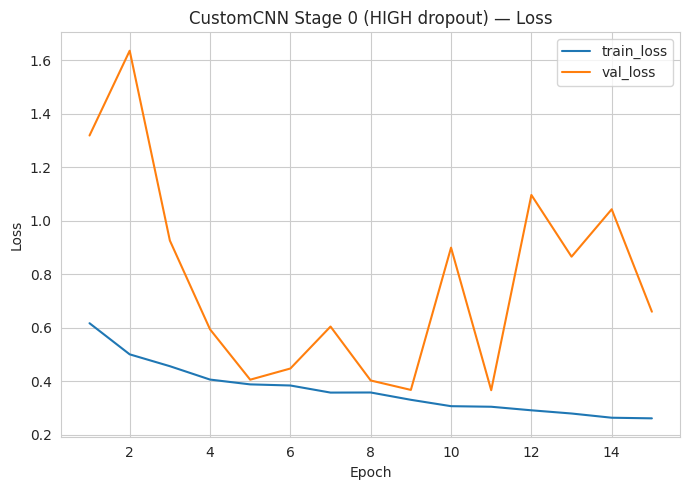

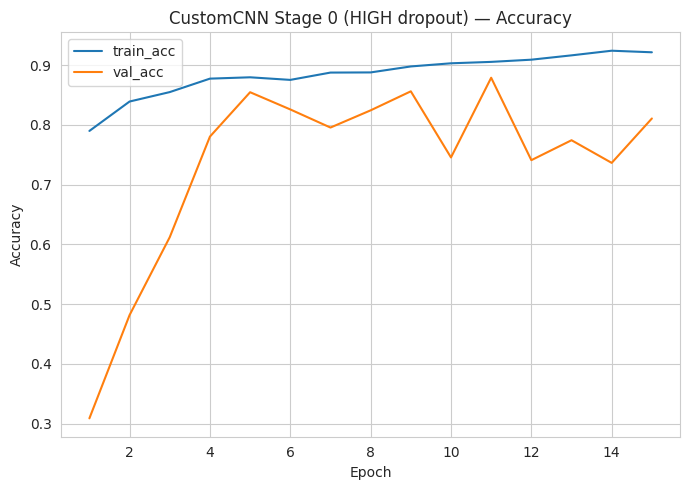

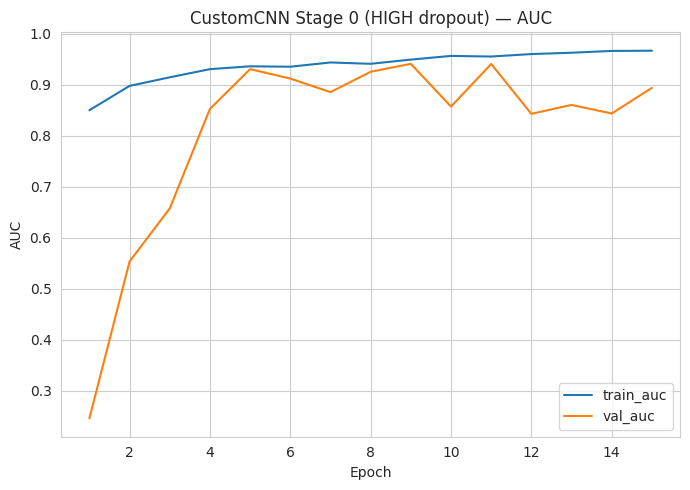


📊 EVALUATION — CustomCNN Stage 0 (HIGH dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.7061 - auc: 0.8219 - loss: 0.6993 - precision: 0.7061 - recall: 0.7061

Keras metrics: {'loss': 0.6002224087715149, 'compile_metrics': 0.7740458250045776}
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step

--- SLICE LEVEL ---
Accuracy: 77.40%

              precision    recall  f1-score   support

         HGG     0.8101    0.8932    0.8496       468
         LGG     0.6403    0.4759    0.5460       187

    accuracy                         0.7740       655
   macro avg     0.7252    0.6845    0.6978       655
weighted avg     0.7616    0.7740    0.7629       655



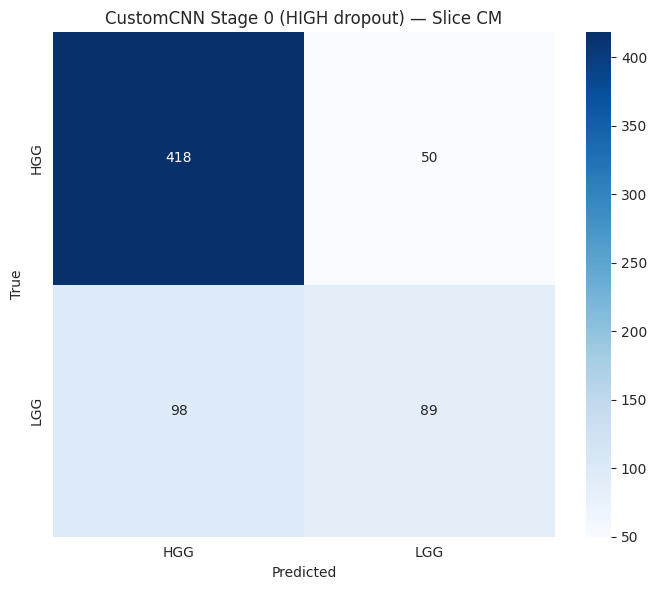

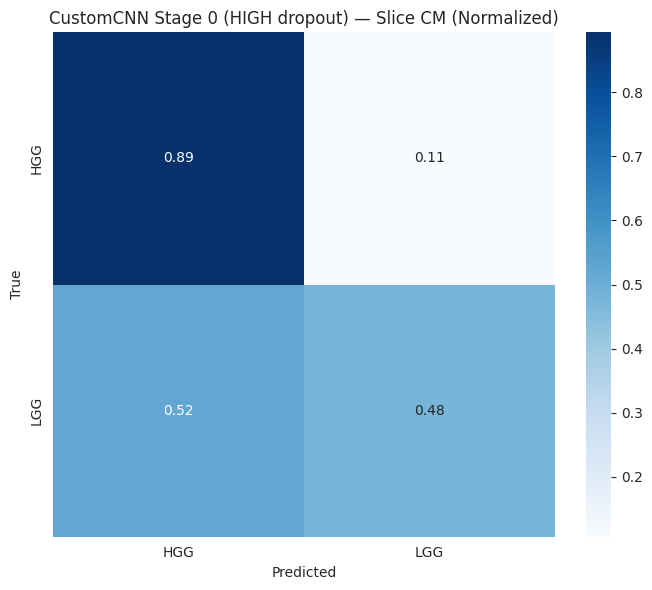


--- CASE LEVEL (Majority Vote) ---
Accuracy: 82.00%

              precision    recall  f1-score   support

         HGG     0.8571    0.9231    0.8889        39
         LGG     0.6250    0.4545    0.5263        11

    accuracy                         0.8200        50
   macro avg     0.7411    0.6888    0.7076        50
weighted avg     0.8061    0.8200    0.8091        50



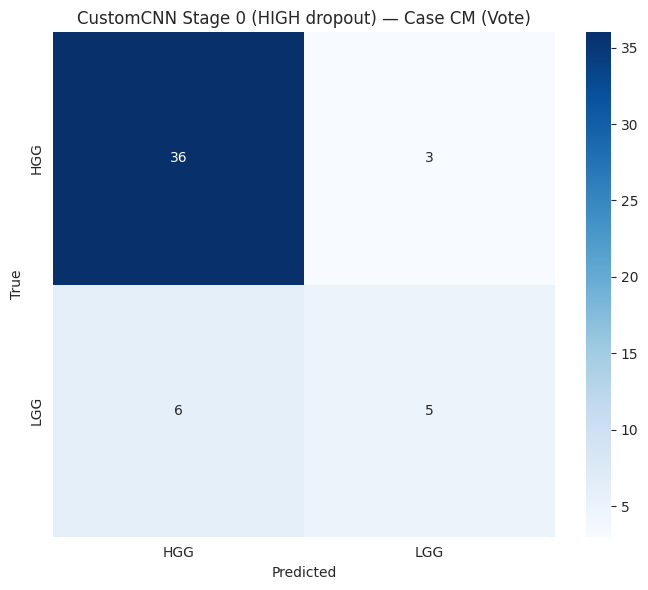

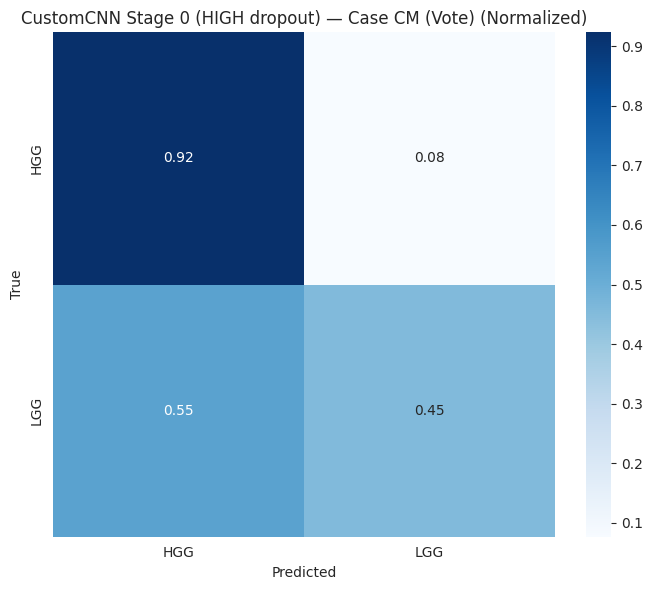


--- CASE LEVEL (Mean Probability) ---
Accuracy: 82.00%

              precision    recall  f1-score   support

         HGG     0.8571    0.9231    0.8889        39
         LGG     0.6250    0.4545    0.5263        11

    accuracy                         0.8200        50
   macro avg     0.7411    0.6888    0.7076        50
weighted avg     0.8061    0.8200    0.8091        50



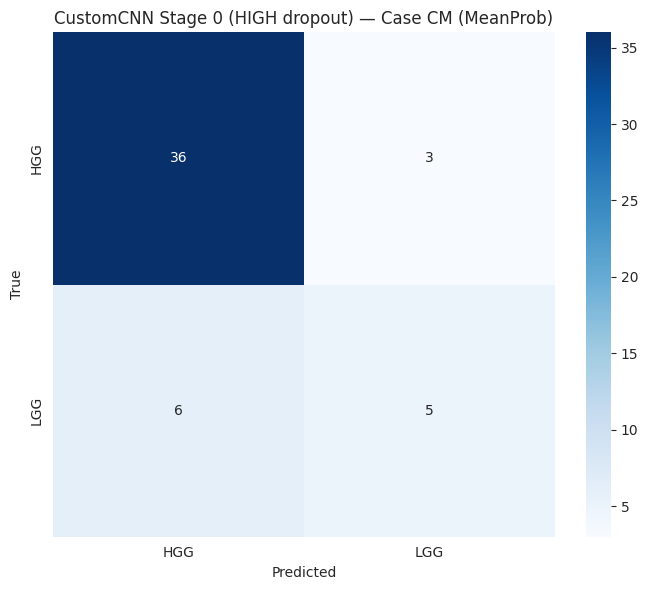

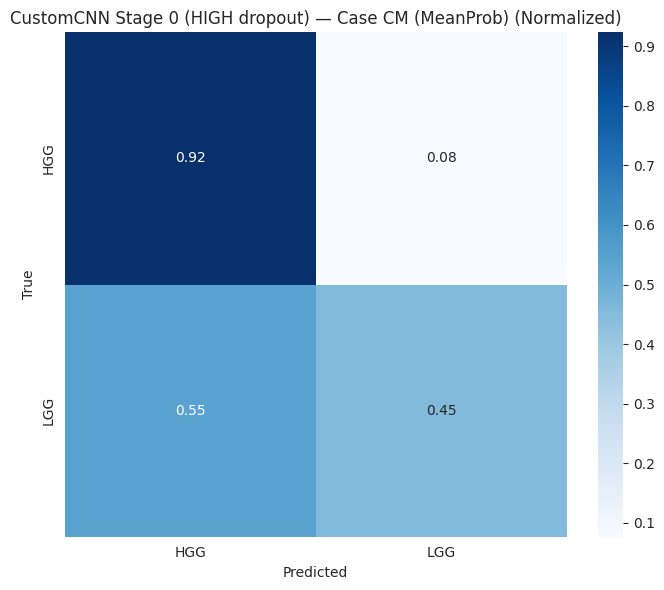

✅ Saved Stage 0 weights.


In [30]:
# ============================================================
# CELL — STAGE 0: Train with HIGH dropout
# ============================================================
HIGH_FEAT_DROP = 0.30
HIGH_HEAD_DROP = 0.60

model0 = build_custom_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=cfg.NUM_CLASSES,
    base=32,
    wd=1e-4,
    drop_feat=HIGH_FEAT_DROP,
    drop_head=HIGH_HEAD_DROP,
    use_se=True
)
compile_model(model0, lr=1e-3)
print(model0.summary())

history0 = model0.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=25,
    callbacks=make_callbacks("stage0_highdrop"),
    verbose=1
)

plot_learning_curves(history0, title_prefix="CustomCNN Stage 0 (HIGH dropout) —")
eval_all(model0, "CustomCNN Stage 0 (HIGH dropout)", test_gen, clean_case_index)

# Save weights to transfer to Stage 1
model0.save_weights("customcnn_stage0_highdrop.weights.h5")
print("✅ Saved Stage 0 weights.")


✅ Loaded Stage 0 weights into Stage 1 model.
Epoch 1/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.9120 - auc: 0.9629 - loss: 0.2852 - precision: 0.9120 - recall: 0.9120
Epoch 1: val_auc improved from -inf to 0.92018, saving model to best_customcnn_stage1_lowdrop_finetune.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 202s 789ms/step - accuracy: 0.9120 - auc: 0.9629 - loss: 0.2852 - precision: 0.9120 - recall: 0.9120 - val_accuracy: 0.8258 - val_auc: 0.9202 - val_loss: 0.5141 - val_precision: 0.8258 - val_recall: 0.8258 - learning_rate: 3.0000e-04
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9132 - auc: 0.9616 - loss: 0.2802 - precision: 0.9132 - recall: 0.9132
Epoch 2: val_auc improved from 0.92018 to 0.94188, saving model to best_customcnn_stage1_lowdrop_finetune.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 156s 655ms/step - accuracy: 0.9132 - auc: 0.9616 - loss: 0.2802 - precision: 0.9132 - recall: 0.9132 - val_accuracy: 0.8636 - val_auc: 0.9419 - val_loss: 0.4168 - v

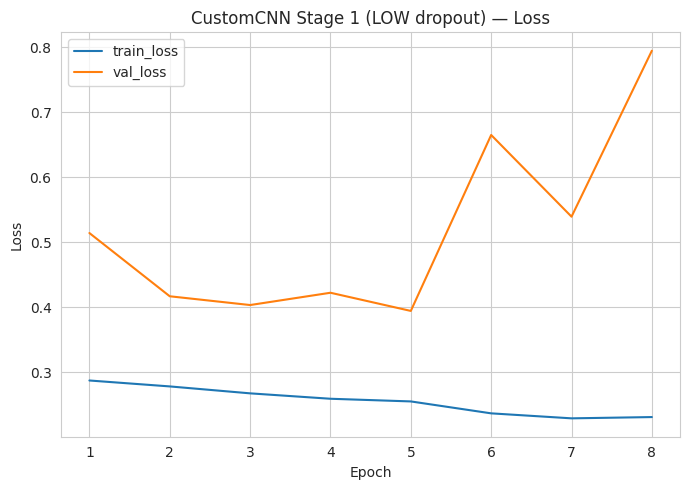

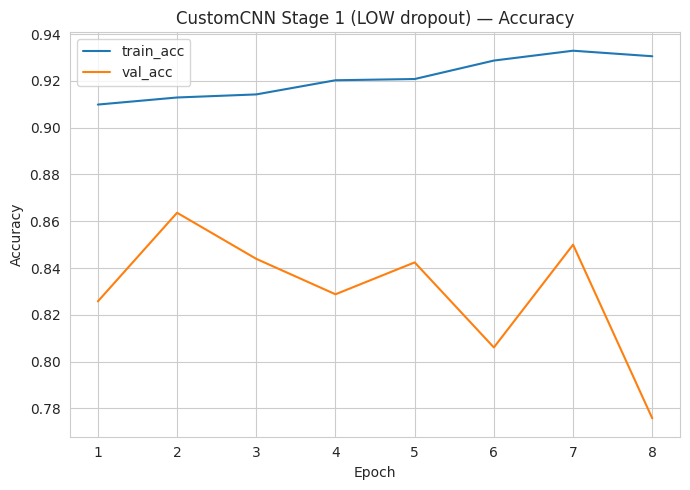

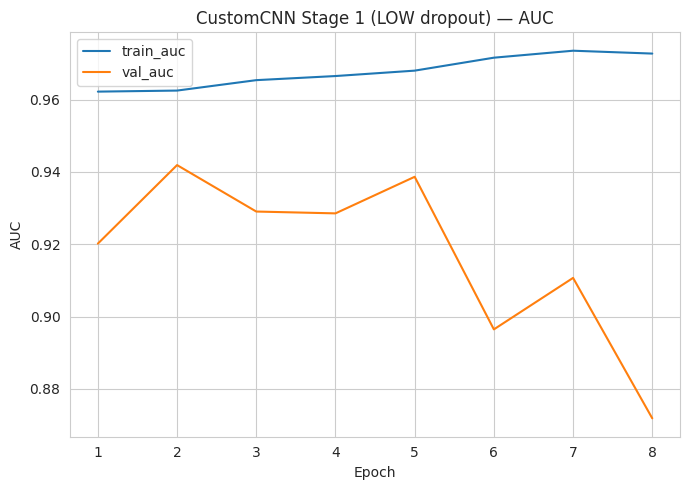


📊 EVALUATION — CustomCNN Stage 1 (LOW dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 402ms/step - accuracy: 0.7104 - auc: 0.8127 - loss: 0.9010 - precision: 0.7104 - recall: 0.7104

Keras metrics: {'loss': 0.7791432738304138, 'compile_metrics': 0.7694656252861023}
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step

--- SLICE LEVEL ---
Accuracy: 76.95%

              precision    recall  f1-score   support

         HGG     0.8042    0.8953    0.8473       468
         LGG     0.6343    0.4545    0.5296       187

    accuracy                         0.7695       655
   macro avg     0.7193    0.6749    0.6885       655
weighted avg     0.7557    0.7695    0.7566       655



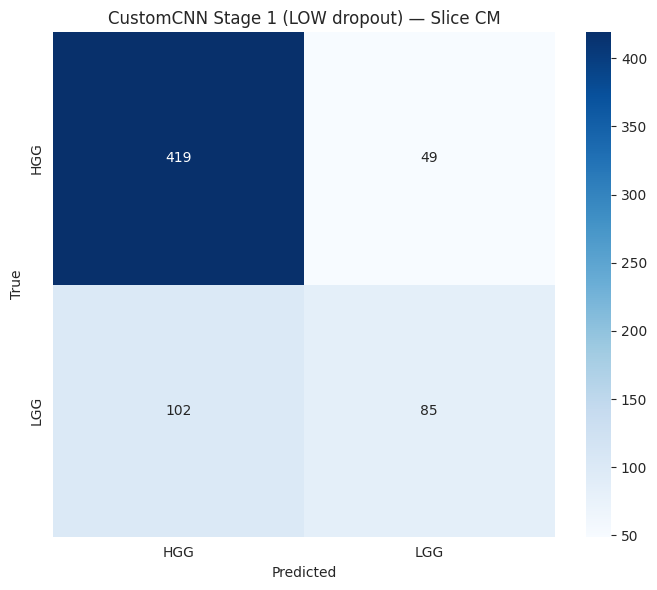

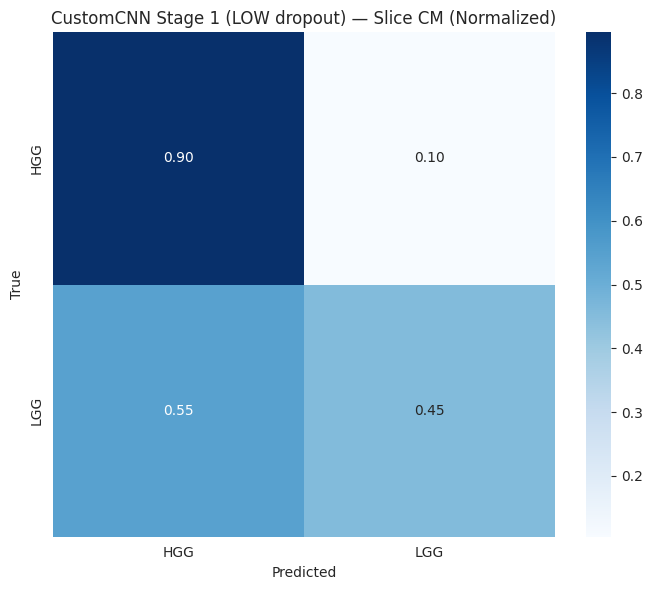


--- CASE LEVEL (Majority Vote) ---
Accuracy: 82.00%

              precision    recall  f1-score   support

         HGG     0.8750    0.8974    0.8861        39
         LGG     0.6000    0.5455    0.5714        11

    accuracy                         0.8200        50
   macro avg     0.7375    0.7214    0.7288        50
weighted avg     0.8145    0.8200    0.8169        50



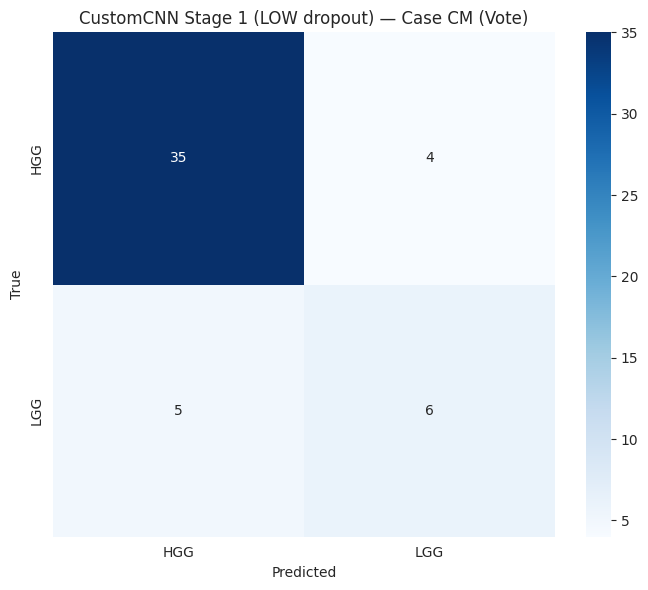

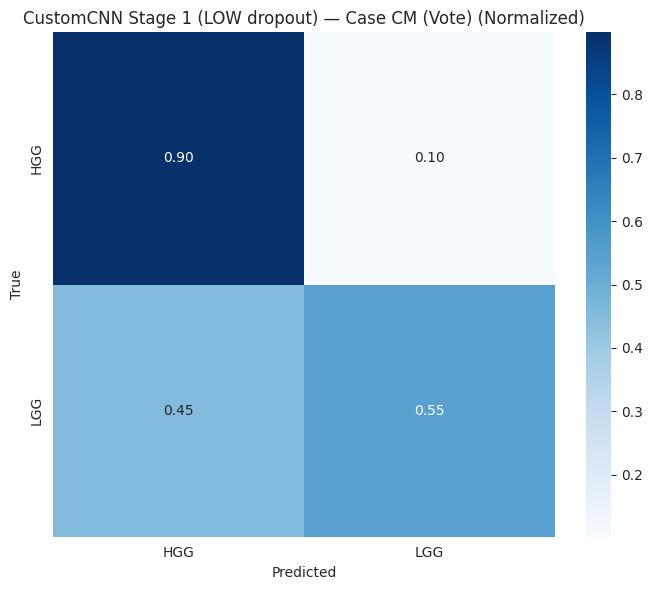


--- CASE LEVEL (Mean Probability) ---
Accuracy: 80.00%

              precision    recall  f1-score   support

         HGG     0.8537    0.8974    0.8750        39
         LGG     0.5556    0.4545    0.5000        11

    accuracy                         0.8000        50
   macro avg     0.7046    0.6760    0.6875        50
weighted avg     0.7881    0.8000    0.7925        50



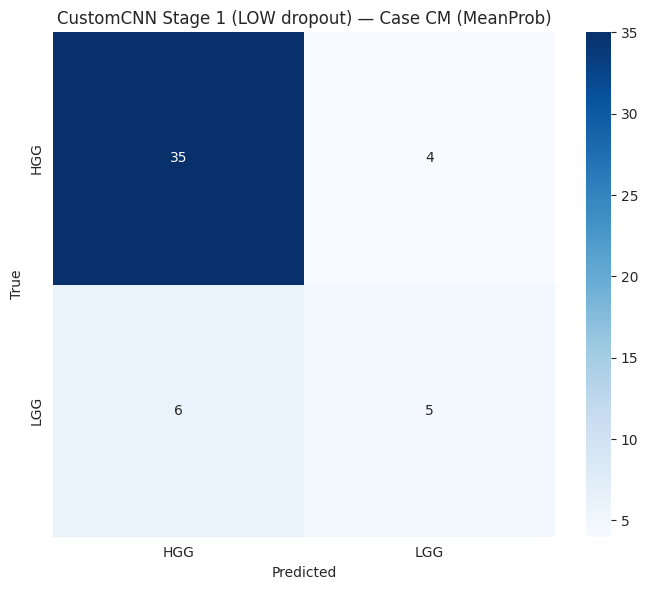

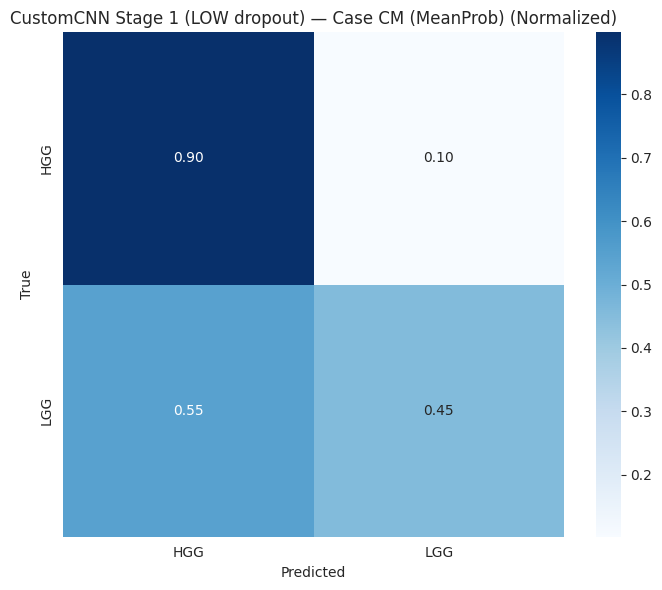

In [31]:
# ============================================================
# CELL — STAGE 1: Same architecture, LOWER dropout, load weights
# ============================================================
LOW_FEAT_DROP = 0.20
LOW_HEAD_DROP = 0.30

model1 = build_custom_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=cfg.NUM_CLASSES,
    base=32,               # SAME width
    wd=1e-4,               # SAME weight decay
    drop_feat=LOW_FEAT_DROP,
    drop_head=LOW_HEAD_DROP,
    use_se=True            # SAME SE choice
)

# Load weights from stage 0
model1.load_weights("customcnn_stage0_highdrop.weights.h5")
print("✅ Loaded Stage 0 weights into Stage 1 model.")

# Fine-tune with smaller LR
compile_model(model1, lr=3e-4)

history1 = model1.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=25,
    callbacks=make_callbacks("stage1_lowdrop_finetune"),
    verbose=1
)

plot_learning_curves(history1, title_prefix="CustomCNN Stage 1 (LOW dropout) —")
eval_all(model1, "CustomCNN Stage 1 (LOW dropout)", test_gen, clean_case_index)


✅ Loaded Stage 0 weights into Stage 1 model.
Epoch 1/25
237/238 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.8976 - auc: 0.9558 - loss: 0.3101 - precision: 0.8976 - recall: 0.8976
Epoch 1: val_auc improved from -inf to 0.94277, saving model to best_customcnn_stage2_lowdrop_finetune.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 190s 737ms/step - accuracy: 0.8977 - auc: 0.9558 - loss: 0.3100 - precision: 0.8977 - recall: 0.8977 - val_accuracy: 0.8591 - val_auc: 0.9428 - val_loss: 0.4194 - val_precision: 0.8591 - val_recall: 0.8591 - learning_rate: 3.0000e-04
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9124 - auc: 0.9608 - loss: 0.2658 - precision: 0.9124 - recall: 0.9124
Epoch 2: val_auc did not improve from 0.94277
238/238 ━━━━━━━━━━━━━━━━━━━━ 161s 675ms/step - accuracy: 0.9123 - auc: 0.9608 - loss: 0.2658 - precision: 0.9123 - recall: 0.9123 - val_accuracy: 0.8258 - val_auc: 0.8952 - val_loss: 0.6727 - val_precision: 0.8258 - val_recall: 0.8258 - learning_rate: 3.0000e

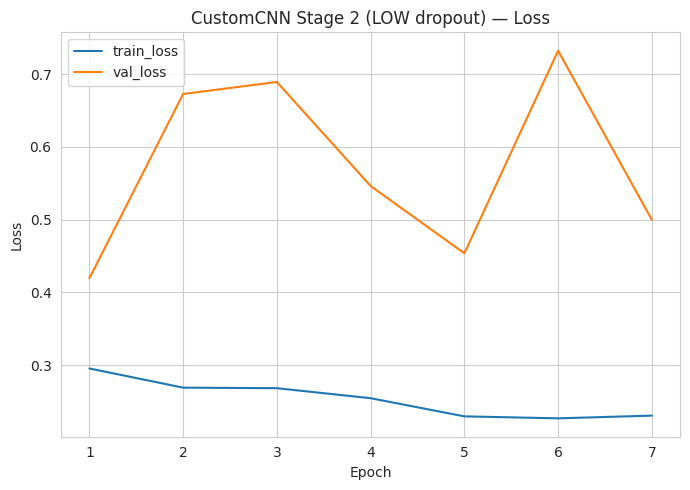

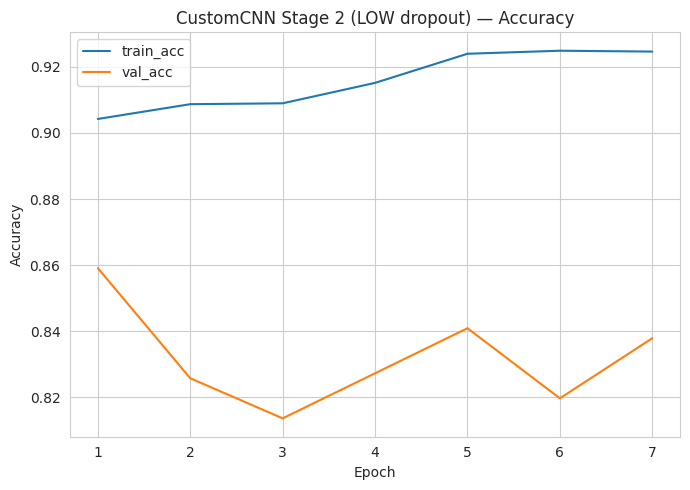

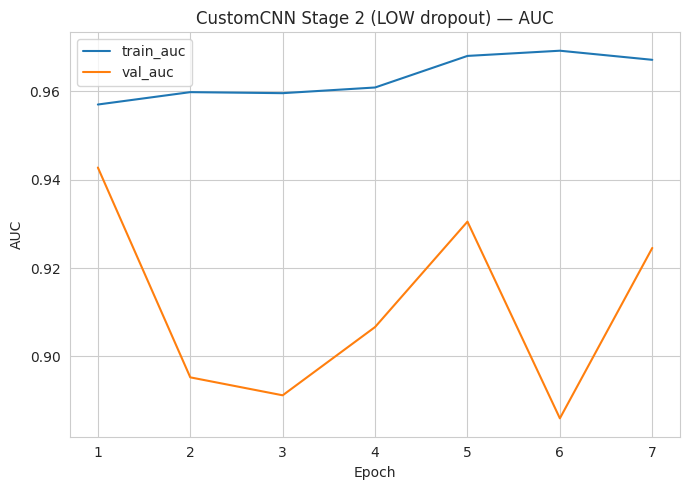


📊 EVALUATION — CustomCNN Stage 2 (LOW dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 404ms/step - accuracy: 0.6783 - auc: 0.7843 - loss: 1.1540 - precision: 0.6783 - recall: 0.6783

Keras metrics: {'loss': 0.9249227643013, 'compile_metrics': 0.7404580116271973}
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step

--- SLICE LEVEL ---
Accuracy: 74.05%

              precision    recall  f1-score   support

         HGG     0.7922    0.8632    0.8262       468
         LGG     0.5586    0.4332    0.4880       187

    accuracy                         0.7405       655
   macro avg     0.6754    0.6482    0.6571       655
weighted avg     0.7255    0.7405    0.7296       655



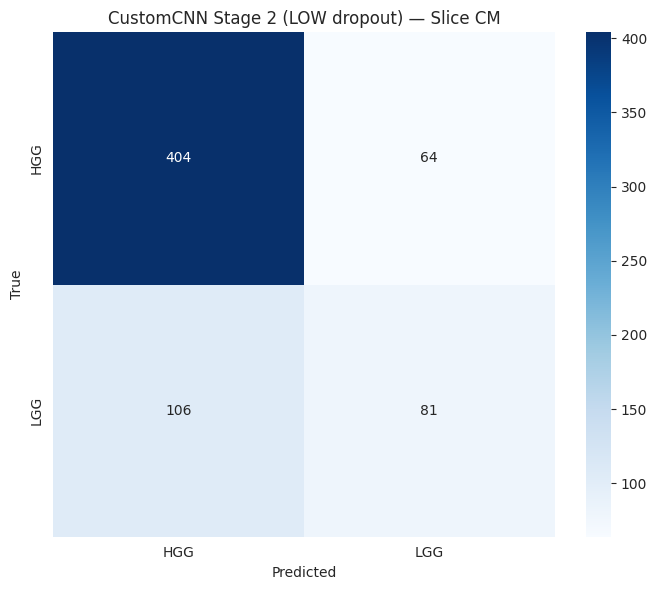

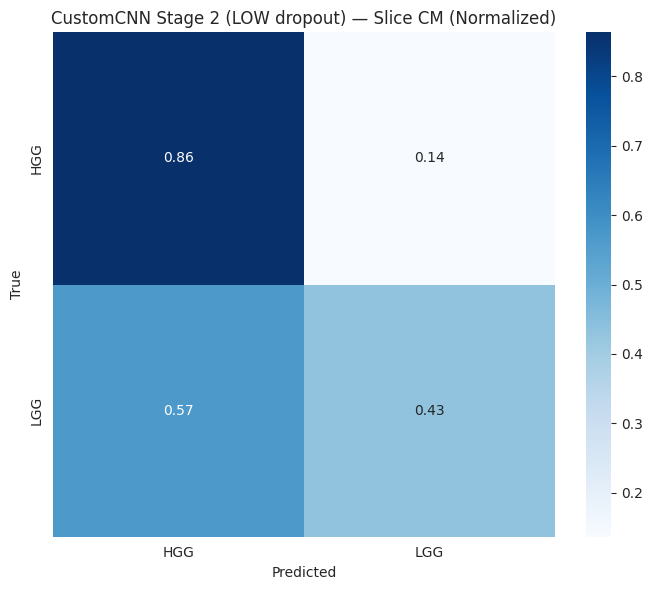


--- CASE LEVEL (Majority Vote) ---
Accuracy: 80.00%

              precision    recall  f1-score   support

         HGG     0.8537    0.8974    0.8750        39
         LGG     0.5556    0.4545    0.5000        11

    accuracy                         0.8000        50
   macro avg     0.7046    0.6760    0.6875        50
weighted avg     0.7881    0.8000    0.7925        50



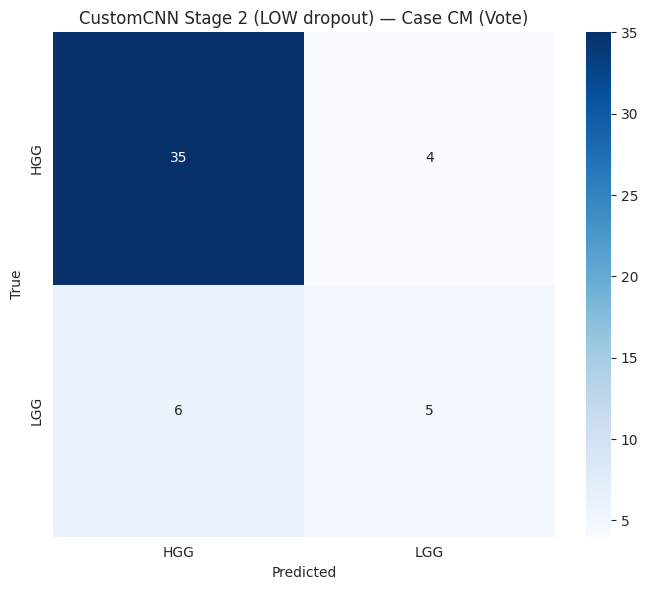

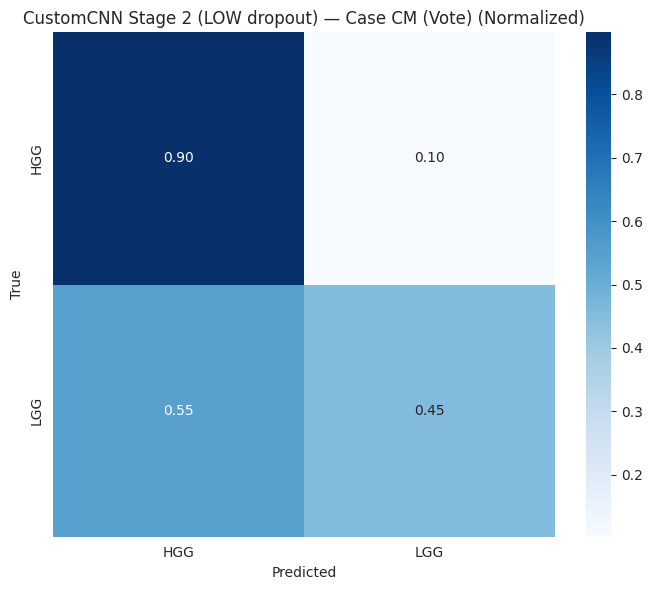


--- CASE LEVEL (Mean Probability) ---
Accuracy: 82.00%

              precision    recall  f1-score   support

         HGG     0.8571    0.9231    0.8889        39
         LGG     0.6250    0.4545    0.5263        11

    accuracy                         0.8200        50
   macro avg     0.7411    0.6888    0.7076        50
weighted avg     0.8061    0.8200    0.8091        50



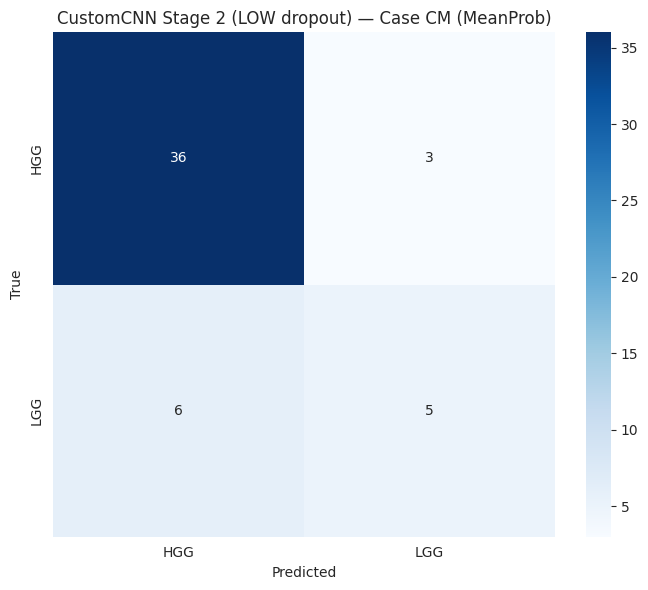

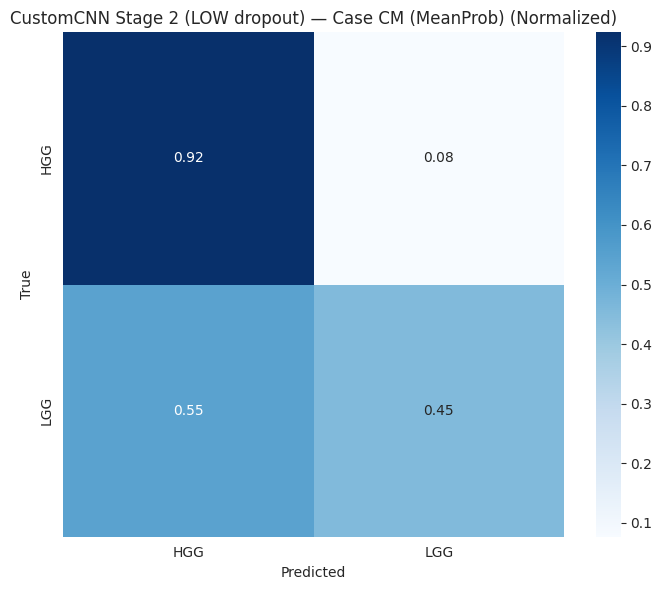

In [33]:
# ============================================================
# CELL — STAGE 1: Same architecture, LOWER dropout, load weights
# ============================================================
LOW_FEAT_DROP = 0.10
LOW_HEAD_DROP = 0.150

model1 = build_custom_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=cfg.NUM_CLASSES,
    base=32,               # SAME width
    wd=1e-4,               # SAME weight decay
    drop_feat=LOW_FEAT_DROP,
    drop_head=LOW_HEAD_DROP,
    use_se=True            # SAME SE choice
)

# Load weights from stage 0
model1.load_weights("customcnn_stage0_highdrop.weights.h5")
print("✅ Loaded Stage 0 weights into Stage 1 model.")

# Fine-tune with smaller LR
compile_model(model1, lr=3e-4)

history1 = model1.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=25,
        class_weight=class_weight_dict,
    callbacks=make_callbacks("stage2_lowdrop_finetune"),
    verbose=1
)

plot_learning_curves(history1, title_prefix="CustomCNN Stage 2 (LOW dropout) —")
eval_all(model1, "CustomCNN Stage 2 (LOW dropout)", test_gen, clean_case_index)


# Resnet

In [36]:
# ============================================================
# CELL — Build ResNet50 with 4ch->3ch adapter (dropout configurable)
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

INPUT_SHAPE = (240,240,4)

def build_resnet50_4ch(
    input_shape=INPUT_SHAPE,
    num_classes=2,
    adapter_filters=32,
    l2_reg=1e-4,
    dropout1=0.6,      # configurable (high in stage0)
    dropout2=0.4,      # configurable (high in stage0)
    use_resnet_preprocess=False
):
    inp = layers.Input(shape=input_shape, name="inp_4ch")

    # Adapter: 4 -> adapter_filters -> 3
    x = layers.Conv2D(adapter_filters, 3, padding="same", activation="relu", name="adapter_conv3x3")(inp)
    x = layers.BatchNormalization(name="adapter_bn")(x)
    x = layers.Conv2D(3, 1, padding="same", activation="linear", name="adapter_to3")(x)

    if use_resnet_preprocess:
        x = tf.keras.applications.resnet.preprocess_input(x)

    backbone = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(input_shape[0], input_shape[1], 3)
    )
    backbone.trainable = False

    y = backbone(x, training=False)

    y = layers.GlobalAveragePooling2D(name="gap")(y)
    y = layers.Dropout(dropout1, name="drop1")(y)

    y = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg),
        name="dense256"
    )(y)
    y = layers.BatchNormalization(name="bn_head")(y)
    y = layers.Dropout(dropout2, name="drop2")(y)

    out = layers.Dense(num_classes, activation="softmax", name="pred")(y)

    model = models.Model(inp, out, name="ResNet50_4ch")
    return model, backbone


In [37]:
# ============================================================
# CELL — Compile + callbacks
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks(stage_name):
    return [
        ModelCheckpoint(
            filepath=f"best_resnet_{stage_name}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=6,
            restore_best_weights=True,
            verbose=1
        )
    ]


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_4ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp_4ch (InputLayer)            │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_conv3x3 (Conv2D)        │ (None, 240, 240, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_bn (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_to3 (Conv2D)            │ (None, 240, 240, 3)    │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,205 (91.99 MB)

 Trainable params: 526,917 (2.01 MB)

 Non-trainable params: 23,588,288 (89.98 MB)

None
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.6506 - auc: 0.6980 - loss: 0.8399 - precision: 0.6506 - recall: 0.6506
Epoch 1: val_auc improved from -inf to 0.27961, saving model to best_resnet_stage0_frozen_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 216s 829ms/step - accuracy: 0.6510 - auc: 0.6985 - loss: 0.8391 - precision: 0.6510 - recall: 0.6510 - val_accuracy: 0.3091 - val_auc: 0.2796 - val_loss: 1.6855 - val_precision: 0.3091 - val_recall: 0.3091 - learning_rate: 0.0010
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8177 - auc: 0.8833 - loss: 0.4734 - precision: 0.8177 - recall: 0.8177
Epoch 2: val_auc improved from 0.27961 to 0.47782, saving model to best_resnet_stage0_frozen_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 167s 702ms/step - accuracy: 0.8178 - auc: 0.8833 - loss: 0.4733 - precision: 0.8178 - recall: 0.8178 - val_accuracy: 0.3773 - val_auc: 0.4778 - val_loss: 1.5305 - val_precision: 0.3773 - val_recall: 0.3773 - learning

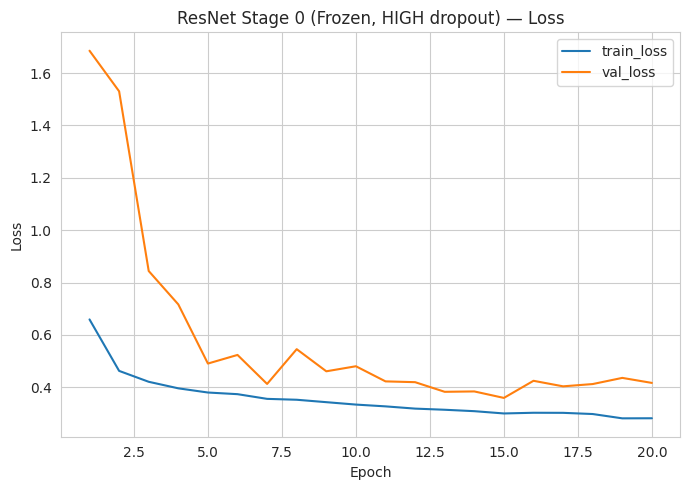

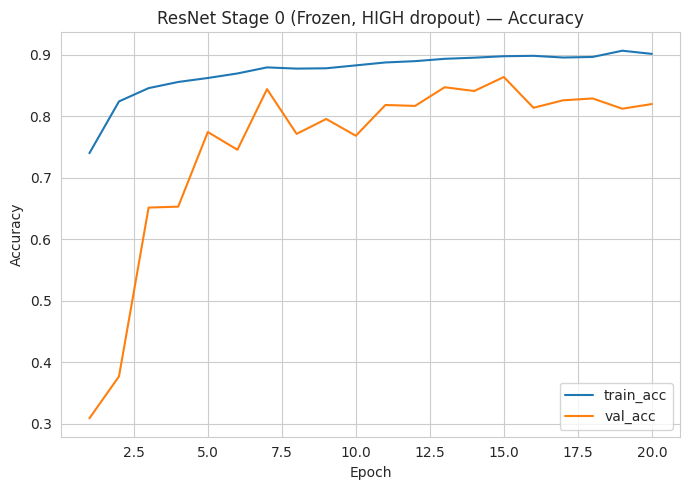

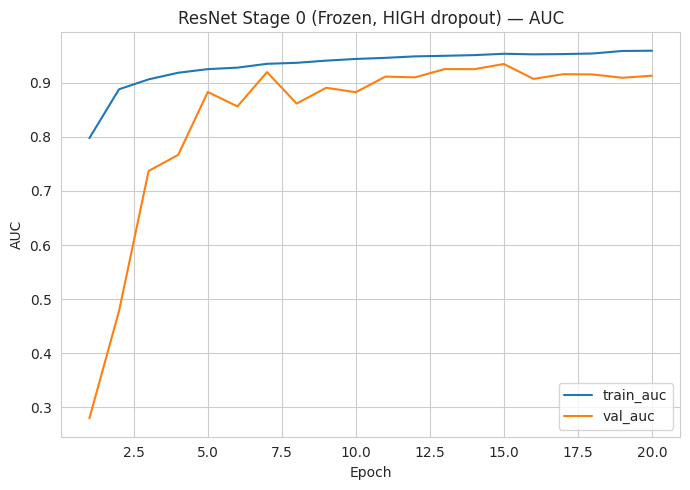


📊 EVALUATION — ResNet Stage 0 (Frozen, HIGH dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 480ms/step - accuracy: 0.8374 - auc: 0.9258 - loss: 0.3798 - precision: 0.8374 - recall: 0.8374

Keras metrics: {'loss': 0.40357518196105957, 'compile_metrics': 0.8274809122085571}
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step

--- SLICE LEVEL ---
Accuracy: 82.75%

              precision    recall  f1-score   support

         HGG     0.9176    0.8333    0.8735       468
         LGG     0.6609    0.8128    0.7290       187

    accuracy                         0.8275       655
   macro avg     0.7893    0.8231    0.8012       655
weighted avg     0.8443    0.8275    0.8322       655



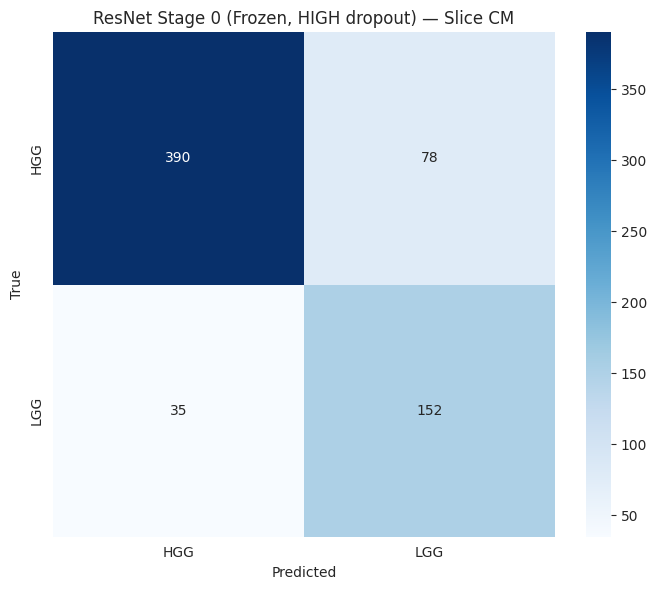

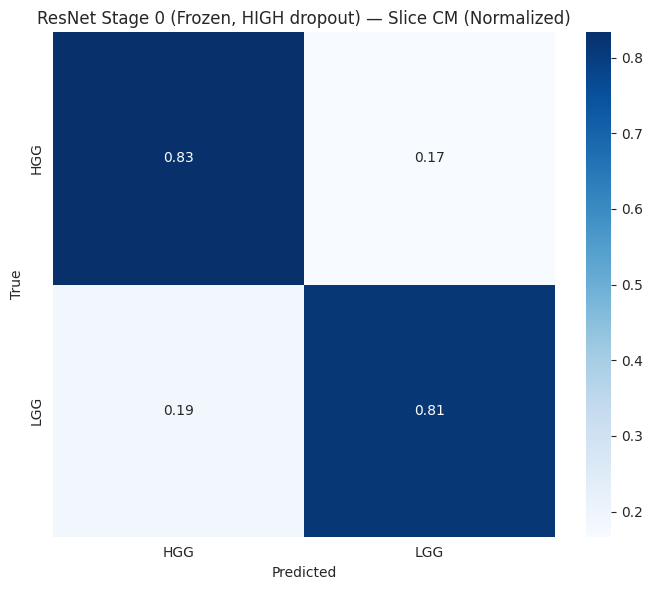


--- CASE LEVEL (Majority Vote) ---
Accuracy: 86.00%

              precision    recall  f1-score   support

         HGG     0.9444    0.8718    0.9067        39
         LGG     0.6429    0.8182    0.7200        11

    accuracy                         0.8600        50
   macro avg     0.7937    0.8450    0.8133        50
weighted avg     0.8781    0.8600    0.8656        50



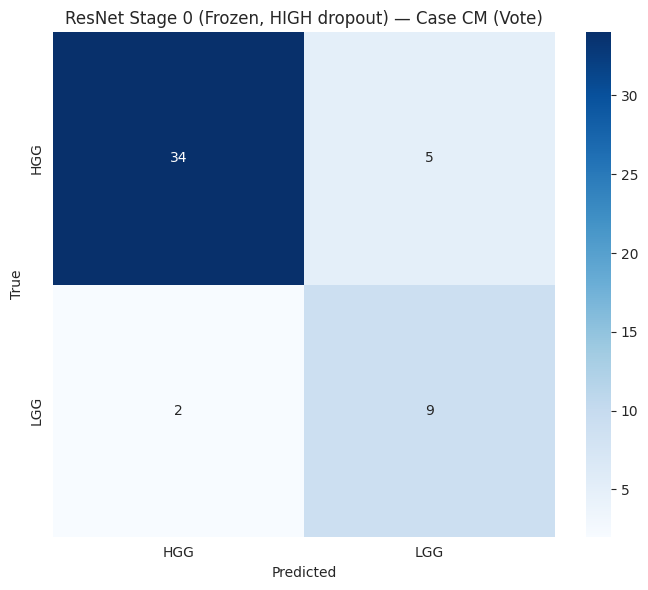

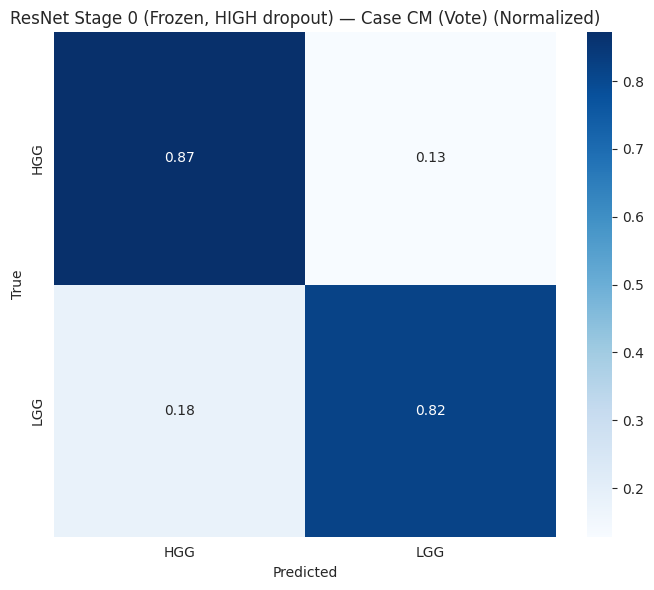


--- CASE LEVEL (Mean Probability) ---
Accuracy: 88.00%

              precision    recall  f1-score   support

         HGG     0.9459    0.8974    0.9211        39
         LGG     0.6923    0.8182    0.7500        11

    accuracy                         0.8800        50
   macro avg     0.8191    0.8578    0.8355        50
weighted avg     0.8901    0.8800    0.8834        50



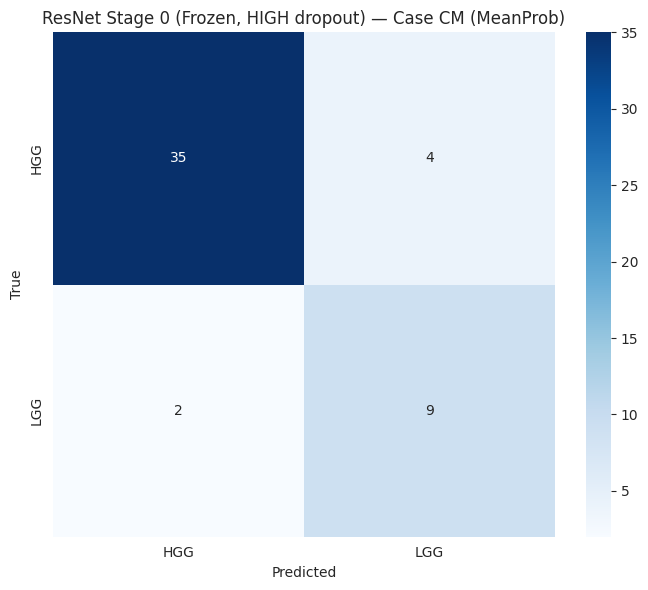

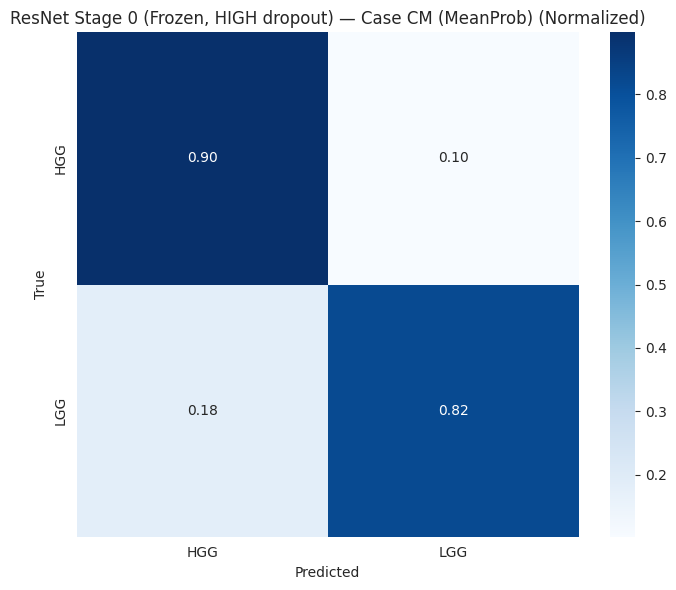

✅ Saved Stage 0 weights.


In [38]:
# ============================================================
# CELL — STAGE 0: Train head with frozen ResNet backbone (HIGH dropout)
# ============================================================
HIGH_D1, HIGH_D2 = 0.6, 0.4

model0, backbone0 = build_resnet50_4ch(
    dropout1=HIGH_D1,
    dropout2=HIGH_D2,
    l2_reg=1e-4,
    use_resnet_preprocess=False  # recommended for your normalized MRI
)
compile_model(model0, lr=1e-3)

print(model0.summary())

history0 = model0.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks("stage0_frozen_highdrop"),
    verbose=1
)

plot_learning_curves(history0, title_prefix="ResNet Stage 0 (Frozen, HIGH dropout) —")
eval_all(model0, "ResNet Stage 0 (Frozen, HIGH dropout)", test_gen, clean_case_index)

# Save weights for transfer into stage 1 model
model0.save_weights("resnet_stage0_highdrop.weights.h5")
print("✅ Saved Stage 0 weights.")


In [39]:
# ============================================================
# CELL — STAGE 1 model: LOWER dropout + load Stage 0 weights
# ============================================================
LOW_D1, LOW_D2 = 0.3, 0.2

model1, backbone1 = build_resnet50_4ch(
    dropout1=LOW_D1,
    dropout2=LOW_D2,
    l2_reg=1e-4,
    use_resnet_preprocess=False
)

model1.load_weights("resnet_stage0_highdrop.weights.h5")
print("✅ Loaded Stage 0 weights into Stage 1 model.")


✅ Loaded Stage 0 weights into Stage 1 model.


In [40]:
# ============================================================
# CELL — Fine-tuning: unfreeze last N layers safely (freeze BN)
# ============================================================
def unfreeze_last_n_layers(backbone, n=40):
    backbone.trainable = True

    # Freeze everything first
    for layer in backbone.layers:
        layer.trainable = False

    # Unfreeze last N (but keep BatchNorm frozen)
    for layer in backbone.layers[-n:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Unfreeze last 40 layers (tune this: 20/40/60)
unfreeze_last_n_layers(backbone1, n=40)

# Compile with small LR
compile_model(model1, lr=1e-5)

trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model1.trainable_weights])
non_trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model1.non_trainable_weights])
print("Trainable params:", trainable_count)
print("Non-trainable params:", non_trainable_count)


Trainable params: 16333637
Non-trainable params: 7781568


In [41]:
# ============================================================
# CELL — Fine-tuning: unfreeze last N layers safely (freeze BN)
# ============================================================
def unfreeze_last_n_layers(backbone, n=40):
    backbone.trainable = True

    # Freeze everything first
    for layer in backbone.layers:
        layer.trainable = False

    # Unfreeze last N (but keep BatchNorm frozen)
    for layer in backbone.layers[-n:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Unfreeze last 40 layers (tune this: 20/40/60)
unfreeze_last_n_layers(backbone1, n=40)

# Compile with small LR
compile_model(model1, lr=1e-5)

trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model1.trainable_weights])
non_trainable_count = np.sum([tf.keras.backend.count_params(w) for w in model1.non_trainable_weights])
print("Trainable params:", trainable_count)
print("Non-trainable params:", non_trainable_count)


Trainable params: 16333637
Non-trainable params: 7781568


Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.9078 - auc: 0.9623 - loss: 0.2730 - precision: 0.9078 - recall: 0.9078
Epoch 1: val_auc improved from -inf to 0.93272, saving model to best_resnet_stage1_finetune_lowdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 224s 855ms/step - accuracy: 0.9079 - auc: 0.9624 - loss: 0.2729 - precision: 0.9079 - recall: 0.9079 - val_accuracy: 0.8455 - val_auc: 0.9327 - val_loss: 0.3886 - val_precision: 0.8455 - val_recall: 0.8455 - learning_rate: 1.0000e-05
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9231 - auc: 0.9720 - loss: 0.2362 - precision: 0.9231 - recall: 0.9231
Epoch 2: val_auc did not improve from 0.93272
238/238 ━━━━━━━━━━━━━━━━━━━━ 169s 708ms/step - accuracy: 0.9231 - auc: 0.9720 - loss: 0.2361 - precision: 0.9231 - recall: 0.9231 - val_accuracy: 0.7727 - val_auc: 0.8793 - val_loss: 0.5349 - val_precision: 0.7727 - val_recall: 0.7727 - learning_rate: 1.0000e-05
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 6

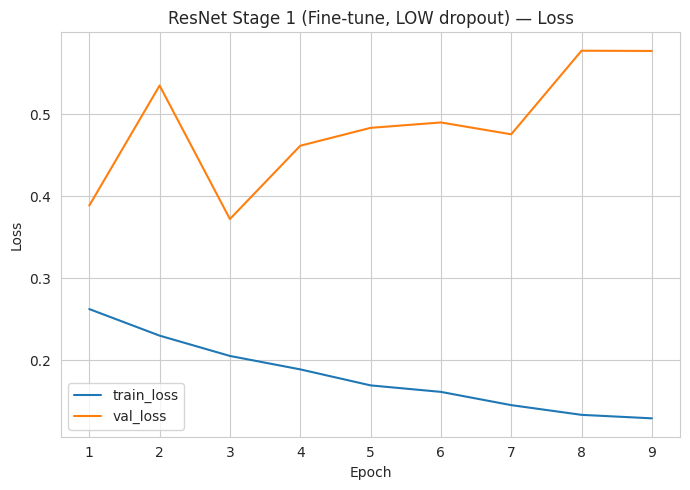

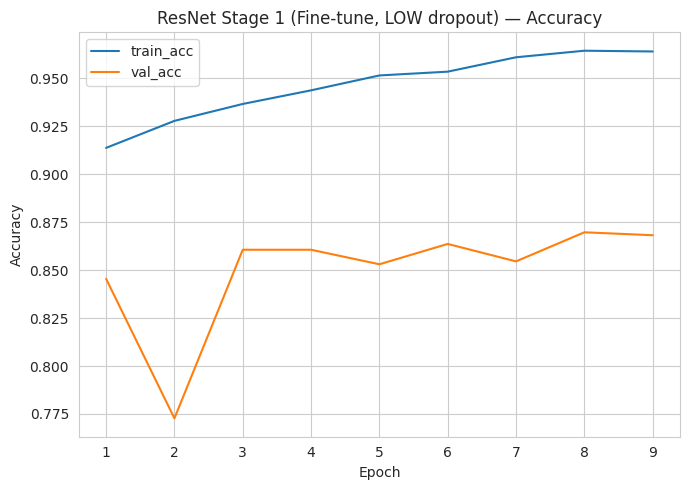

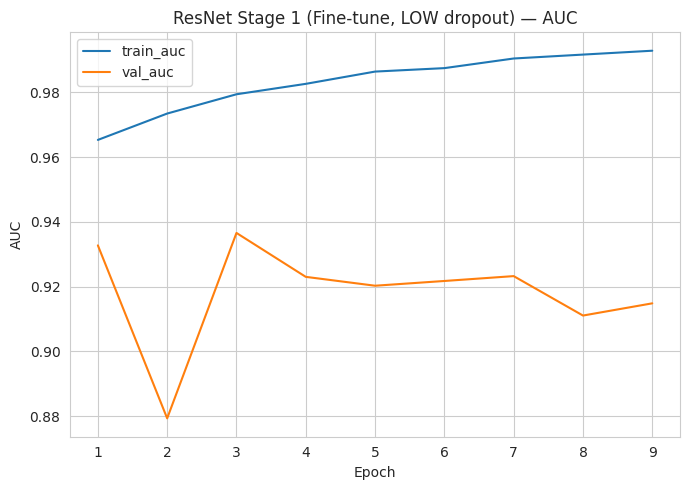


📊 EVALUATION — ResNet Stage 1 (Fine-tune, LOW dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.8492 - auc: 0.9331 - loss: 0.3926 - precision: 0.8492 - recall: 0.8492

Keras metrics: {'loss': 0.41294756531715393, 'compile_metrics': 0.8442748188972473}
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 400ms/step

--- SLICE LEVEL ---
Accuracy: 84.43%

              precision    recall  f1-score   support

         HGG     0.9013    0.8782    0.8896       468
         LGG     0.7136    0.7594    0.7358       187

    accuracy                         0.8443       655
   macro avg     0.8074    0.8188    0.8127       655
weighted avg     0.8477    0.8443    0.8457       655



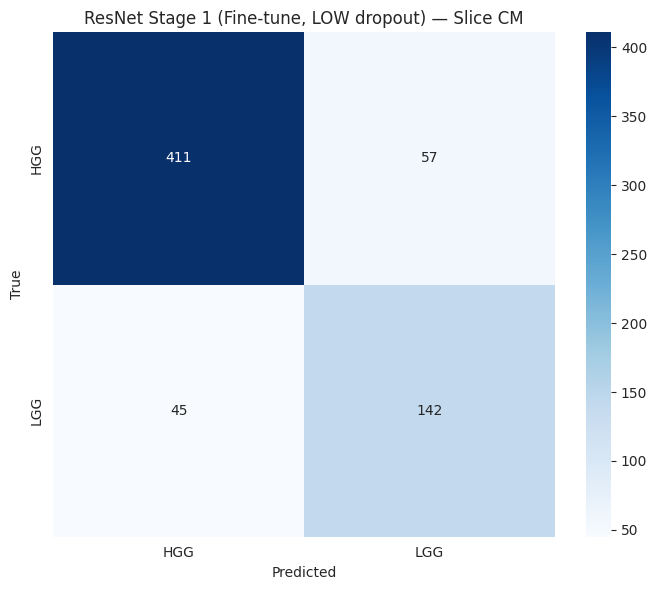

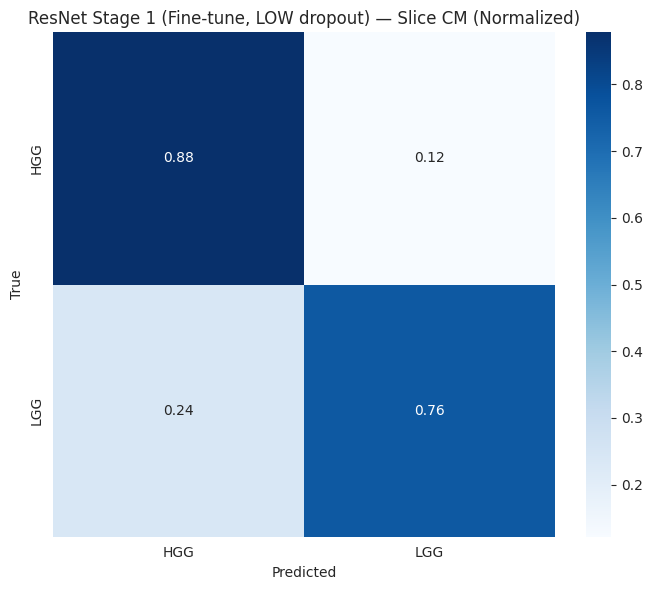


--- CASE LEVEL (Majority Vote) ---
Accuracy: 92.00%

              precision    recall  f1-score   support

         HGG     0.9487    0.9487    0.9487        39
         LGG     0.8182    0.8182    0.8182        11

    accuracy                         0.9200        50
   macro avg     0.8834    0.8834    0.8834        50
weighted avg     0.9200    0.9200    0.9200        50



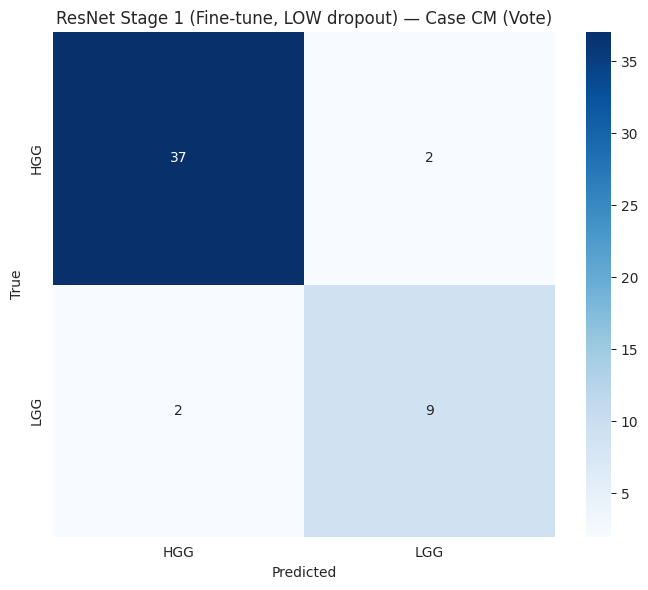

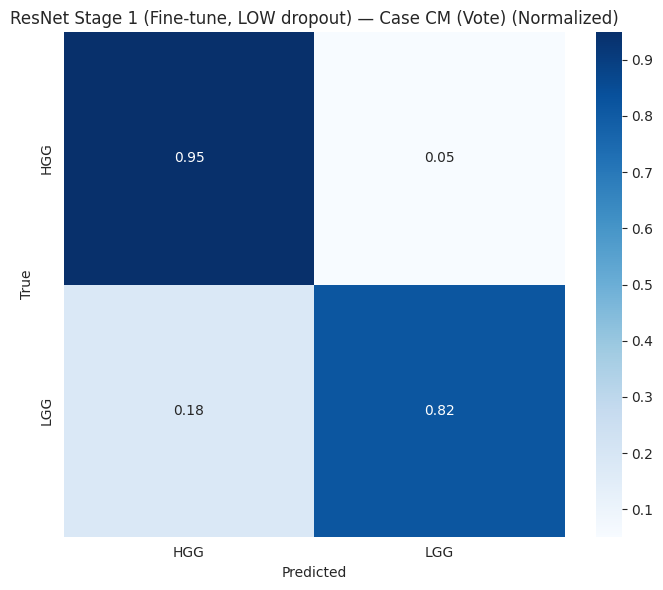


--- CASE LEVEL (Mean Probability) ---
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9474    0.9231    0.9351        39
         LGG     0.7500    0.8182    0.7826        11

    accuracy                         0.9000        50
   macro avg     0.8487    0.8706    0.8588        50
weighted avg     0.9039    0.9000    0.9015        50



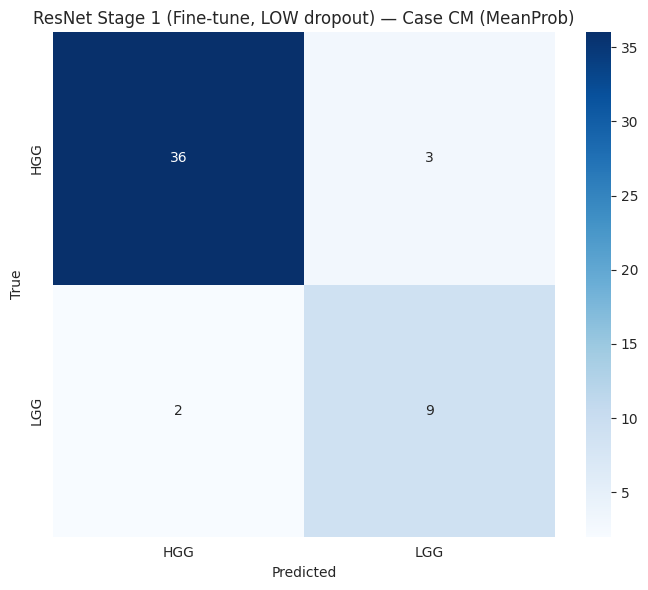

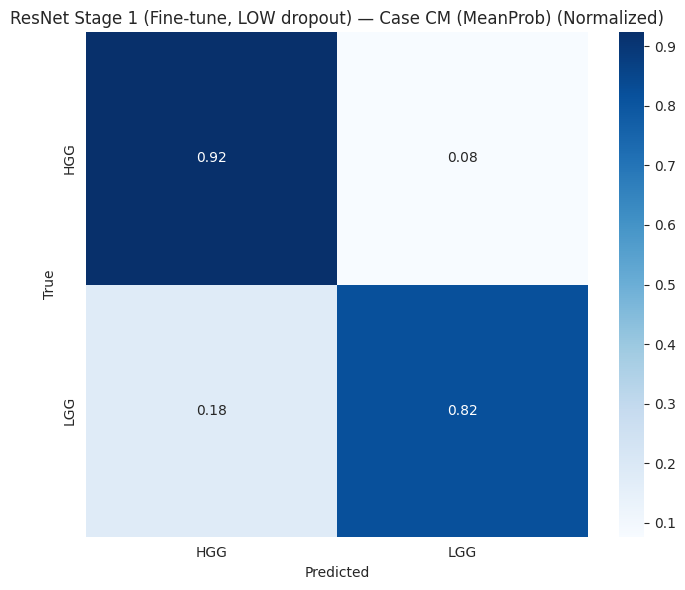

In [42]:
# ============================================================
# CELL — STAGE 1: Fine-tune (LOW dropout + partial backbone unfrozen)
# ============================================================
history1 = model1.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks("stage1_finetune_lowdrop"),
    verbose=1
)

plot_learning_curves(history1, title_prefix="ResNet Stage 1 (Fine-tune, LOW dropout) —")
eval_all(model1, "ResNet Stage 1 (Fine-tune, LOW dropout)", test_gen, clean_case_index)


# voteing

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf


In [44]:
EFF_PATH = "best_effnet_stage0_frozen_highdrop.keras"   # <-- change if needed
RES_PATH = "best_resnet_stage1_finetune_lowdrop.keras"  # <-- change if needed

eff_model = tf.keras.models.load_model(EFF_PATH)
res_model = tf.keras.models.load_model(RES_PATH)

print("✅ Loaded models:")
print("EfficientNet:", eff_model.name)
print("ResNet     :", res_model.name)


✅ Loaded models:
EfficientNet: EffNetB0_4ch
ResNet     : ResNet50_4ch


In [45]:
def get_true_and_casekeys(gen):
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    return y_true, case_keys

def predict_probs(model, gen):
    prob = model.predict(gen, verbose=1)  # shape: (N,2)
    pred = np.argmax(prob, axis=1)
    return prob, pred

def plot_cm(y_true, y_pred, title, class_names, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm, annot=True, fmt=".2f" if normalize else "d",
        cmap="Blues", xticklabels=class_names, yticklabels=class_names
    )
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def majority_vote(arr, n_classes=2):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])  # deterministic tie-break

def case_level_majority(y_pred_slice, case_keys, clean_case_index, n_classes=2):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=n_classes))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

def case_level_meanprob(prob_slice, case_keys, clean_case_index):
    df = pd.DataFrame({
        "case_key": case_keys,
        "p0": prob_slice[:, 0],
        "p1": prob_slice[:, 1],
    })
    mean_probs = df.groupby("case_key")[["p0", "p1"]].mean()
    y_pred_case = mean_probs.values.argmax(axis=1).astype(int)
    y_true_case = mean_probs.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"]).values.astype(int)
    return y_true_case, y_pred_case, mean_probs


In [46]:
# True labels + case ids
y_true_slice, case_keys = get_true_and_casekeys(test_gen)

# Predict each model
eff_prob, eff_pred = predict_probs(eff_model, test_gen)
res_prob, res_pred = predict_probs(res_model, test_gen)

print("✅ Predictions ready:")
print("Eff prob:", eff_prob.shape, "Res prob:", res_prob.shape)

# -------------------------
# ENSEMBLE (SOFT VOTE)
# -------------------------
soft_prob = (eff_prob + res_prob) / 2.0
soft_pred = np.argmax(soft_prob, axis=1)

# -------------------------
# ENSEMBLE (HARD VOTE)
# -------------------------
hard_pred = np.array([majority_vote([eff_pred[i], res_pred[i]], n_classes=2) for i in range(len(eff_pred))], dtype=int)

# -------------------------
# OPTIONAL: WEIGHTED SOFT VOTE
# Give more weight to the better model if you want
# -------------------------
USE_WEIGHTED = False
w_eff, w_res = 0.5, 0.5  # change e.g. 0.6/0.4
if USE_WEIGHTED:
    soft_prob = (w_eff * eff_prob + w_res * res_prob) / (w_eff + w_res)
    soft_pred = np.argmax(soft_prob, axis=1)


21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 525ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step
✅ Predictions ready:
Eff prob: (655, 2) Res prob: (655, 2)



🧠 SLICE LEVEL — EfficientNet
Accuracy: 82.60%

              precision    recall  f1-score   support

         HGG     0.9023    0.8483    0.8744       468
         LGG     0.6698    0.7701    0.7164       187

    accuracy                         0.8260       655
   macro avg     0.7860    0.8092    0.7954       655
weighted avg     0.8359    0.8260    0.8293       655



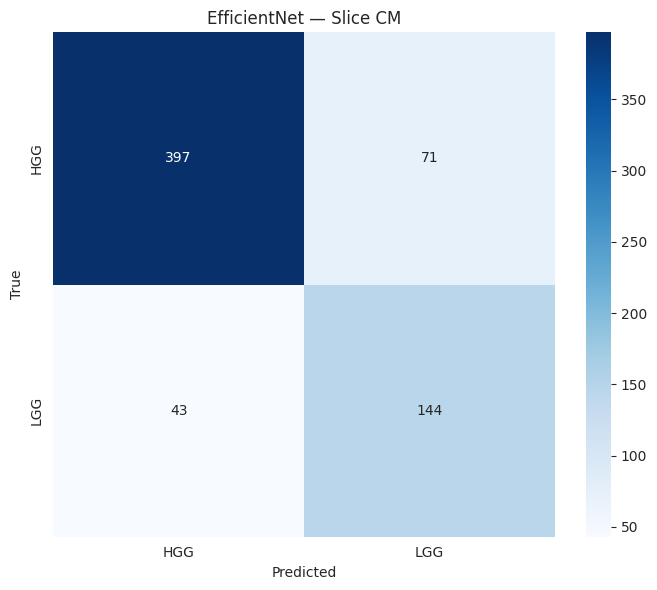

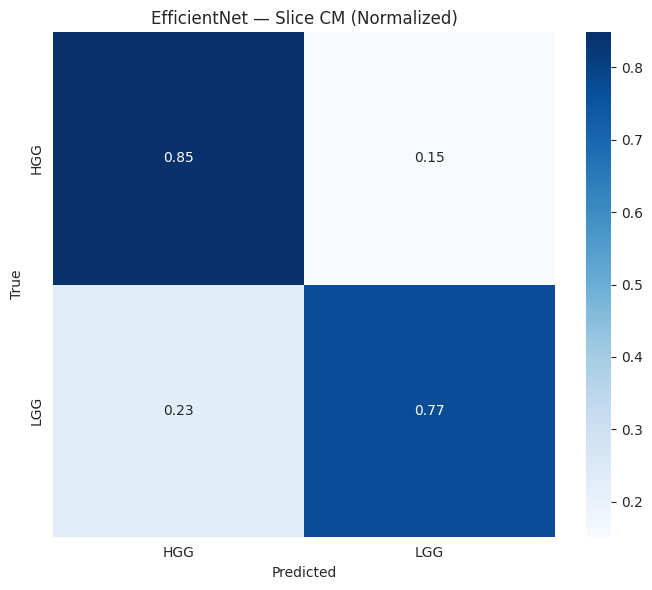


🧠 SLICE LEVEL — ResNet
Accuracy: 84.43%

              precision    recall  f1-score   support

         HGG     0.9013    0.8782    0.8896       468
         LGG     0.7136    0.7594    0.7358       187

    accuracy                         0.8443       655
   macro avg     0.8074    0.8188    0.8127       655
weighted avg     0.8477    0.8443    0.8457       655



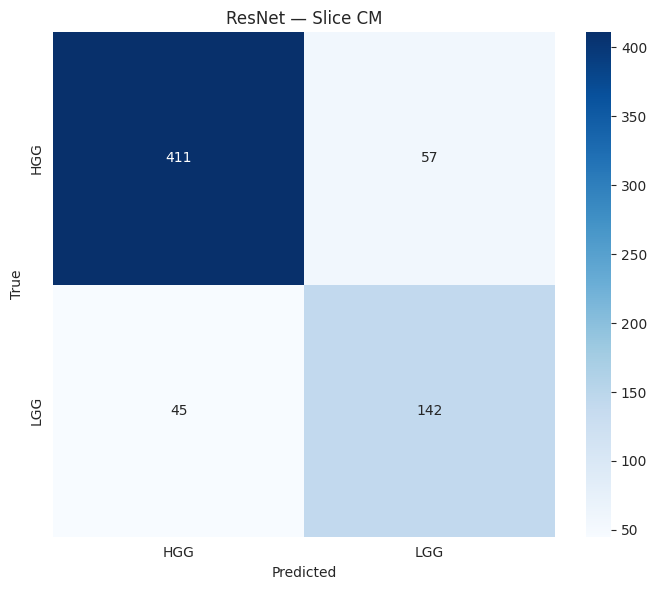

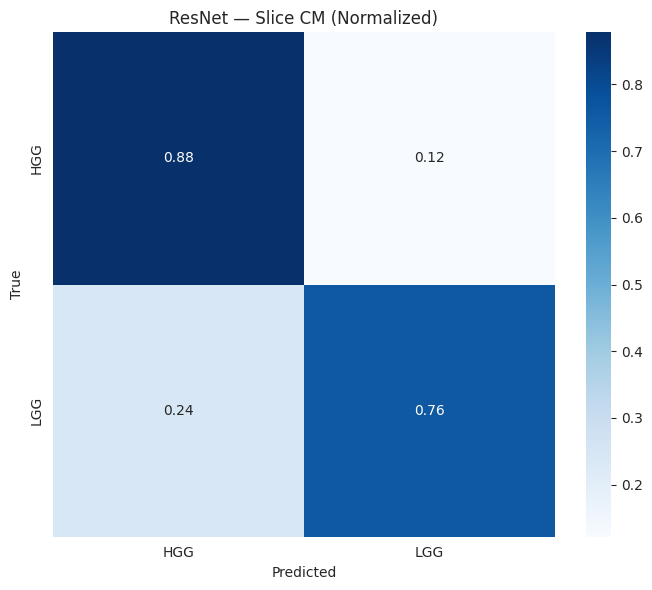


🧠 SLICE LEVEL — Ensemble (Soft Vote)
Accuracy: 84.58%

              precision    recall  f1-score   support

         HGG     0.9051    0.8761    0.8903       468
         LGG     0.7129    0.7701    0.7404       187

    accuracy                         0.8458       655
   macro avg     0.8090    0.8231    0.8153       655
weighted avg     0.8502    0.8458    0.8475       655



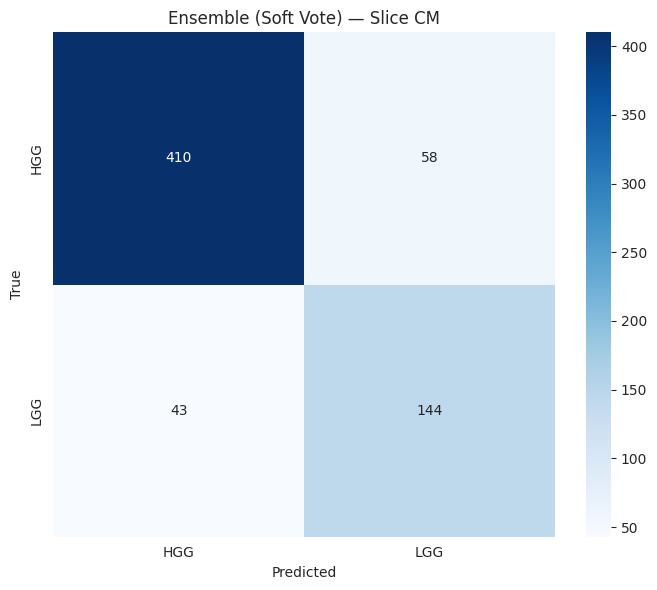

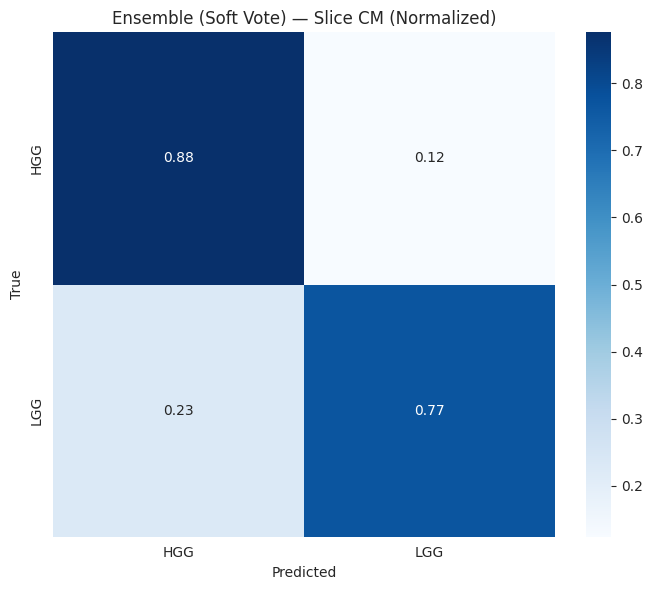


🧠 SLICE LEVEL — Ensemble (Hard Vote)
Accuracy: 86.26%

              precision    recall  f1-score   support

         HGG     0.8873    0.9252    0.9059       468
         LGG     0.7904    0.7059    0.7458       187

    accuracy                         0.8626       655
   macro avg     0.8389    0.8155    0.8258       655
weighted avg     0.8596    0.8626    0.8602       655



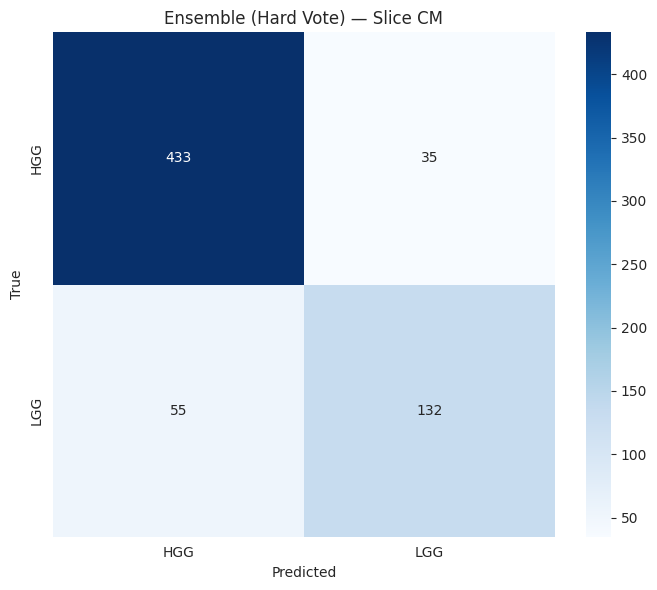

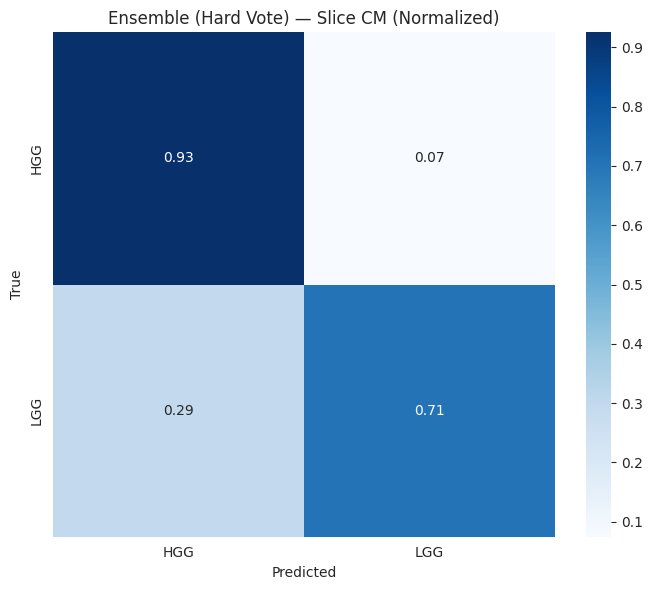

In [47]:
CLASS_NAMES = cfg.CLASS_NAMES

def report_slice(title, y_true, y_pred):
    print("\n" + "="*80)
    print(f"🧠 SLICE LEVEL — {title}")
    print("="*80)
    print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    plot_cm(y_true, y_pred, f"{title} — Slice CM", CLASS_NAMES, normalize=False)
    plot_cm(y_true, y_pred, f"{title} — Slice CM", CLASS_NAMES, normalize=True)

report_slice("EfficientNet", y_true_slice, eff_pred)
report_slice("ResNet", y_true_slice, res_pred)
report_slice("Ensemble (Soft Vote)", y_true_slice, soft_pred)
report_slice("Ensemble (Hard Vote)", y_true_slice, hard_pred)



🏥 CASE LEVEL — Ensemble Soft Vote (MeanProb per case)
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9474    0.9231    0.9351        39
         LGG     0.7500    0.8182    0.7826        11

    accuracy                         0.9000        50
   macro avg     0.8487    0.8706    0.8588        50
weighted avg     0.9039    0.9000    0.9015        50



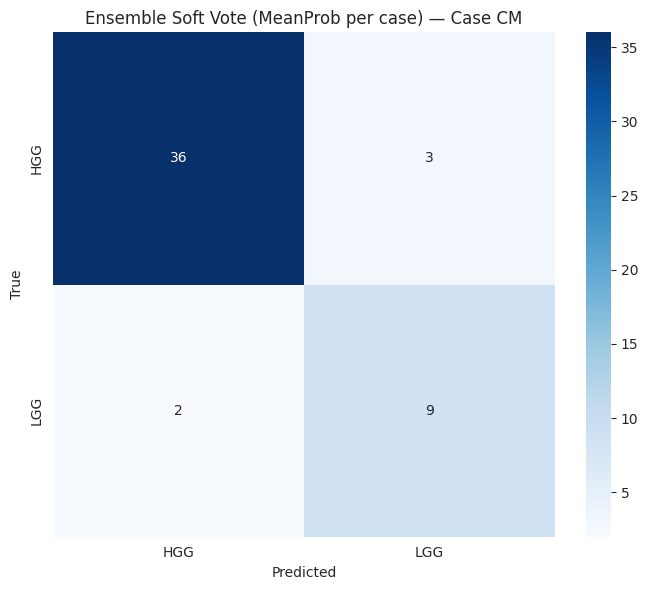

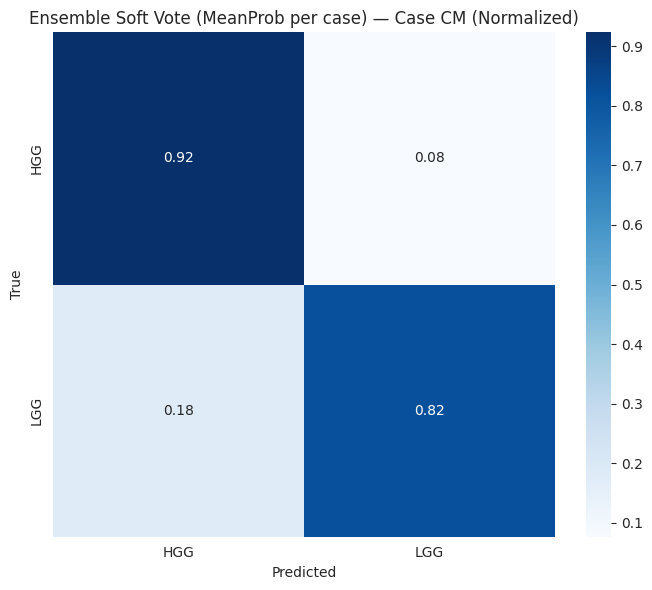


🏥 CASE LEVEL — Ensemble Hard Vote (Majority per case)
Accuracy: 94.00%

              precision    recall  f1-score   support

         HGG     0.9500    0.9744    0.9620        39
         LGG     0.9000    0.8182    0.8571        11

    accuracy                         0.9400        50
   macro avg     0.9250    0.8963    0.9096        50
weighted avg     0.9390    0.9400    0.9390        50



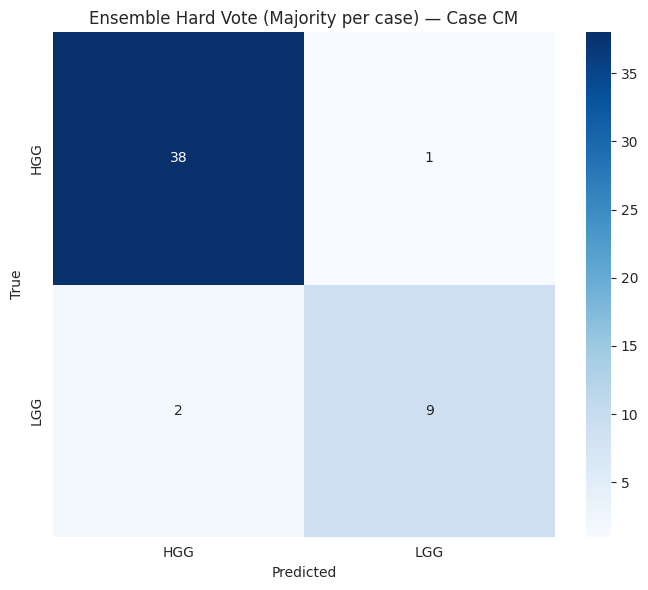

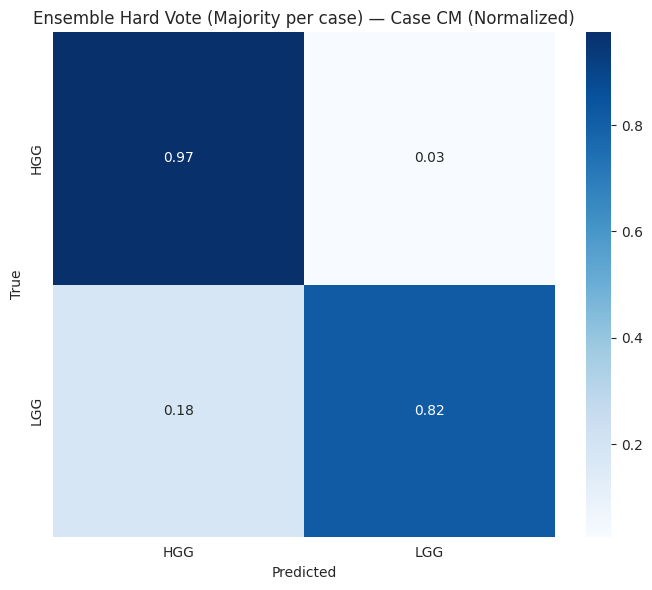

In [48]:
def report_case(title, y_true_case, y_pred_case):
    print("\n" + "="*80)
    print(f"🏥 CASE LEVEL — {title}")
    print("="*80)
    print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
    print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))
    plot_cm(y_true_case, y_pred_case, f"{title} — Case CM", CLASS_NAMES, normalize=False)
    plot_cm(y_true_case, y_pred_case, f"{title} — Case CM", CLASS_NAMES, normalize=True)

# Case-level for SOFT vote: mean probability per case
y_true_case_soft, y_pred_case_soft, mean_probs_soft = case_level_meanprob(soft_prob, case_keys, clean_case_index)
report_case("Ensemble Soft Vote (MeanProb per case)", y_true_case_soft, y_pred_case_soft)

# Case-level for HARD vote: majority vote per case
y_true_case_hard, y_pred_case_hard = case_level_majority(hard_pred, case_keys, clean_case_index, n_classes=2)
report_case("Ensemble Hard Vote (Majority per case)", y_true_case_hard, y_pred_case_hard)


In [49]:
print("Test slices:", len(test_gen.samples))
print("Unique test cases:", len(set([ck for (ck, _, _) in test_gen.samples])))
print("Test label counts:", np.bincount(y_true_slice, minlength=2))


Test slices: 655
Unique test cases: 50
Test label counts: [468 187]


# DenseNet

In [19]:
# ============================================================
# CELL 1 — Imports (DenseNet staged training)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [20]:
# ============================================================
# CELL 2 — Build DenseNet (4ch->3ch adapter) with configurable dropout
# ============================================================
INPUT_SHAPE = (240,240,4)

def build_densenet121_4ch(
    input_shape=INPUT_SHAPE,
    num_classes=2,
    adapter_filters=32,
    l2_reg=1e-4,
    dropout1=0.6,       # stage0: high
    dropout2=0.4,       # stage0: high
    use_densenet_preprocess=False
):
    inp = layers.Input(shape=input_shape, name="inp_4ch")

    # Adapter: 4ch -> adapter_filters -> 3ch
    x = layers.Conv2D(adapter_filters, 3, padding="same", activation="relu", name="adapter_conv3x3")(inp)
    x = layers.BatchNormalization(name="adapter_bn")(x)
    x = layers.Conv2D(3, 1, padding="same", activation="linear", name="adapter_to3")(x)

    # Optional preprocess (often expects ImageNet scaling; your MRI is already [0,1])
    if use_densenet_preprocess:
        x = tf.keras.applications.densenet.preprocess_input(x)

    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(input_shape[0], input_shape[1], 3)
    )
    backbone.trainable = False

    y = backbone(x, training=False)

    y = layers.GlobalAveragePooling2D(name="gap")(y)
    y = layers.Dropout(dropout1, name="drop1")(y)

    y = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg),
        name="dense256"
    )(y)
    y = layers.BatchNormalization(name="bn_head")(y)
    y = layers.Dropout(dropout2, name="drop2")(y)

    out = layers.Dense(num_classes, activation="softmax", name="pred")(y)

    model = models.Model(inp, out, name="DenseNet121_4ch")
    return model, backbone


In [22]:
# ============================================================
# CELL 3 — Compile + callbacks
# ============================================================
def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks(stage_name):
    return [
        ModelCheckpoint(
            filepath=f"best_densenet_{stage_name}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=6,
            restore_best_weights=True,
            verbose=1
        )
    ]


In [23]:
# ============================================================
# CELL 4 — STAGE 0: Frozen backbone + HIGH dropout
# ============================================================
HIGH_D1, HIGH_D2 = 0.6, 0.4

model0, backbone0 = build_densenet121_4ch(
    dropout1=HIGH_D1,
    dropout2=HIGH_D2,
    l2_reg=1e-4,
    use_densenet_preprocess=False  # recommended since MRI already [0,1]
)
compile_model(model0, lr=1e-3)

print(model0.summary())

history0 = model0.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks("stage0_frozen_highdrop"),
    verbose=1
)

plot_learning_curves(history0, title_prefix="DenseNet Stage 0 (Frozen, HIGH dropout) —")
eval_all(model0, "DenseNet Stage 0 (Frozen, HIGH dropout)", test_gen, clean_case_index)

# save weights for stage1 transfer
model0.save_weights("densenet_stage0_highdrop.weights.h5")
print("✅ Saved Stage 0 weights.")


I0000 00:00:1771525469.429362      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_4ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp_4ch (InputLayer)            │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_conv3x3 (Conv2D)        │ (None, 240, 240, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_bn (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_to3 (Conv2D)            │ (None, 240, 240, 3)    │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,853 (27.86 MB)

...

I0000 00:00:1771525491.366637     131 service.cc:152] XLA service 0x7fcf982932f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771525491.366676     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771525495.147155     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/238 ━━━━━━━━━━━━━━━━━━━━ 2:59:42 45s/step - accuracy: 0.4062 - auc: 0.4248 - loss: 1.2222 - precision: 0.4062 - recall: 0.4062

I0000 00:00:1771525521.384827     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6434 - auc: 0.6897 - loss: 0.8581 - precision: 0.6434 - recall: 0.6434
Epoch 1: val_auc improved from -inf to 0.50429, saving model to best_densenet_stage0_frozen_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.6437 - auc: 0.6900 - loss: 0.8574 - precision: 0.6437 - recall: 0.6437 - val_accuracy: 0.4303 - val_auc: 0.5043 - val_loss: 1.2860 - val_precision: 0.4303 - val_recall: 0.4303 - learning_rate: 0.0010
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8099 - auc: 0.8756 - loss: 0.4805 - precision: 0.8099 - recall: 0.8099
Epoch 2: val_auc improved from 0.50429 to 0.65031, saving model to best_densenet_stage0_frozen_highdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.8099 - auc: 0.8756 - loss: 0.4805 - precision: 0.8099 - recall: 0.8099 - val_accuracy: 0.5955 - val_auc: 0.6503 - val_loss: 0.8182 - val_precision: 0.5955 - val_recall: 0.5955 - learning_rate: 0.0010
Epoch 3/20

NameError: name 'plot_learning_curves' is not defined

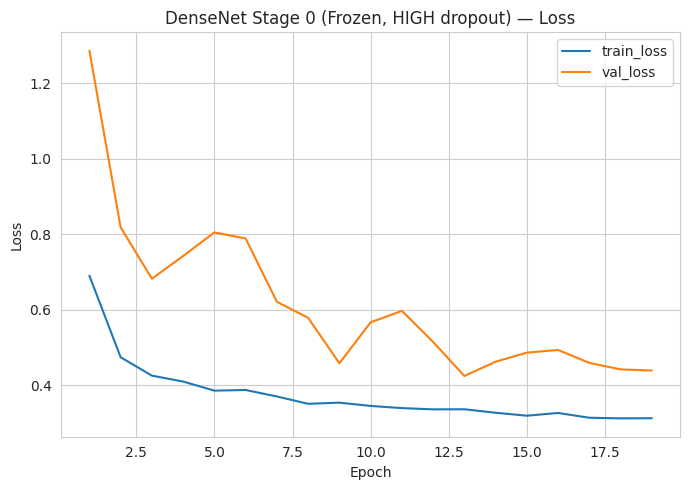

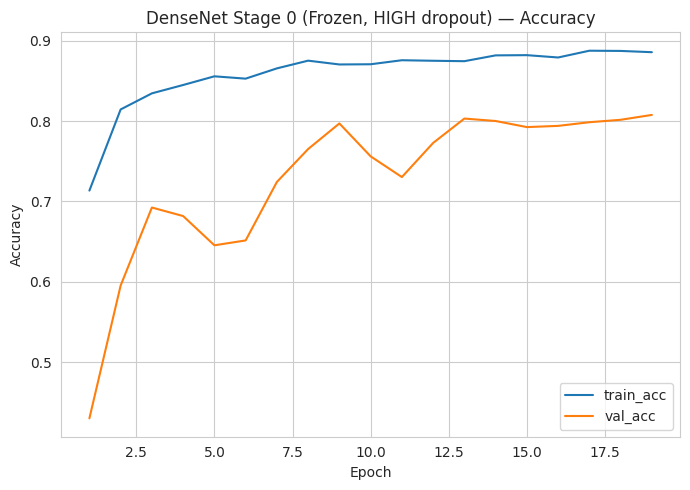

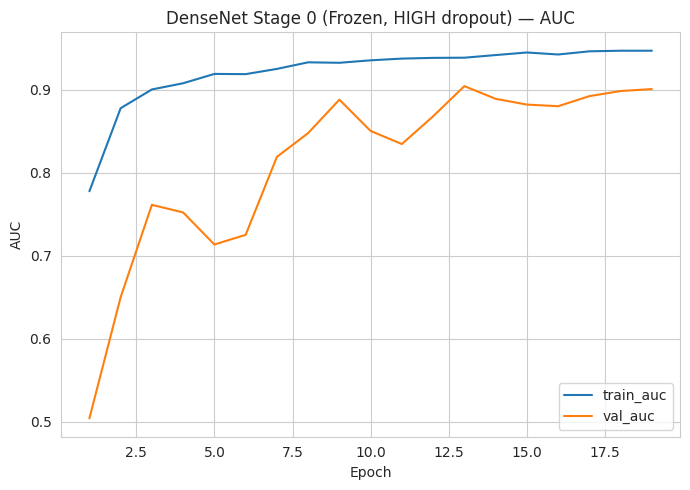


📊 EVALUATION — DenseNet Stage 0 (Frozen, HIGH dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.7269 - auc: 0.8392 - loss: 0.4945 - precision: 0.7269 - recall: 0.7269

Keras metrics: {'loss': 0.42161861062049866, 'compile_metrics': 0.7969465851783752}
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step

--- SLICE LEVEL ---
Accuracy: 79.69%

              precision    recall  f1-score   support

         HGG     0.9351    0.7692    0.8441       468
         LGG     0.6000    0.8663    0.7090       187

    accuracy                         0.7969       655
   macro avg     0.7675    0.8178    0.7765       655
weighted avg     0.8394    0.7969    0.8055       655



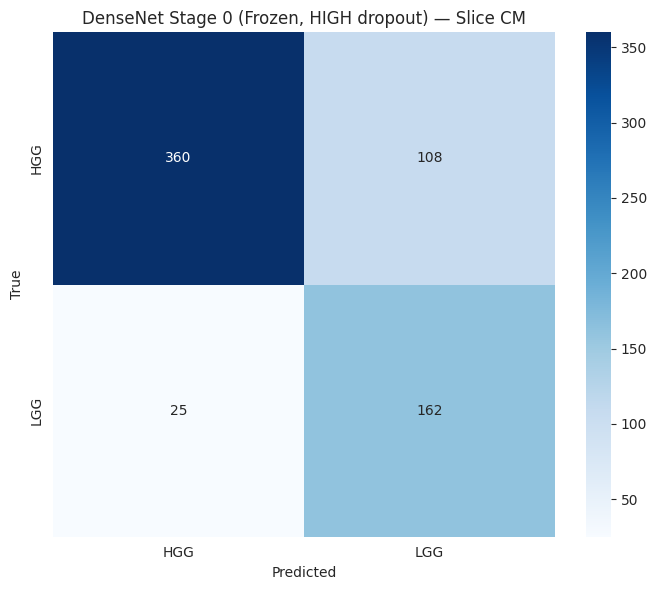

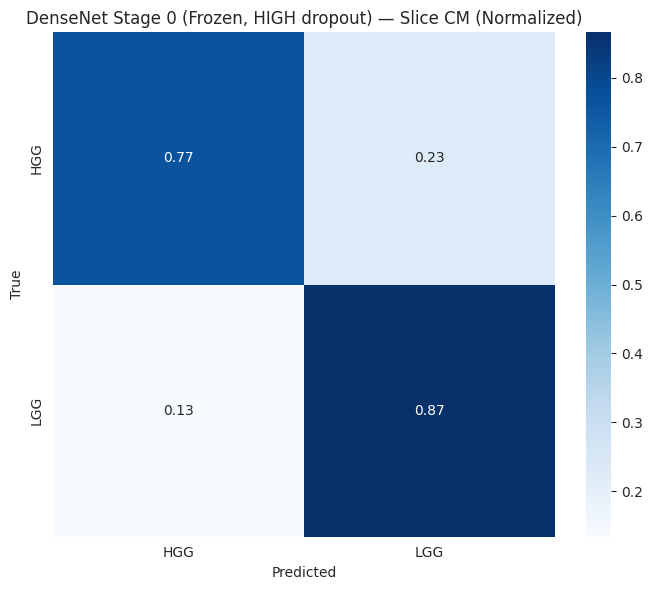


--- CASE LEVEL (Majority Vote) ---
Accuracy: 78.00%

              precision    recall  f1-score   support

         HGG     0.9375    0.7692    0.8451        39
         LGG     0.5000    0.8182    0.6207        11

    accuracy                         0.7800        50
   macro avg     0.7188    0.7937    0.7329        50
weighted avg     0.8413    0.7800    0.7957        50



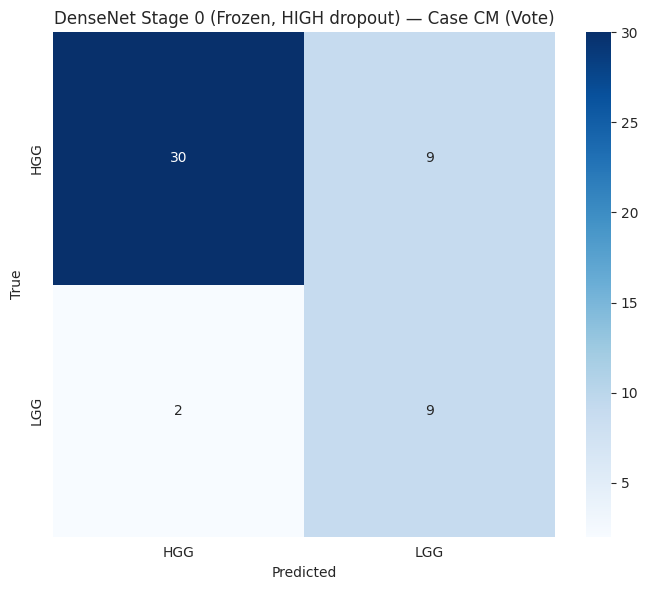

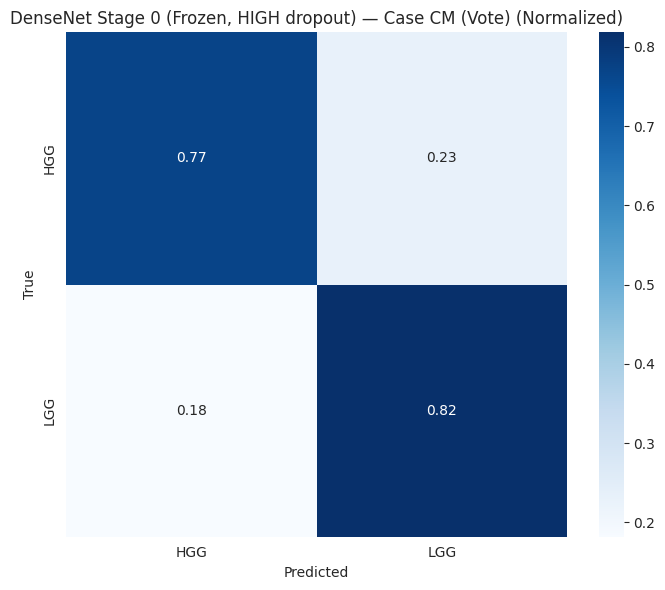


--- CASE LEVEL (Mean Probability) ---
Accuracy: 78.00%

              precision    recall  f1-score   support

         HGG     0.9375    0.7692    0.8451        39
         LGG     0.5000    0.8182    0.6207        11

    accuracy                         0.7800        50
   macro avg     0.7188    0.7937    0.7329        50
weighted avg     0.8413    0.7800    0.7957        50



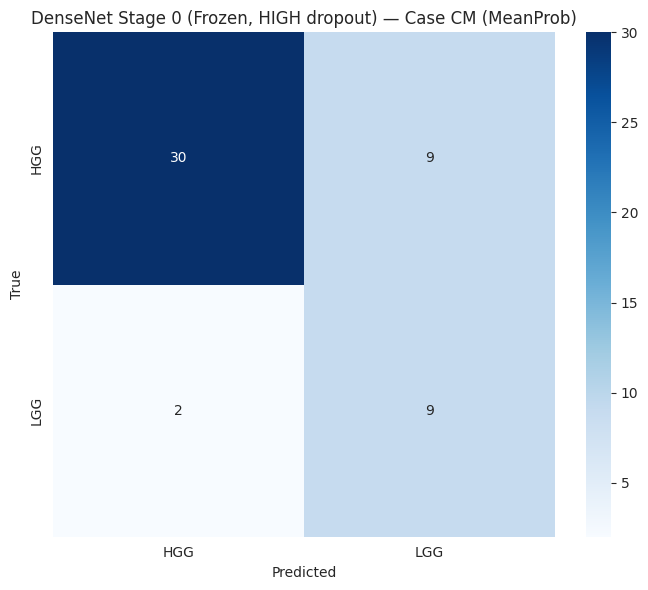

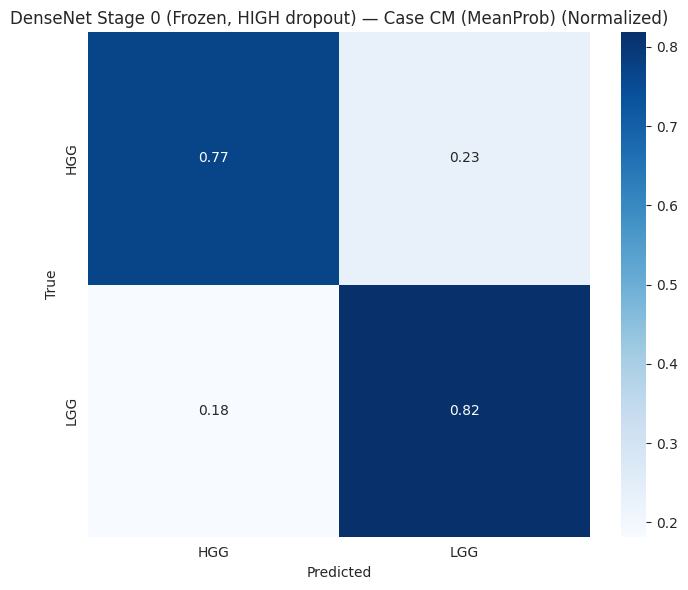

✅ Saved Stage 0 weights.


In [27]:
plot_learning_curves(history0, title_prefix="DenseNet Stage 0 (Frozen, HIGH dropout) —")
eval_all(model0, "DenseNet Stage 0 (Frozen, HIGH dropout)", test_gen, clean_case_index)

# save weights for stage1 transfer
model0.save_weights("densenet_stage0_highdrop.weights.h5")
print("✅ Saved Stage 0 weights.")

In [28]:
# ============================================================
# CELL 5 — Build Stage 1 model: LOWER dropout + load stage0 weights
# ============================================================
LOW_D1, LOW_D2 = 0.3, 0.2

model1, backbone1 = build_densenet121_4ch(
    dropout1=LOW_D1,
    dropout2=LOW_D2,
    l2_reg=1e-4,
    use_densenet_preprocess=False
)

model1.load_weights("densenet_stage0_highdrop.weights.h5")
print("✅ Loaded Stage 0 weights into Stage 1 model.")


✅ Loaded Stage 0 weights into Stage 1 model.


In [29]:
# ============================================================
# CELL 6 — Fine-tuning: unfreeze last N layers (keep BatchNorm frozen)
# ============================================================
def unfreeze_last_n_layers(backbone, n=60):
    backbone.trainable = True

    # freeze all first
    for layer in backbone.layers:
        layer.trainable = False

    # unfreeze last N except BN
    for layer in backbone.layers[-n:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Start safe: 40-80 is typical. Try 40 first if unstable.
unfreeze_last_n_layers(backbone1, n=60)

compile_model(model1, lr=1e-5)

trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model1.trainable_weights])
print("Trainable params:", trainable_params)


Trainable params: 1497669


Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.9040 - auc: 0.9616 - loss: 0.2701 - precision: 0.9040 - recall: 0.9040
Epoch 1: val_auc improved from -inf to 0.91348, saving model to best_densenet_stage1_finetune_lowdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9040 - auc: 0.9616 - loss: 0.2702 - precision: 0.9040 - recall: 0.9040 - val_accuracy: 0.8197 - val_auc: 0.9135 - val_loss: 0.4223 - val_precision: 0.8197 - val_recall: 0.8197 - learning_rate: 1.0000e-05
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.9035 - auc: 0.9595 - loss: 0.2766 - precision: 0.9035 - recall: 0.9035
Epoch 2: val_auc improved from 0.91348 to 0.91787, saving model to best_densenet_stage1_finetune_lowdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.9035 - auc: 0.9595 - loss: 0.2766 - precision: 0.9035 - recall: 0.9035 - val_accuracy: 0.8212 - val_auc: 0.9179 - val_loss: 0.4096 - val_precision: 0.8212 - val_recall: 0.8212 - learning_

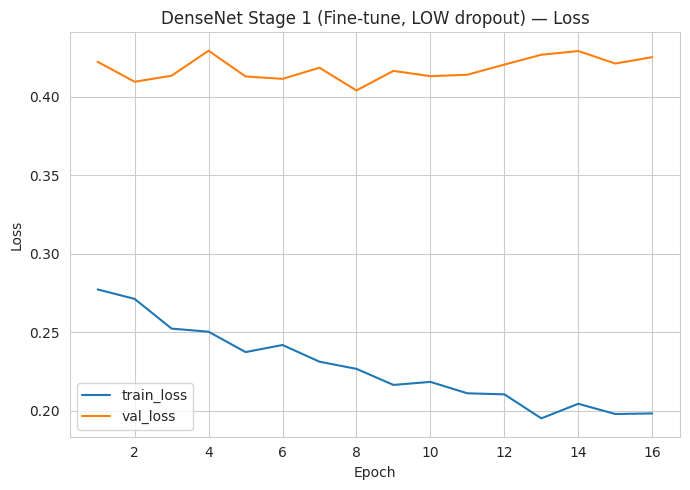

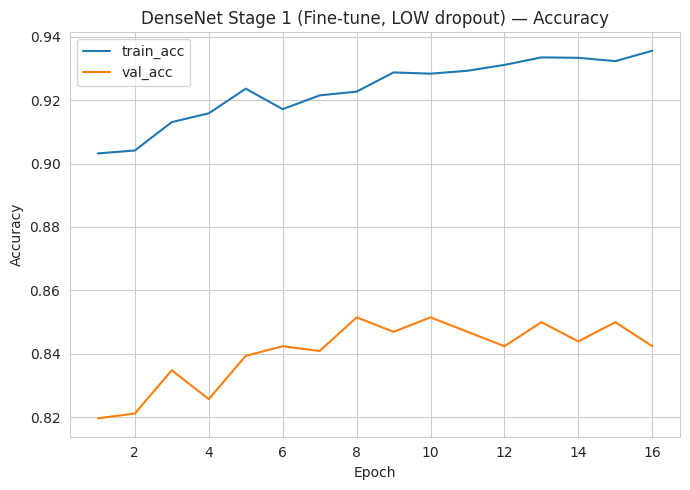

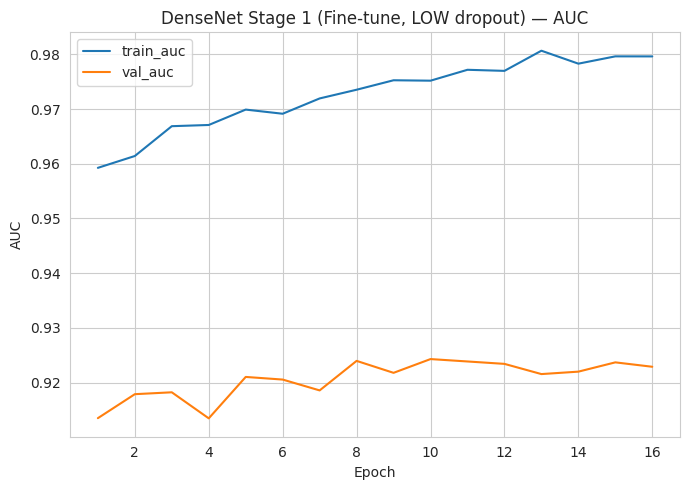


📊 EVALUATION — DenseNet Stage 1 (Fine-tune, LOW dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 882ms/step - accuracy: 0.8235 - auc: 0.8893 - loss: 0.4662 - precision: 0.8235 - recall: 0.8235

Keras metrics: {'loss': 0.39695435762405396, 'compile_metrics': 0.8595420122146606}
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 966ms/step

--- SLICE LEVEL ---
Accuracy: 85.95%

              precision    recall  f1-score   support

         HGG     0.9052    0.8974    0.9013       468
         LGG     0.7487    0.7647    0.7566       187

    accuracy                         0.8595       655
   macro avg     0.8269    0.8311    0.8290       655
weighted avg     0.8605    0.8595    0.8600       655



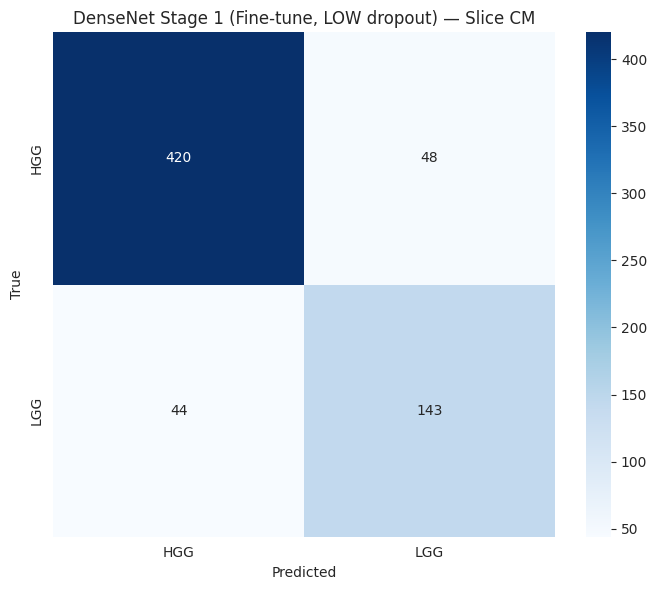

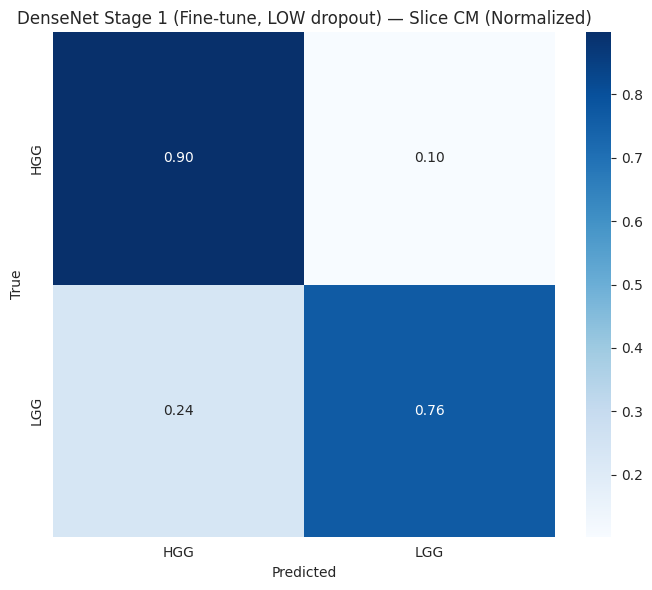


--- CASE LEVEL (Majority Vote) ---
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9474    0.9231    0.9351        39
         LGG     0.7500    0.8182    0.7826        11

    accuracy                         0.9000        50
   macro avg     0.8487    0.8706    0.8588        50
weighted avg     0.9039    0.9000    0.9015        50



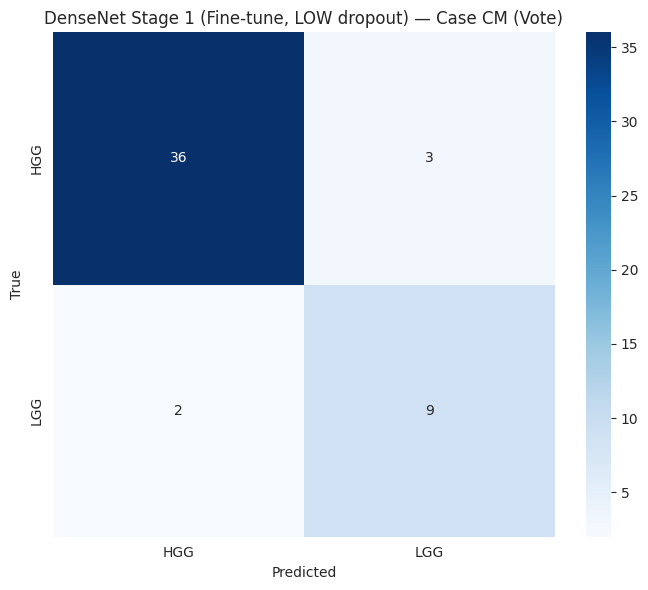

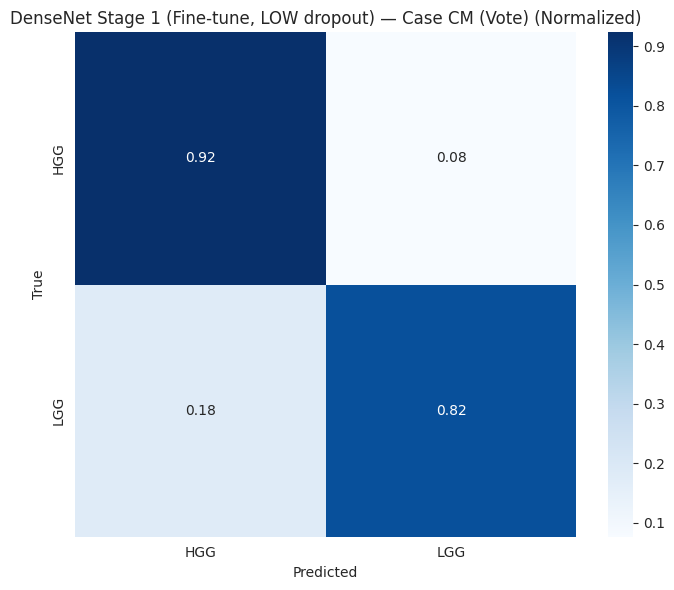


--- CASE LEVEL (Mean Probability) ---
Accuracy: 92.00%

              precision    recall  f1-score   support

         HGG     0.9487    0.9487    0.9487        39
         LGG     0.8182    0.8182    0.8182        11

    accuracy                         0.9200        50
   macro avg     0.8834    0.8834    0.8834        50
weighted avg     0.9200    0.9200    0.9200        50



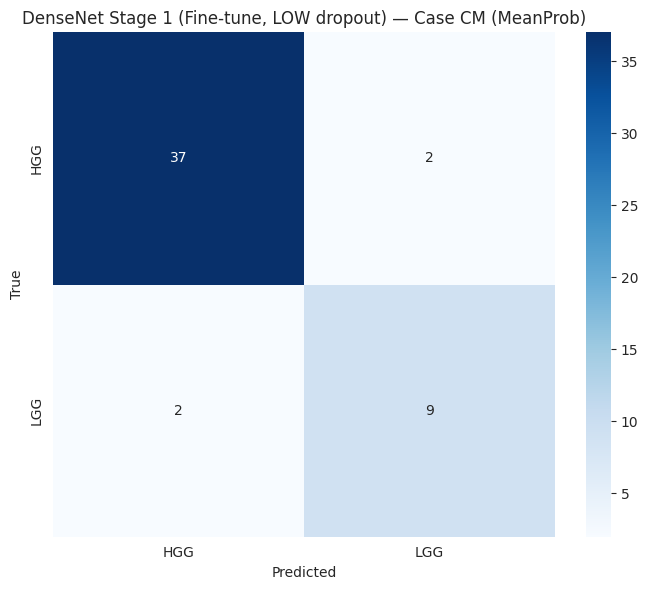

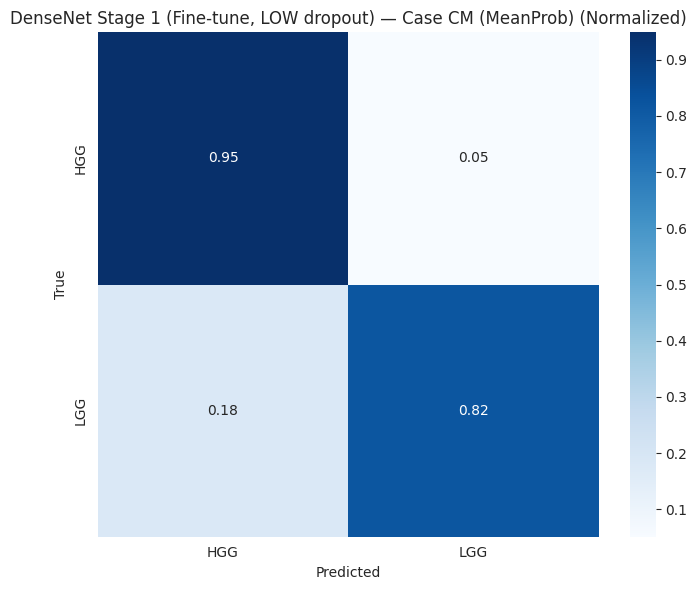

In [30]:
# ============================================================
# CELL 7 — STAGE 1: Fine-tune (LOW dropout + partial backbone unfrozen)
# ============================================================
history1 = model1.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks("stage1_finetune_lowdrop"),
    verbose=1
)

plot_learning_curves(history1, title_prefix="DenseNet Stage 1 (Fine-tune, LOW dropout) —")
eval_all(model1, "DenseNet Stage 1 (Fine-tune, LOW dropout)", test_gen, clean_case_index)


In [31]:
model1.save_weights("densenet_stage1_lowdrop.weights.h5")
print("✅ Saved Stage 1 weights.")


✅ Saved Stage 1 weights.


In [32]:
# Stage 2 dropout (even lower)
STAGE2_D1, STAGE2_D2 = 0.15, 0.10

model2, backbone2 = build_densenet121_4ch(
    dropout1=STAGE2_D1,
    dropout2=STAGE2_D2,
    l2_reg=1e-4,
    use_densenet_preprocess=False
)

model2.load_weights("densenet_stage1_lowdrop.weights.h5")
print("✅ Loaded Stage 1 weights into Stage 2 model.")


✅ Loaded Stage 1 weights into Stage 2 model.


In [33]:
def unfreeze_last_n_layers(backbone, n=140):
    backbone.trainable = True

    # Freeze all first
    for layer in backbone.layers:
        layer.trainable = False

    # Unfreeze last N except BatchNorm
    for layer in backbone.layers[-n:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# More aggressive fine-tune than stage 1
unfreeze_last_n_layers(backbone2, n=140)

# Smaller LR for deeper fine-tuning
compile_model(model2, lr=5e-6)

trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model2.trainable_weights])
print("✅ Stage 2 ready.")
print("Trainable params:", trainable_params)


✅ Stage 2 ready.
Trainable params: 3398213


Epoch 1/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.9347 - auc: 0.9813 - loss: 0.1924 - precision: 0.9347 - recall: 0.9347
Epoch 1: val_auc improved from -inf to 0.92251, saving model to best_densenet_stage2_more_finetune_lessdrop.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 272s 958ms/step - accuracy: 0.9347 - auc: 0.9813 - loss: 0.1924 - precision: 0.9347 - recall: 0.9347 - val_accuracy: 0.8409 - val_auc: 0.9225 - val_loss: 0.4327 - val_precision: 0.8409 - val_recall: 0.8409 - learning_rate: 5.0000e-06
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9328 - auc: 0.9777 - loss: 0.2055 - precision: 0.9328 - recall: 0.9328
Epoch 2: val_auc did not improve from 0.92251
238/238 ━━━━━━━━━━━━━━━━━━━━ 186s 781ms/step - accuracy: 0.9329 - auc: 0.9777 - loss: 0.2055 - precision: 0.9329 - recall: 0.9329 - val_accuracy: 0.8439 - val_auc: 0.9172 - val_loss: 0.4421 - val_precision: 0.8439 - val_recall: 0.8439 - learning_rate: 5.0000e-06
Epoch 3/25
238/238 ━━━━━━━━━━━━━━━━━

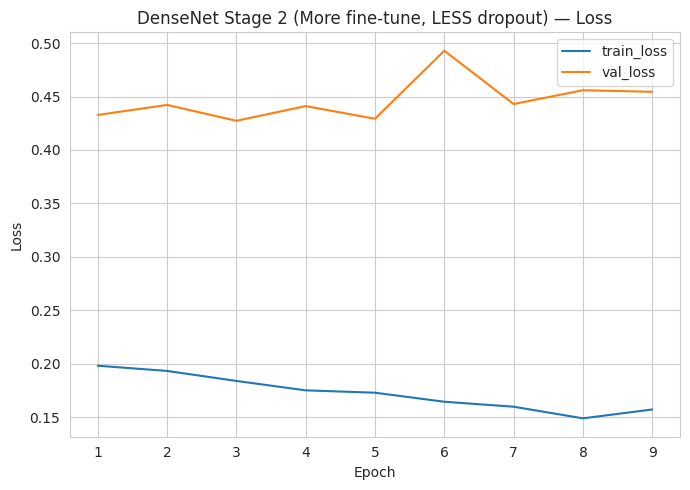

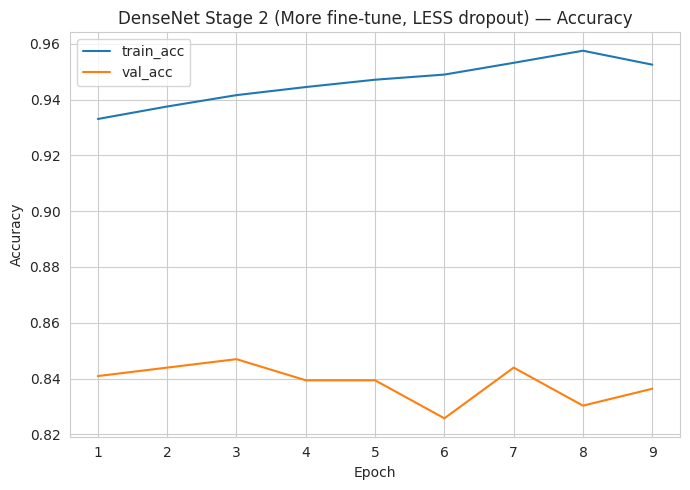

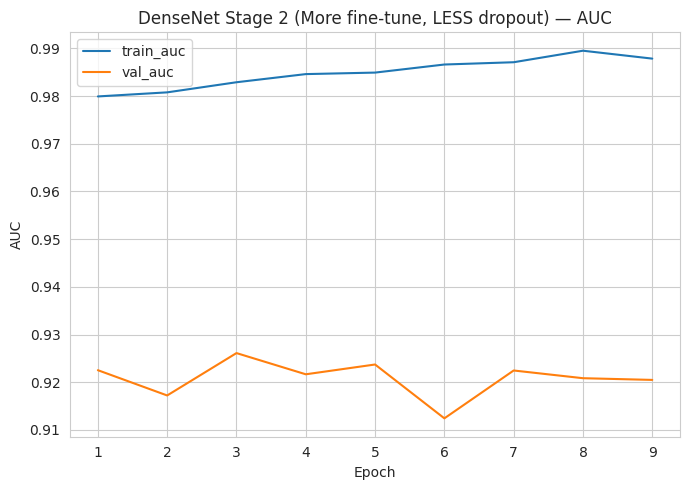


📊 EVALUATION — DenseNet Stage 2 (More fine-tune, LESS dropout)
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 838ms/step - accuracy: 0.8508 - auc: 0.8922 - loss: 0.4932 - precision: 0.8508 - recall: 0.8508

Keras metrics: {'loss': 0.4386012554168701, 'compile_metrics': 0.8748091459274292}
21/21 ━━━━━━━━━━━━━━━━━━━━ 32s 909ms/step

--- SLICE LEVEL ---
Accuracy: 87.48%

              precision    recall  f1-score   support

         HGG     0.8988    0.9295    0.9139       468
         LGG     0.8070    0.7380    0.7709       187

    accuracy                         0.8748       655
   macro avg     0.8529    0.8337    0.8424       655
weighted avg     0.8726    0.8748    0.8731       655



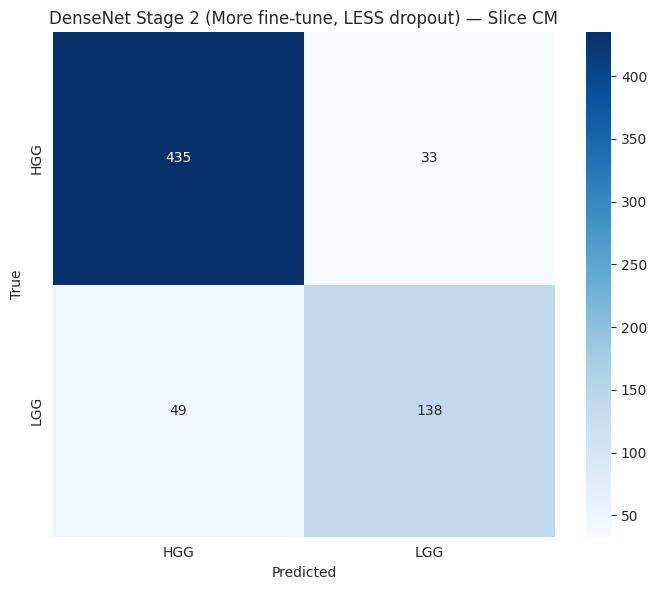

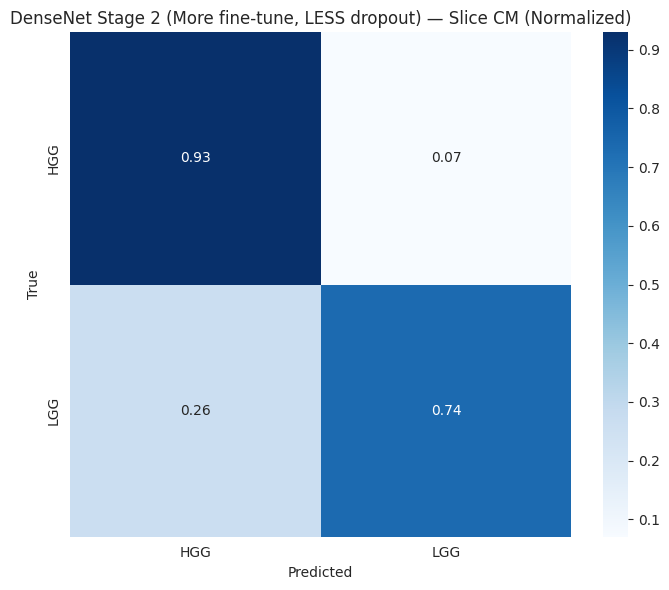


--- CASE LEVEL (Majority Vote) ---
Accuracy: 96.00%

              precision    recall  f1-score   support

         HGG     0.9512    1.0000    0.9750        39
         LGG     1.0000    0.8182    0.9000        11

    accuracy                         0.9600        50
   macro avg     0.9756    0.9091    0.9375        50
weighted avg     0.9620    0.9600    0.9585        50



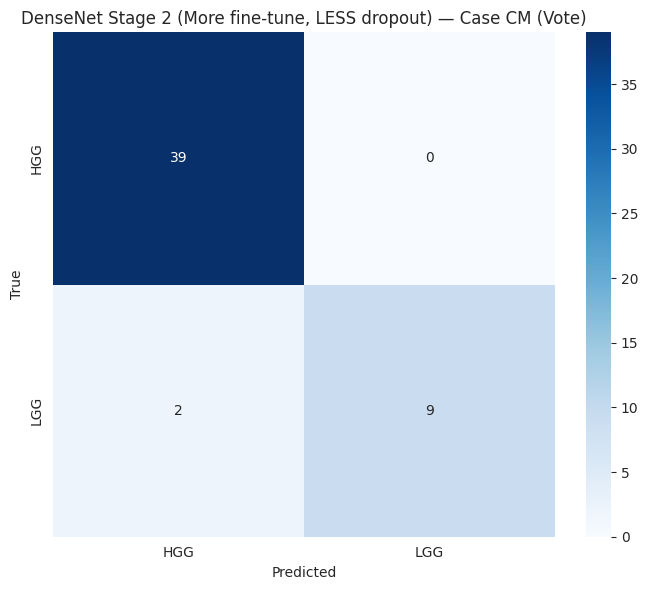

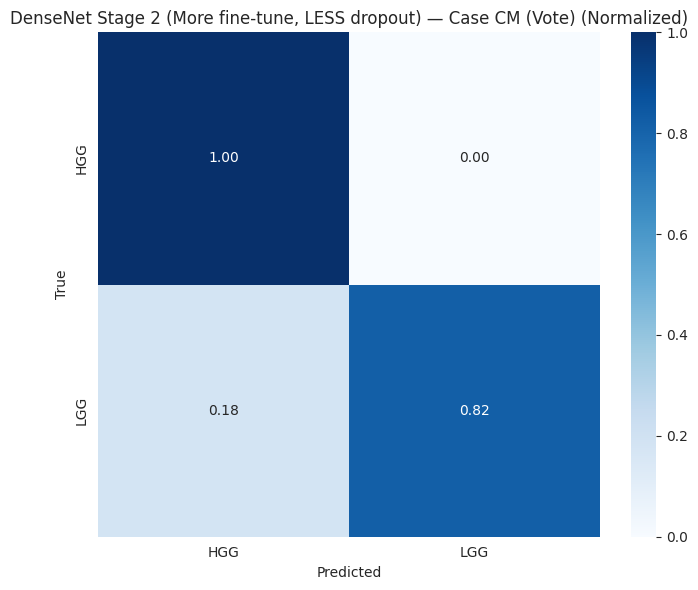


--- CASE LEVEL (Mean Probability) ---
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9250    0.9487    0.9367        39
         LGG     0.8000    0.7273    0.7619        11

    accuracy                         0.9000        50
   macro avg     0.8625    0.8380    0.8493        50
weighted avg     0.8975    0.9000    0.8983        50



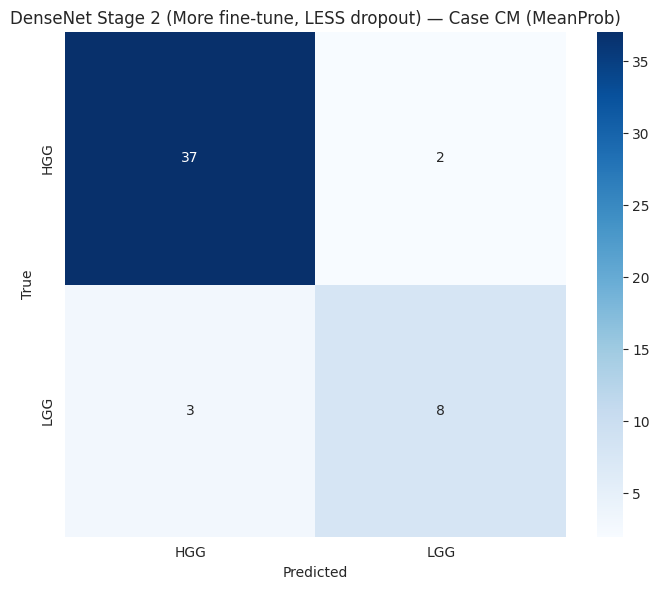

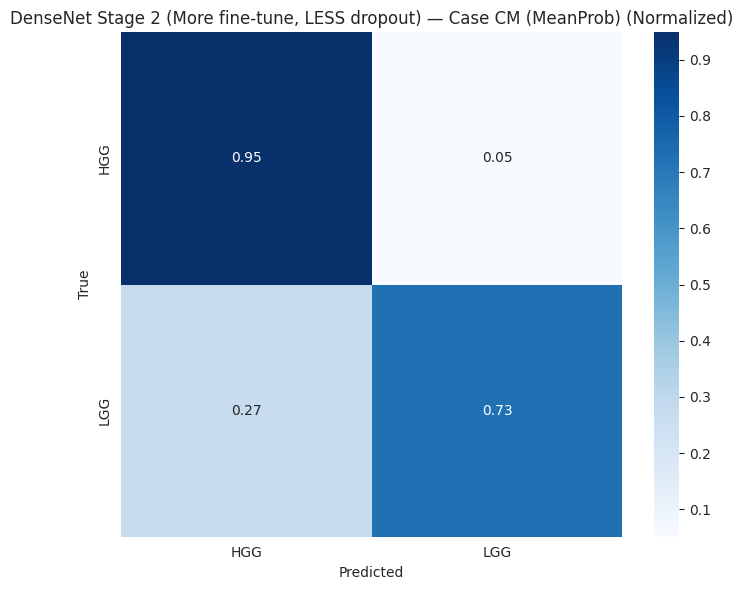

In [34]:
history2 = model2.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=25,
    callbacks=make_callbacks("stage2_more_finetune_lessdrop"),
    verbose=1
)

plot_learning_curves(history2, title_prefix="DenseNet Stage 2 (More fine-tune, LESS dropout) —")
eval_all(model2, "DenseNet Stage 2 (More fine-tune, LESS dropout)", test_gen, clean_case_index)


In [26]:
# ============================================================
# CELL 3 — Build EfficientNet-B0 with 4ch->3ch adapter
# ============================================================
INPUT_SHAPE = (240,240,4)
# ============================================================
# CELL 3 — Build EfficientNet-B0 with 4ch->3ch adapter (FIXED)
# ============================================================
def build_effnet_b0_4ch(
    input_shape=INPUT_SHAPE,   # (240,240,4)
    num_classes=cfg.NUM_CLASSES,
    adapter_filters=32,
    l2_reg=1e-2,
    dropout1=0.4,
    dropout2=0.2
):
    inp = layers.Input(shape=input_shape)

    # Adapter: 4 channels -> (adapter_filters) -> 3 channels
    x = layers.Conv2D(adapter_filters, 3, padding="same", activation="relu", name="adapter_conv3x3")(inp)
    x = layers.BatchNormalization(name="adapter_bn")(x)
    x = layers.Conv2D(3, 1, padding="same", activation="linear", name="adapter_to3")(x)

    # EfficientNet preprocess
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    # IMPORTANT:
    # Create EfficientNet normally (so ImageNet weights load cleanly),
    # then apply it to our tensor x.
    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_shape[0], input_shape[1], 3)  # <-- critical
    )
    backbone.trainable = False

    y = backbone(x, training=False)  # training=False keeps BN behavior stable during frozen stage

    y = layers.GlobalAveragePooling2D(name="gap")(y)
    y = layers.Dropout(dropout1, name="drop1")(y)

    y = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg),
        name="dense256"
    )(y)
    y = layers.BatchNormalization(name="bn_head")(y)
    y = layers.Dropout(dropout2, name="drop2")(y)

    out = layers.Dense(num_classes, activation="softmax", name="pred")(y)

    model = models.Model(inp, out, name="EffNetB0_4ch")

    return model, backbone



In [27]:
# ============================================================
# CELL 4 — Compile helper + callbacks
# ============================================================
def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks(stage_name):
    return [
        ModelCheckpoint(
            filepath=f"best_effnet_{stage_name}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=6,
            restore_best_weights=True,
            verbose=1
        )
    ]


I0000 00:00:1771362085.555734      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EffNetB0_4ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_conv3x3 (Conv2D)        │ (None, 240, 240, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_bn (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_to3 (Conv2D)            │ (None, 240, 240, 3)    │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,456 (16.71 MB)

 Trainable params: 330,309 (1.26 MB)

 Non-trainable params: 4,050,147 (15.45 MB)

None
Epoch 1/20


I0000 00:00:1771362103.482404     127 service.cc:152] XLA service 0x7c19e8114e70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771362103.482444     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771362106.611297     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771362125.976445     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.6574 - auc: 0.7110 - loss: 3.3279 - precision: 0.6574 - recall: 0.6574
Epoch 1: val_auc improved from -inf to 0.48638, saving model to best_effnet_stage0_frozen.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.6577 - auc: 0.7114 - loss: 3.3229 - precision: 0.6577 - recall: 0.6577 - val_accuracy: 0.4652 - val_auc: 0.4864 - val_loss: 1.3483 - val_precision: 0.4652 - val_recall: 0.4652 - learning_rate: 0.0010
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.8062 - auc: 0.8699 - loss: 0.9566 - precision: 0.8062 - recall: 0.8062
Epoch 2: val_auc improved from 0.48638 to 0.84292, saving model to best_effnet_stage0_frozen.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 149s 731ms/step - accuracy: 0.8062 - auc: 0.8699 - loss: 0.9561 - precision: 0.8062 - recall: 0.8062 - val_accuracy: 0.7621 - val_auc: 0.8429 - val_loss: 0.7618 - val_precision: 0.7621 - val_recall: 0.7621 - learning_rate: 0.0010
Epoch 3/20
204/204 ━━━━

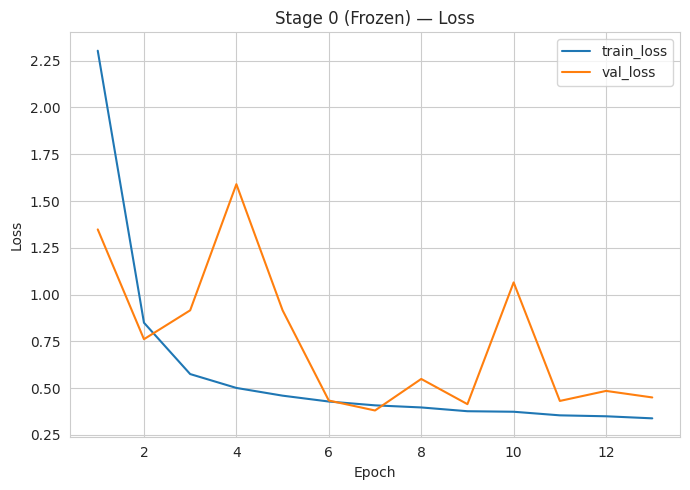

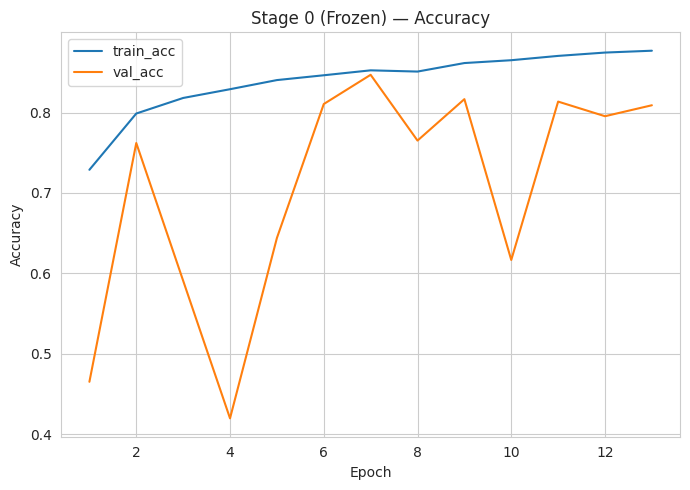

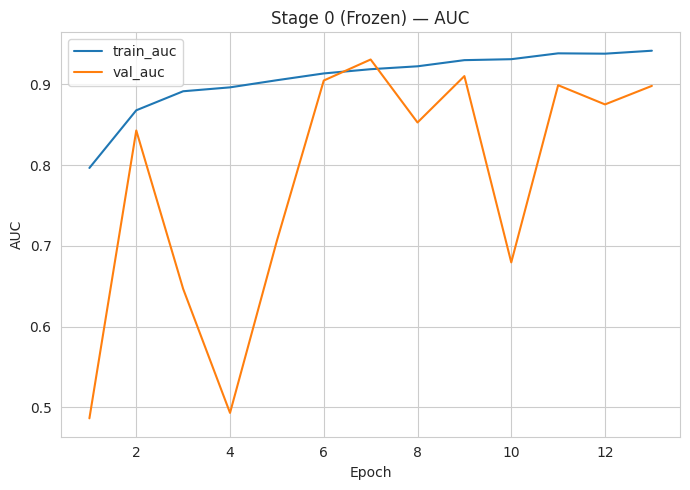


📊 EVALUATION — Stage 0 (Frozen Backbone)
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 911ms/step - accuracy: 0.8309 - auc: 0.9145 - loss: 0.4140 - precision: 0.8309 - recall: 0.8309

Keras metrics: {'loss': 0.4166426658630371, 'compile_metrics': 0.829007625579834}
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 560ms/step

--- SLICE LEVEL ---
Accuracy: 82.90%

              precision    recall  f1-score   support

         HGG     0.9120    0.8419    0.8756       468
         LGG     0.6682    0.7968    0.7268       187

    accuracy                         0.8290       655
   macro avg     0.7901    0.8193    0.8012       655
weighted avg     0.8424    0.8290    0.8331       655



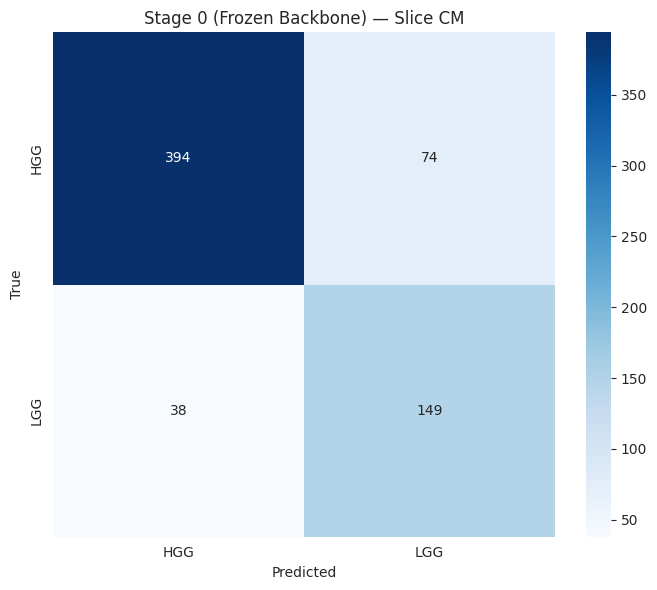

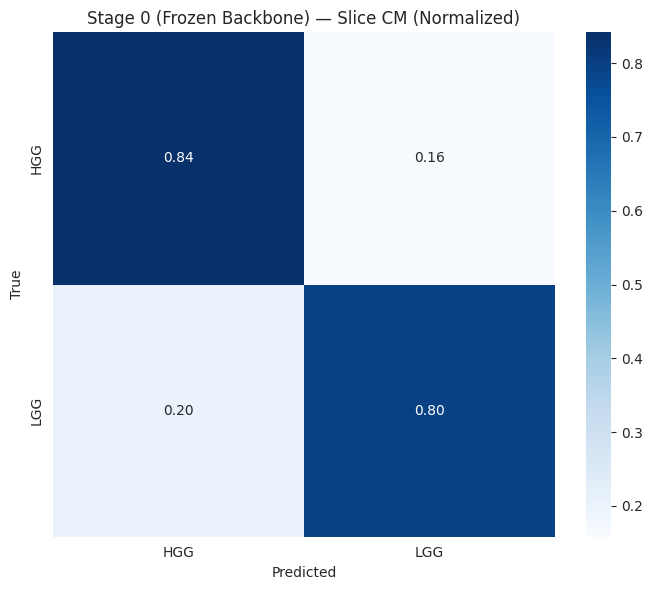


--- CASE LEVEL (Majority Vote) ---
Accuracy: 86.00%

              precision    recall  f1-score   support

         HGG     0.9444    0.8718    0.9067        39
         LGG     0.6429    0.8182    0.7200        11

    accuracy                         0.8600        50
   macro avg     0.7937    0.8450    0.8133        50
weighted avg     0.8781    0.8600    0.8656        50



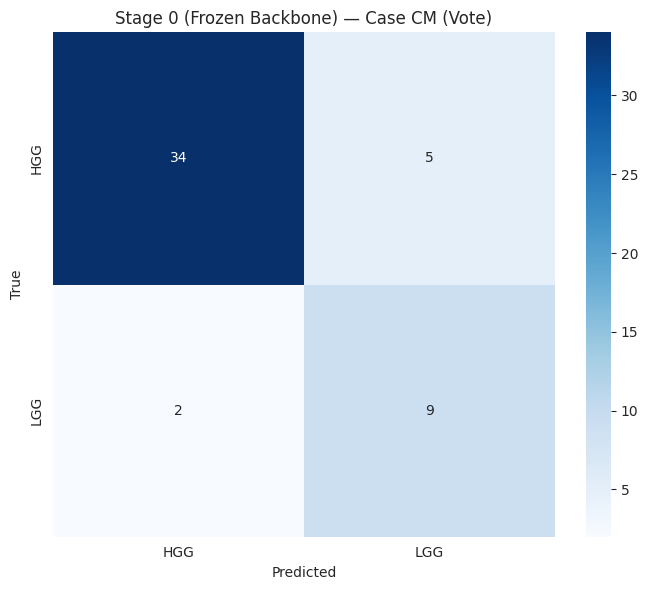

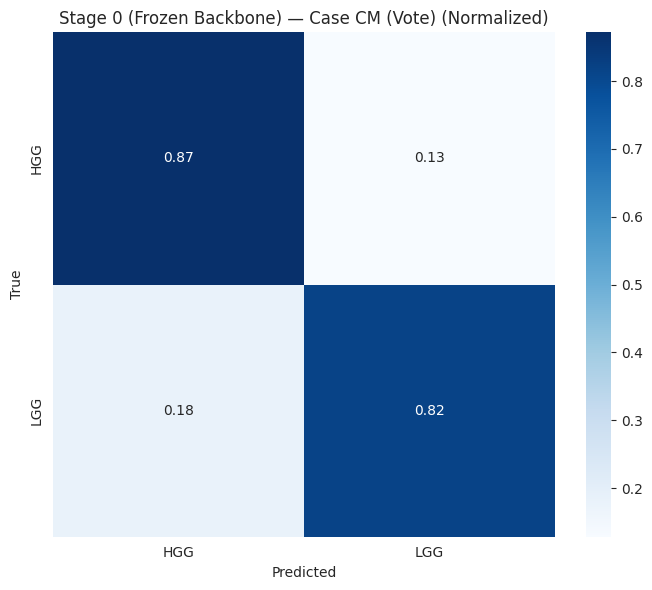


--- CASE LEVEL (Mean Probability) ---
Accuracy: 86.00%

              precision    recall  f1-score   support

         HGG     0.9444    0.8718    0.9067        39
         LGG     0.6429    0.8182    0.7200        11

    accuracy                         0.8600        50
   macro avg     0.7937    0.8450    0.8133        50
weighted avg     0.8781    0.8600    0.8656        50



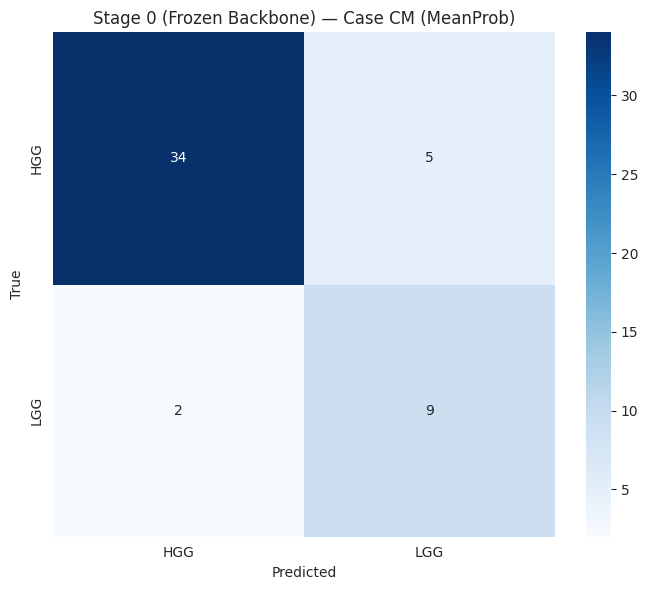

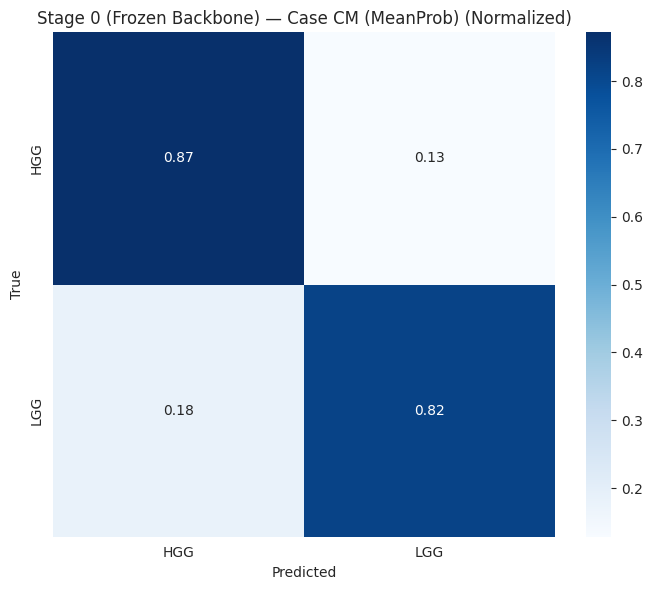

In [28]:
# ============================================================
# CELL 5 — STAGE 0: Train head with frozen EfficientNet backbone
# ============================================================
model, backbone = build_effnet_b0_4ch()
compile_model(model, lr=1e-3)

print(model.summary())

history0 = model.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=20,
    # class_weight=class_weight_dict,
    callbacks=make_callbacks("stage0_frozen"),
    verbose=1
)

plot_learning_curves(history0, title_prefix="Stage 0 (Frozen) —")
eval_all(model, "Stage 0 (Frozen Backbone)", test_gen, clean_case_index)


In [29]:
# ============================================================
# CELL 6 — Fine-tuning helper: unfreeze last % of backbone, freeze BN
# ============================================================
def set_finetune_backbone(backbone, unfreeze_ratio=0.3, freeze_batchnorm=True):
    """
    unfreeze_ratio: fraction of backbone layers to unfreeze from the end.
    Example: 0.2 => unfreeze last 20% layers
    """
    backbone.trainable = True
    n_layers = len(backbone.layers)
    cut = int(n_layers * (1 - unfreeze_ratio))

    for i, layer in enumerate(backbone.layers):
        if i < cut:
            layer.trainable = False
        else:
            layer.trainable = True

        if freeze_batchnorm and isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    trainable_count = np.sum([l.trainable for l in backbone.layers])
    print(f"Backbone layers: {n_layers}, Trainable now: {trainable_count} (ratio={unfreeze_ratio})")


Backbone layers: 238, Trainable now: 38 (ratio=0.2)
Epoch 1/15


2026-02-17 21:37:52.068562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:37:52.275764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:37:52.652591: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:37:52.859738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 32/204 ━━━━━━━━━━━━━━━━━━━━ 1:56 678ms/step - accuracy: 0.8608 - auc: 0.9273 - loss: 0.3843 - precision: 0.8608 - recall: 0.8608

2026-02-17 21:38:31.620791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:38:31.830464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:38:32.196087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:38:32.405508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.8574 - auc: 0.9259 - loss: 0.3890 - precision: 0.8574 - recall: 0.8574
Epoch 1: val_auc improved from -inf to 0.88260, saving model to best_effnet_stage1_ft20.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 206s 854ms/step - accuracy: 0.8574 - auc: 0.9259 - loss: 0.3890 - precision: 0.8574 - recall: 0.8574 - val_accuracy: 0.7955 - val_auc: 0.8826 - val_loss: 0.4741 - val_precision: 0.7955 - val_recall: 0.7955 - learning_rate: 1.0000e-05
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.8644 - auc: 0.9336 - loss: 0.3695 - precision: 0.8644 - recall: 0.8644
Epoch 2: val_auc improved from 0.88260 to 0.91301, saving model to best_effnet_stage1_ft20.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 147s 719ms/step - accuracy: 0.8644 - auc: 0.9336 - loss: 0.3695 - precision: 0.8644 - recall: 0.8644 - val_accuracy: 0.8318 - val_auc: 0.9130 - val_loss: 0.4120 - val_precision: 0.8318 - val_recall: 0.8318 - learning_rate: 1.0000e-05
Epoch 3/15
204/2

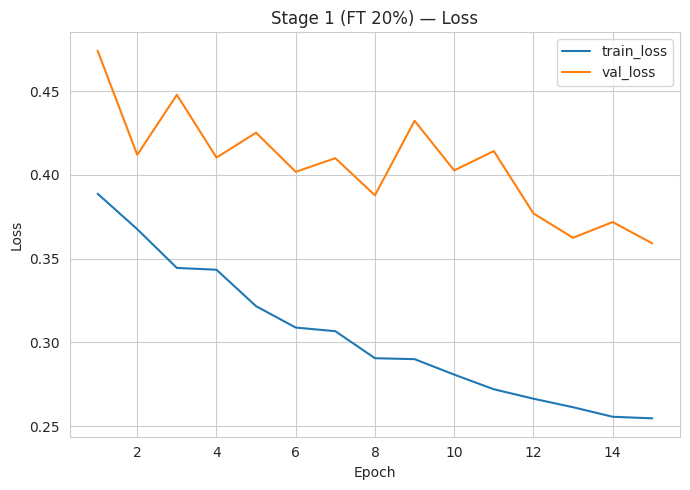

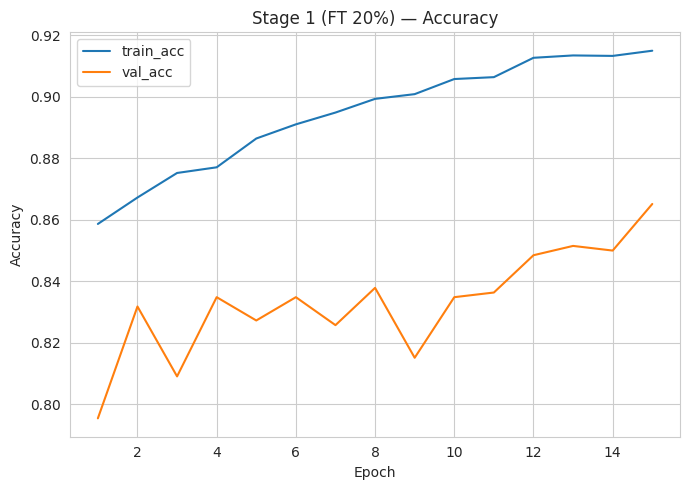

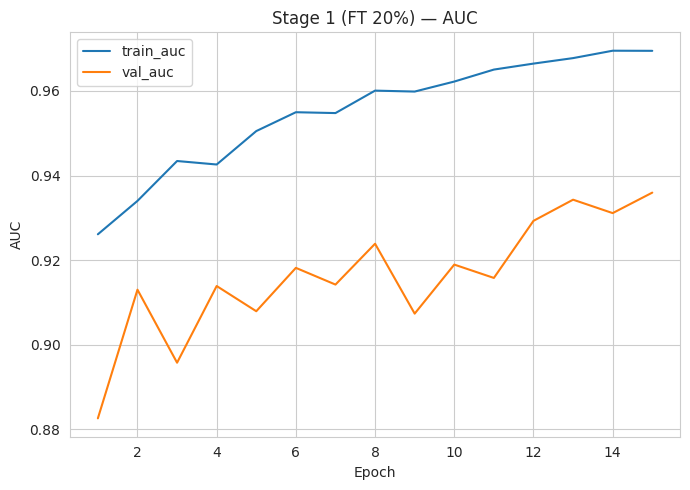


📊 EVALUATION — Stage 1 (Fine-tune last 20%)
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 546ms/step - accuracy: 0.8275 - auc: 0.9243 - loss: 0.3941 - precision: 0.8275 - recall: 0.8275

Keras metrics: {'loss': 0.416012167930603, 'compile_metrics': 0.8198473453521729}
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 549ms/step

--- SLICE LEVEL ---
Accuracy: 81.98%

              precision    recall  f1-score   support

         HGG     0.9051    0.8355    0.8689       468
         LGG     0.6547    0.7807    0.7122       187

    accuracy                         0.8198       655
   macro avg     0.7799    0.8081    0.7905       655
weighted avg     0.8336    0.8198    0.8242       655



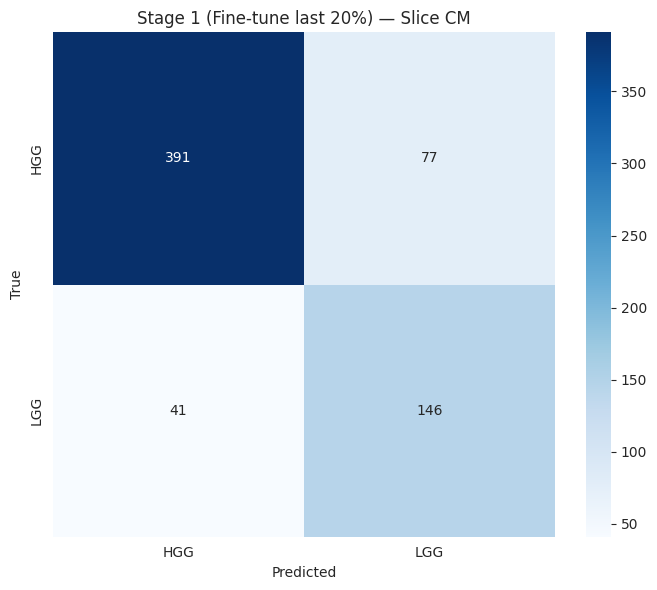

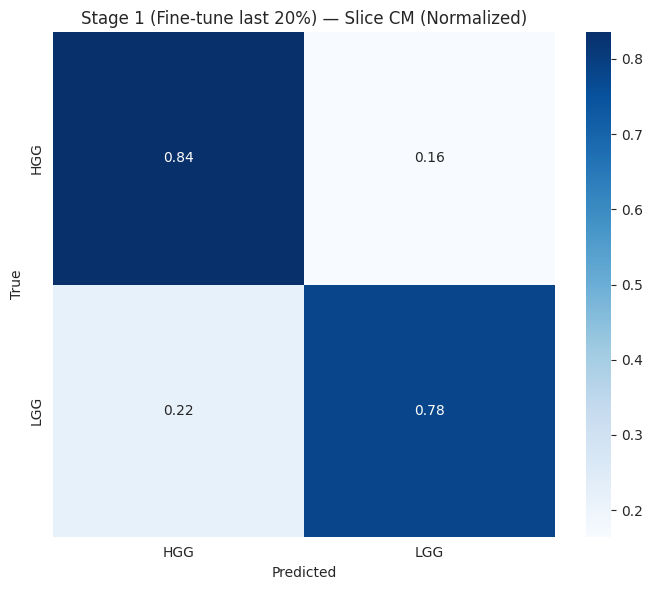


--- CASE LEVEL (Majority Vote) ---
Accuracy: 88.00%

              precision    recall  f1-score   support

         HGG     0.9459    0.8974    0.9211        39
         LGG     0.6923    0.8182    0.7500        11

    accuracy                         0.8800        50
   macro avg     0.8191    0.8578    0.8355        50
weighted avg     0.8901    0.8800    0.8834        50



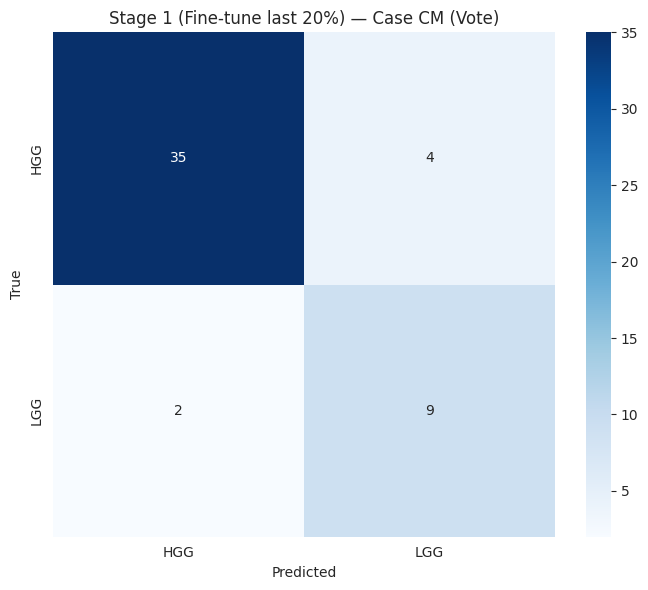

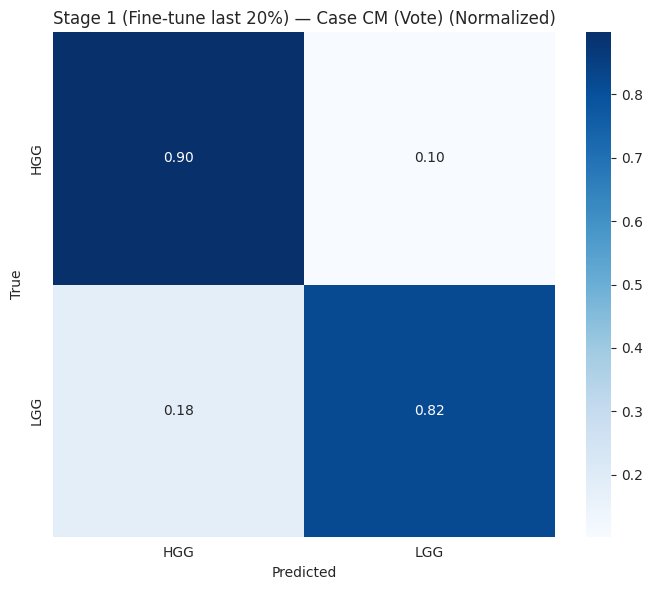


--- CASE LEVEL (Mean Probability) ---
Accuracy: 84.00%

              precision    recall  f1-score   support

         HGG     0.9429    0.8462    0.8919        39
         LGG     0.6000    0.8182    0.6923        11

    accuracy                         0.8400        50
   macro avg     0.7714    0.8322    0.7921        50
weighted avg     0.8674    0.8400    0.8480        50



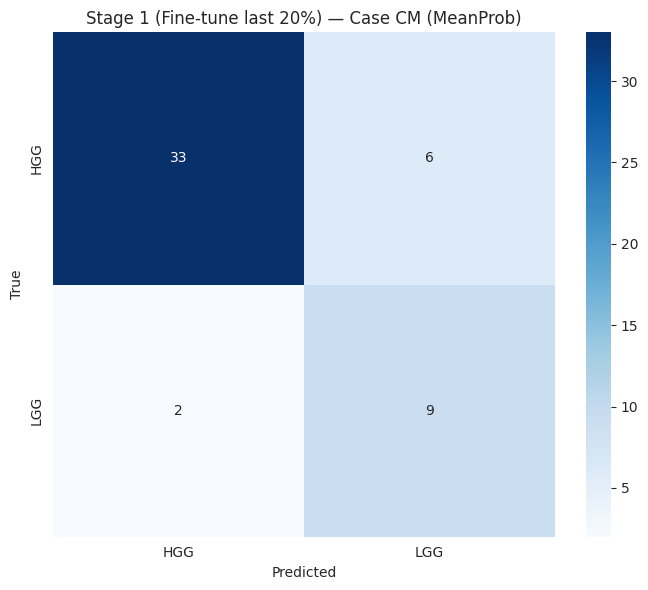

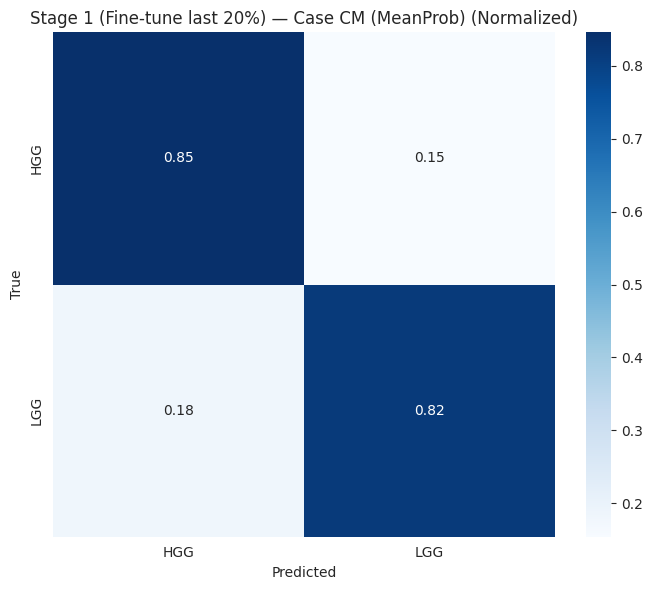

In [30]:
# ============================================================
# CELL 7 — STAGE 1: Fine-tune last 20% of backbone
# ============================================================
set_finetune_backbone(backbone, unfreeze_ratio=0.2, freeze_batchnorm=True)
compile_model(model, lr=1e-5)  # lower LR for fine-tuning

history1 = model.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=15,
    # class_weight=class_weight_dict,
    callbacks=make_callbacks("stage1_ft20"),
    verbose=1
)

plot_learning_curves(history1, title_prefix="Stage 1 (FT 20%) —")
eval_all(model, "Stage 1 (Fine-tune last 20%)", test_gen, clean_case_index)


In [31]:
# ============================================================
# CELL 7 — STAGE 2: Fine-tune last 30% of backbone
# ============================================================
set_finetune_backbone(backbone, unfreeze_ratio=0.3, freeze_batchnorm=True)
compile_model(model, lr=1e-5)  # lower LR for fine-tuning

history2 = model.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=make_callbacks("stage1_ft30_2"),
    verbose=1
)

plot_learning_curves(history2, title_prefix="Stage 2 (FT 30%) —")
eval_all(model, "Stage 2 (Fine-tune last 25%)", test_gen, clean_case_index)


Backbone layers: 238, Trainable now: 57 (ratio=0.3)
Epoch 1/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9147 - auc: 0.9715 - loss: 0.2611 - precision: 0.9147 - recall: 0.9147
Epoch 1: val_auc improved from -inf to 0.90716, saving model to best_effnet_stage1_ft30_2.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 209s 868ms/step - accuracy: 0.9147 - auc: 0.9715 - loss: 0.2612 - precision: 0.9147 - recall: 0.9147 - val_accuracy: 0.8136 - val_auc: 0.9072 - val_loss: 0.4566 - val_precision: 0.8136 - val_recall: 0.8136 - learning_rate: 1.0000e-05
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9085 - auc: 0.9663 - loss: 0.2620 - precision: 0.9085 - recall: 0.9085
Epoch 2: val_auc did not improve from 0.90716
204/204 ━━━━━━━━━━━━━━━━━━━━ 145s 712ms/step - accuracy: 0.9085 - auc: 0.9663 - loss: 0.2620 - precision: 0.9085 - recall: 0.9085 - val_accuracy: 0.8076 - val_auc: 0.8947 - val_loss: 0.5016 - val_precision: 0.8076 - val_recall: 0.8076 - learning_rate: 1.0000e-05
Ep

KeyboardInterrupt: 

Backbone layers: 238, Trainable now: 76 (ratio=0.4)
Epoch 1/10


2026-02-06 19:17:49.976065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-06 19:17:50.164760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


72/96 ━━━━━━━━━━━━━━━━━━━━ 15s 644ms/step - accuracy: 0.7990 - auc: 0.8810 - loss: 0.4881 - precision: 0.7990 - recall: 0.7990

2026-02-06 19:18:54.101160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-06 19:18:54.286229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.8034 - auc: 0.8837 - loss: 0.4868 - precision: 0.8034 - recall: 0.8034
Epoch 1: val_auc improved from -inf to 0.90863, saving model to best_effnet_stage2_ft60.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8035 - auc: 0.8838 - loss: 0.4868 - precision: 0.8035 - recall: 0.8035 - val_accuracy: 0.8182 - val_auc: 0.9086 - val_loss: 0.4974 - val_precision: 0.8182 - val_recall: 0.8182 - learning_rate: 5.0000e-06
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.8173 - auc: 0.8930 - loss: 0.4710 - precision: 0.8173 - recall: 0.8173
Epoch 2: val_auc improved from 0.90863 to 0.91022, saving model to best_effnet_stage2_ft60.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 67s 701ms/step - accuracy: 0.8173 - auc: 0.8931 - loss: 0.4710 - precision: 0.8173 - recall: 0.8173 - val_accuracy: 0.8227 - val_auc: 0.9102 - val_loss: 0.4888 - val_precision: 0.8227 - val_recall: 0.8227 - learning_rate: 5.0000e-06
Epoch 3/10
96/96 ━━━━━━━━━━━

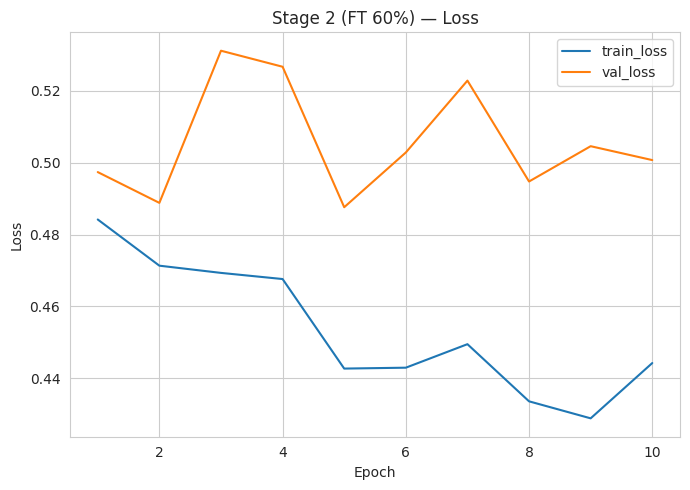

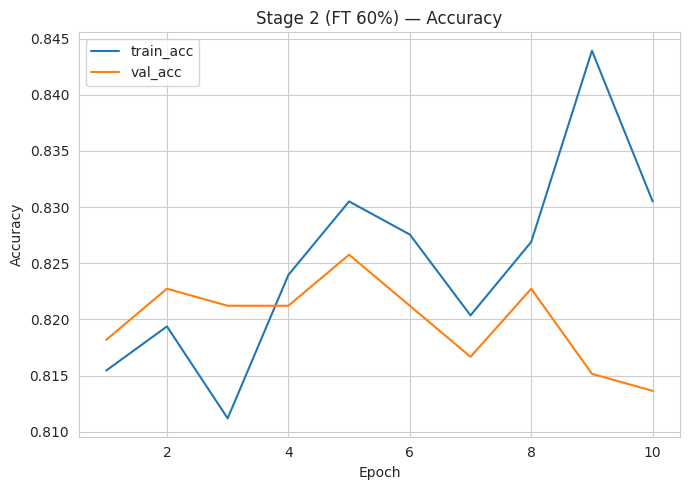

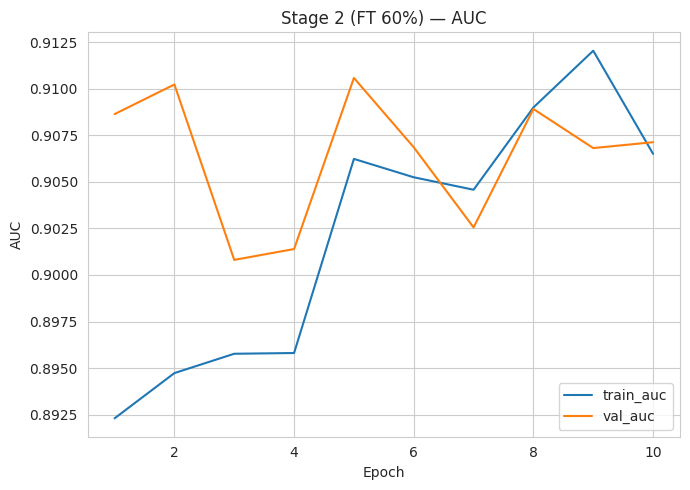


📊 EVALUATION — Stage 2 (Fine-tune last 60%)
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 666ms/step - accuracy: 0.8597 - auc: 0.8992 - loss: 0.5343 - precision: 0.8597 - recall: 0.8597

Keras metrics: {'loss': 0.5746742486953735, 'compile_metrics': 0.8137404322624207}
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 805ms/step

--- SLICE LEVEL ---
Accuracy: 81.37%

              precision    recall  f1-score   support

         HGG     0.8392    0.9145    0.8753       468
         LGG     0.7241    0.5615    0.6325       187

    accuracy                         0.8137       655
   macro avg     0.7817    0.7380    0.7539       655
weighted avg     0.8064    0.8137    0.8060       655



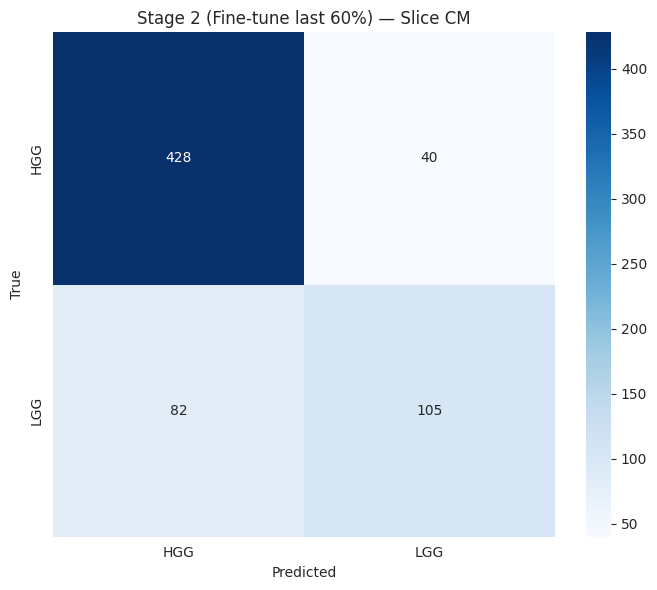

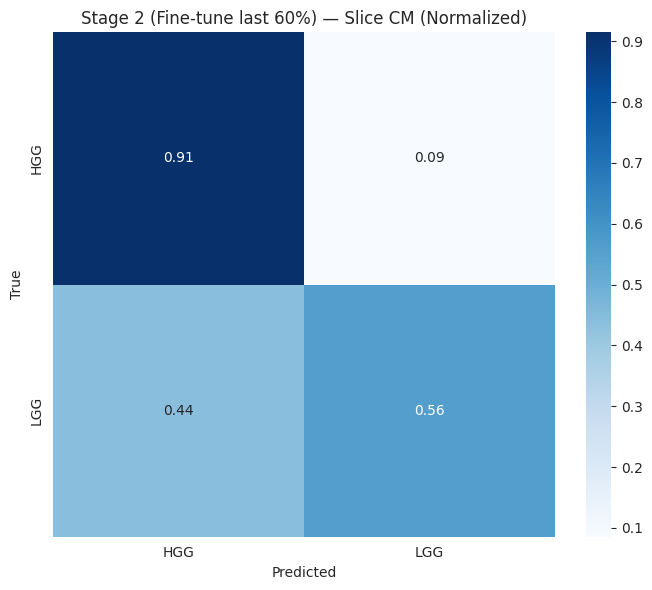


--- CASE LEVEL (Majority Vote) ---
Accuracy: 88.00%

              precision    recall  f1-score   support

         HGG     0.9024    0.9487    0.9250        39
         LGG     0.7778    0.6364    0.7000        11

    accuracy                         0.8800        50
   macro avg     0.8401    0.7925    0.8125        50
weighted avg     0.8750    0.8800    0.8755        50



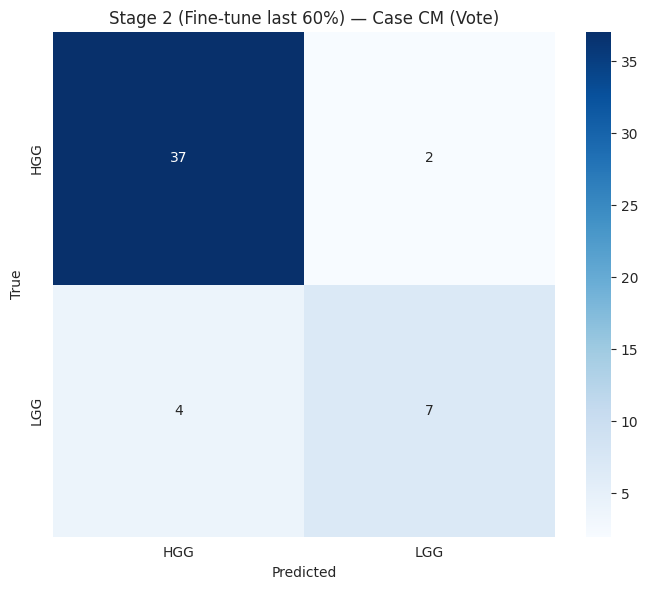

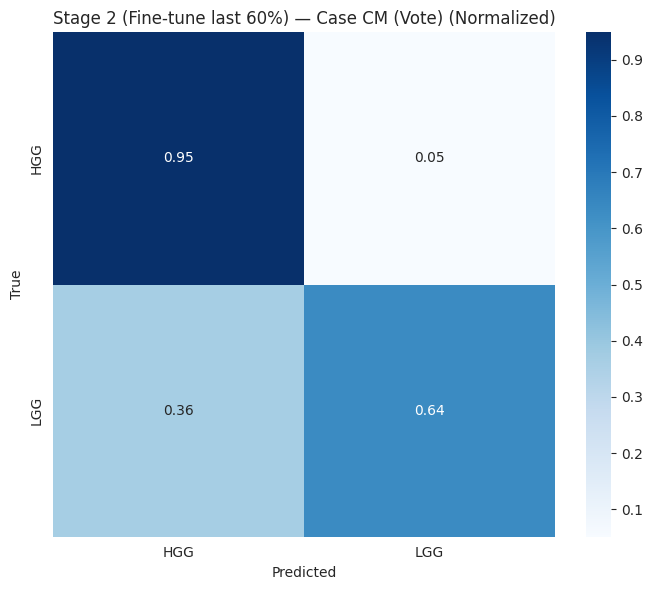


--- CASE LEVEL (Mean Probability) ---
Accuracy: 90.00%

              precision    recall  f1-score   support

         HGG     0.9250    0.9487    0.9367        39
         LGG     0.8000    0.7273    0.7619        11

    accuracy                         0.9000        50
   macro avg     0.8625    0.8380    0.8493        50
weighted avg     0.8975    0.9000    0.8983        50



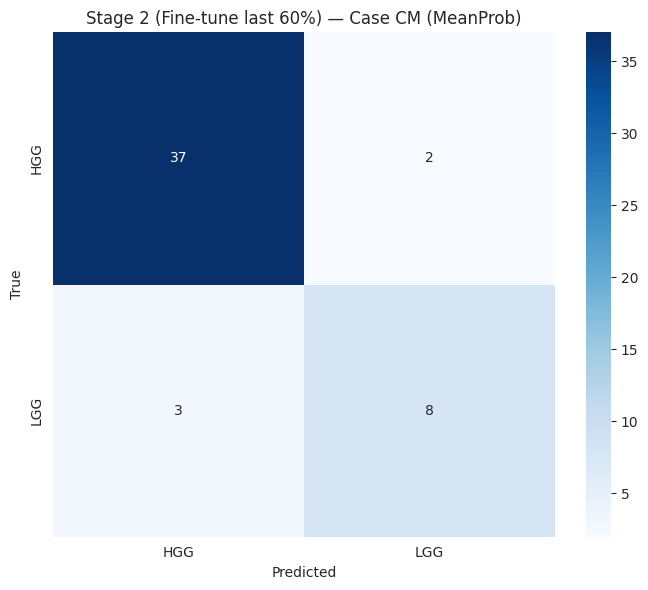

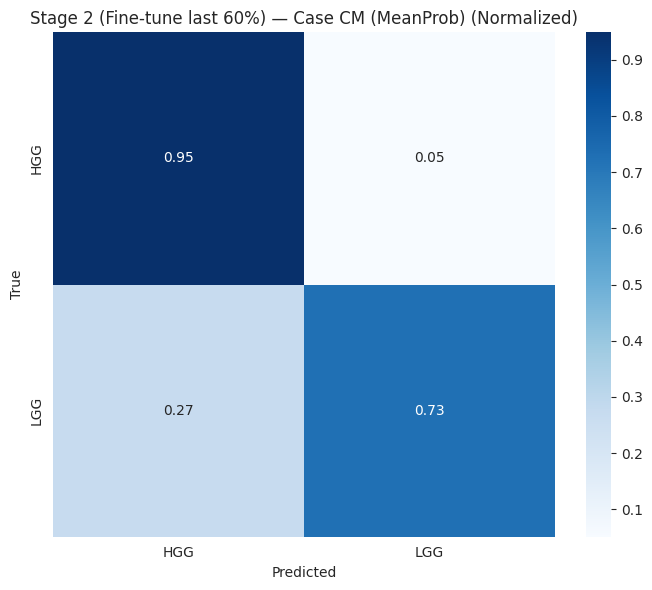

In [37]:
# ============================================================
# CELL 8 — STAGE 2 (Optional): Fine-tune last 60% of backbone
# ============================================================
set_finetune_backbone(backbone, unfreeze_ratio=0.4, freeze_batchnorm=True)
compile_model(model, lr=5e-6)

history2 = model.fit(
    train_gen_os,
    validation_data=val_gen,
    epochs=10,
    # class_weight=class_weight_dict,
    callbacks=make_callbacks("stage2_ft60"),
    verbose=1
)

plot_learning_curves(history2, title_prefix="Stage 2 (FT 60%) —")
eval_all(model, "Stage 2 (Fine-tune last 60%)", test_gen, clean_case_index)


In [ ]:
# ============================================================
# CELL — STAGE 3: Fine-tune last 60% of backbone + evaluate
# ============================================================

# 1) Unfreeze more of the backbone
set_finetune_backbone(backbone, unfreeze_ratio=0.6, freeze_batchnorm=True)

# 2) Re-compile with a smaller LR for deeper fine-tuning
compile_model(model, lr=5e-6)

# 3) Callbacks (stage-specific checkpoint name)
cbs2 = make_callbacks("stage3_ft60")

# 4) Train
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12considerably,                 # you can set 10–15
    # class_weight=class_weight_dict,
    callbacks=cbs2,
    verbose=1
)

# 5) Curves + evaluation
plot_learning_curves(history2, title_prefix="Stage 2 (FT 60%) —")
eval_all(model, "Stage 2 (Fine-tune last 60%)", test_gen, clean_case_index)


In [ ]:
# ============================================================
# CELL 9 — Optional: quick metrics comparison across stages
# ============================================================
def best_val_auc(history):
    return float(np.max(history.history.get("val_auc", [np.nan])))

def best_val_acc(history):
    return float(np.max(history.history.get("val_accuracy", [np.nan])))

rows = []
rows.append(["Stage0_Frozen", best_val_acc(history0), best_val_auc(history0)])
rows.append(["Stage1_FT20",   best_val_acc(history1), best_val_auc(history1)])

# Only if Stage 2 exists
if "history2" in globals():
    rows.append(["Stage2_FT60", best_val_acc(history2), best_val_auc(history2)])

df = pd.DataFrame(rows, columns=["Stage", "Best_Val_Acc", "Best_Val_AUC"])
df


# Custom CNN

In [38]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
# ============================================================
# CELL 2 — Helpers: learning curves + evaluation (slice + case)
# ============================================================
# Paste your existing helper functions here (the ones you shared earlier).
# They already support NUM_CLASSES=2 and CLASS_NAMES.


In [39]:
# ============================================================
# CELL 3 — Custom CNN (4ch input, 2 classes)
# ============================================================
def build_custom_cnn_hgglgg_4ch(
    input_shape=INPUT_SHAPE,   # (240,240,4)
    num_classes=NUM_CLASSES,   # 2
    head_dropout1=0.5,
    head_dropout2=0.4,
    block_dropout=(0.20, 0.20, 0.30, 0.30, 0.40),
    l2_reg=1e-4
):
    reg = regularizers.l2(l2_reg)

    inp = layers.Input(shape=input_shape, name="input_4ch")

    # ---------- Block 1 (32) ----------
    x = layers.Conv2D(32, 3, padding="same", kernel_regularizer=reg, name="block1_conv1")(inp)
    x = layers.BatchNormalization(name="block1_bn1")(x)
    x = layers.Activation("relu", name="block1_relu1")(x)

    x = layers.Conv2D(32, 3, padding="same", kernel_regularizer=reg, name="block1_conv2")(x)
    x = layers.BatchNormalization(name="block1_bn2")(x)
    x = layers.Activation("relu", name="block1_relu2")(x)

    x = layers.MaxPooling2D(2, name="block1_pool")(x)  # 240 -> 120
    x = layers.Dropout(block_dropout[0], name="block1_dropout")(x)

    # ---------- Block 2 (64) ----------
    x = layers.Conv2D(64, 3, padding="same", kernel_regularizer=reg, name="block2_conv1")(x)
    x = layers.BatchNormalization(name="block2_bn1")(x)
    x = layers.Activation("relu", name="block2_relu1")(x)

    x = layers.Conv2D(64, 3, padding="same", kernel_regularizer=reg, name="block2_conv2")(x)
    x = layers.BatchNormalization(name="block2_bn2")(x)
    x = layers.Activation("relu", name="block2_relu2")(x)

    x = layers.MaxPooling2D(2, name="block2_pool")(x)  # 120 -> 60
    x = layers.Dropout(block_dropout[1], name="block2_dropout")(x)

    # ---------- Block 3 (128) ----------
    x = layers.Conv2D(128, 3, padding="same", kernel_regularizer=reg, name="block3_conv1")(x)
    x = layers.BatchNormalization(name="block3_bn1")(x)
    x = layers.Activation("relu", name="block3_relu1")(x)

    x = layers.Conv2D(128, 3, padding="same", kernel_regularizer=reg, name="block3_conv2")(x)
    x = layers.BatchNormalization(name="block3_bn2")(x)
    x = layers.Activation("relu", name="block3_relu2")(x)

    x = layers.Conv2D(128, 3, padding="same", kernel_regularizer=reg, name="block3_conv3")(x)
    x = layers.BatchNormalization(name="block3_bn3")(x)
    x = layers.Activation("relu", name="block3_relu3")(x)

    x = layers.MaxPooling2D(2, name="block3_pool")(x)  # 60 -> 30
    x = layers.Dropout(block_dropout[2], name="block3_dropout")(x)

    # ---------- Block 4 (256) ----------
    x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=reg, name="block4_conv1")(x)
    x = layers.BatchNormalization(name="block4_bn1")(x)
    x = layers.Activation("relu", name="block4_relu1")(x)

    x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=reg, name="block4_conv2")(x)
    x = layers.BatchNormalization(name="block4_bn2")(x)
    x = layers.Activation("relu", name="block4_relu2")(x)

    x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=reg, name="block4_conv3")(x)
    x = layers.BatchNormalization(name="block4_bn3")(x)
    x = layers.Activation("relu", name="block4_relu3")(x)

    x = layers.MaxPooling2D(2, name="block4_pool")(x)  # 30 -> 15
    x = layers.Dropout(block_dropout[3], name="block4_dropout")(x)

    # ---------- Block 5 (512) ----------
    x = layers.Conv2D(512, 3, padding="same", kernel_regularizer=reg, name="block5_conv1")(x)
    x = layers.BatchNormalization(name="block5_bn1")(x)
    x = layers.Activation("relu", name="block5_relu1")(x)

    x = layers.Conv2D(512, 3, padding="same", kernel_regularizer=reg, name="block5_conv2")(x)
    x = layers.BatchNormalization(name="block5_bn2")(x)
    x = layers.Activation("relu", name="block5_relu2")(x)

    x = layers.Conv2D(512, 3, padding="same", kernel_regularizer=reg, name="block5_conv3")(x)
    x = layers.BatchNormalization(name="block5_bn3")(x)
    x = layers.Activation("relu", name="block5_relu3")(x)

    x = layers.MaxPooling2D(2, name="block5_pool")(x)  # 15 -> 7
    x = layers.Dropout(block_dropout[4], name="block5_dropout")(x)

    # ---------- Head ----------
    h = layers.GlobalAveragePooling2D(name="gap")(x)
    h = layers.Dropout(head_dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", kernel_regularizer=reg, name="fc1")(h)
    h = layers.BatchNormalization(name="bn_head")(h)
    h = layers.Dropout(head_dropout2, name="drop2")(h)
    out = layers.Dense(num_classes, activation="softmax", name="pred")(h)

    model = Model(inp, out, name="CustomCNN_HGG_LGG_4ch")
    return model


In [40]:
# ============================================================
# CELL 4 — Compile + callbacks
# ============================================================
def compile_custom_cnn(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )

def make_callbacks(stage_name):
    return [
        ModelCheckpoint(
            filepath=f"best_customcnn_{stage_name}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1
        )
    ]


Model: "CustomCNN_HGG_LGG_4ch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_4ch (InputLayer)          │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 60, 60, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 60, 60, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn3 (BatchNormalization) │ (None, 60, 60, 128)    │           51

 Total params: 7,954,370 (30.34 MB)

 Trainable params: 7,948,098 (30.32 MB)

 Non-trainable params: 6,272 (24.50 KB)

None
Epoch 1/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6744 - auc: 0.7130 - loss: 1.1705 - precision: 0.6744 - recall: 0.6744
Epoch 1: val_auc improved from -inf to 0.39982, saving model to best_customcnn_stage0.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.6743 - auc: 0.7130 - loss: 1.1702 - precision: 0.6743 - recall: 0.6743 - val_accuracy: 0.3424 - val_auc: 0.3998 - val_loss: 1.0038 - val_precision: 0.3424 - val_recall: 0.3424 - learning_rate: 0.0010
Epoch 2/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.6723 - auc: 0.7354 - loss: 1.0145 - precision: 0.6723 - recall: 0.6723
Epoch 2: val_auc improved from 0.39982 to 0.69263, saving model to best_customcnn_stage0.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 968ms/step - accuracy: 0.6725 - auc: 0.7356 - loss: 1.0141 - precision: 0.6725 - recall: 0.6725 - val_accuracy: 0.6955 - val_auc: 0.6926 - val_loss: 1.1821 - val_precision: 0.6955 - val_recall: 0.6955 - learning_rate: 0.0010
Epoch 3/40
96/96 ━━━━━━━━━━

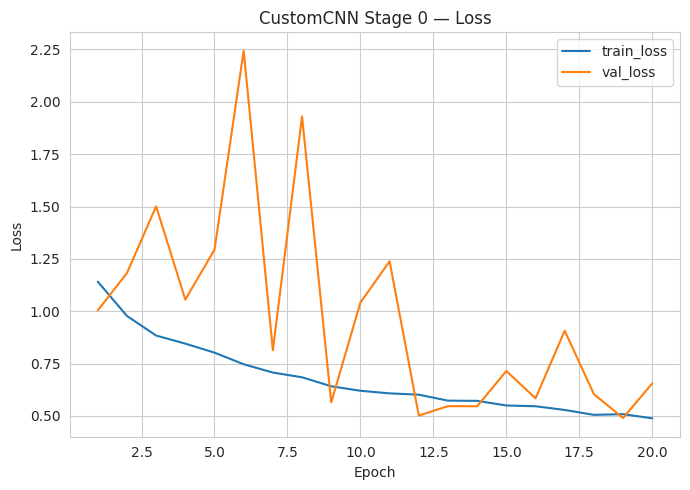

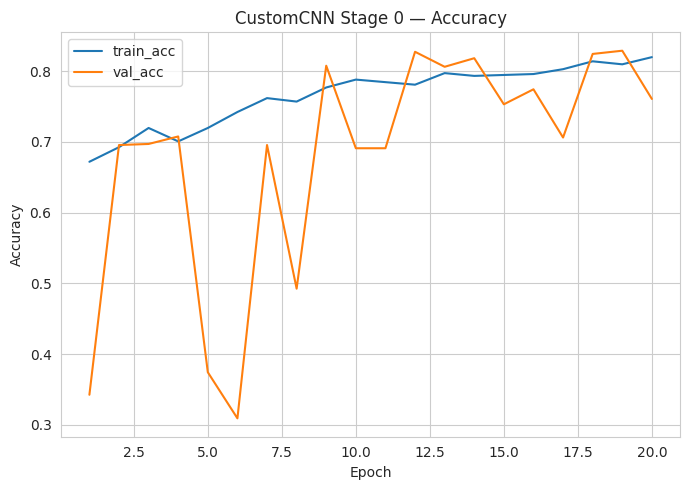

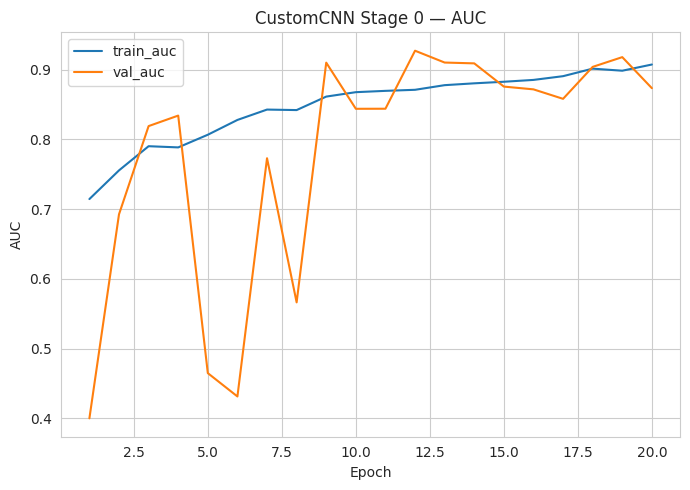


📊 EVALUATION — CustomCNN Stage 0 (Scratch)
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 525ms/step - accuracy: 0.8183 - auc: 0.9187 - loss: 0.5107 - precision: 0.8183 - recall: 0.8183

Keras metrics: {'loss': 0.5989925861358643, 'compile_metrics': 0.7862595319747925}
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step

--- SLICE LEVEL ---
Accuracy: 78.63%

              precision    recall  f1-score   support

         HGG     0.8402    0.8654    0.8526       468
         LGG     0.6358    0.5882    0.6111       187

    accuracy                         0.7863       655
   macro avg     0.7380    0.7268    0.7319       655
weighted avg     0.7819    0.7863    0.7837       655



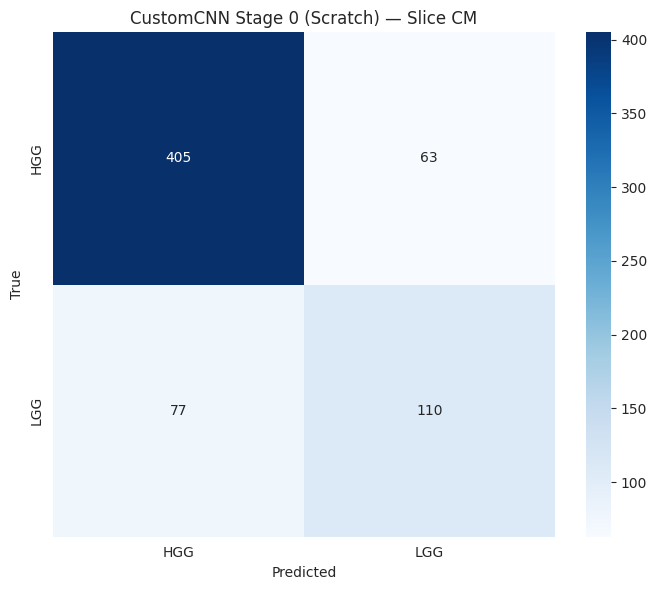

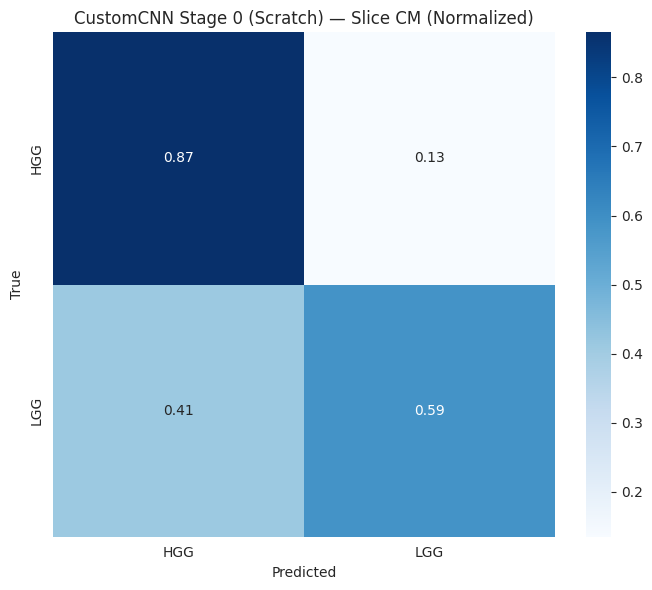


--- CASE LEVEL (Majority Vote) ---
Accuracy: 86.00%

              precision    recall  f1-score   support

         HGG     0.9000    0.9231    0.9114        39
         LGG     0.7000    0.6364    0.6667        11

    accuracy                         0.8600        50
   macro avg     0.8000    0.7797    0.7890        50
weighted avg     0.8560    0.8600    0.8576        50



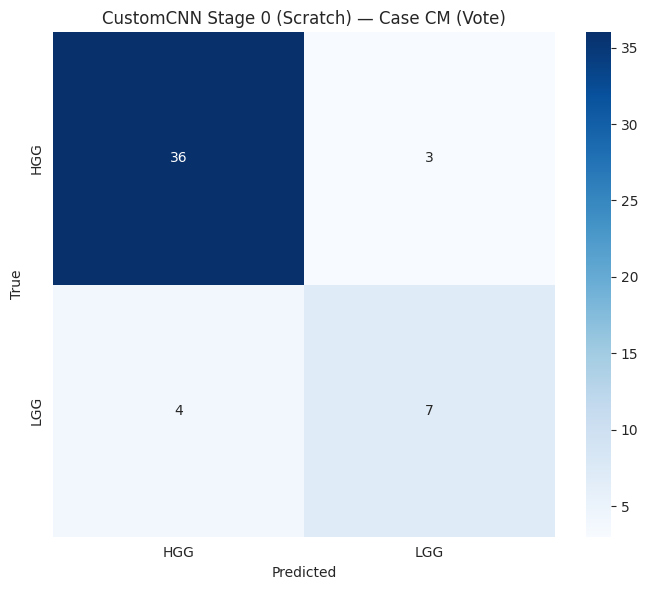

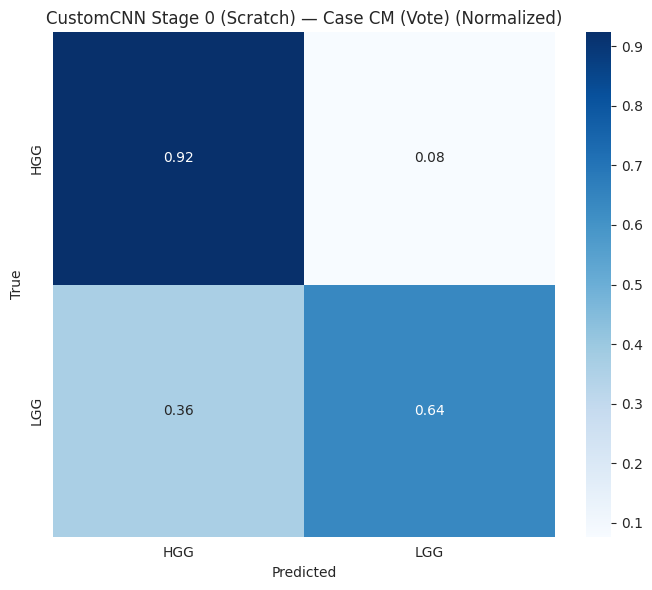


--- CASE LEVEL (Mean Probability) ---
Accuracy: 88.00%

              precision    recall  f1-score   support

         HGG     0.9231    0.9231    0.9231        39
         LGG     0.7273    0.7273    0.7273        11

    accuracy                         0.8800        50
   macro avg     0.8252    0.8252    0.8252        50
weighted avg     0.8800    0.8800    0.8800        50



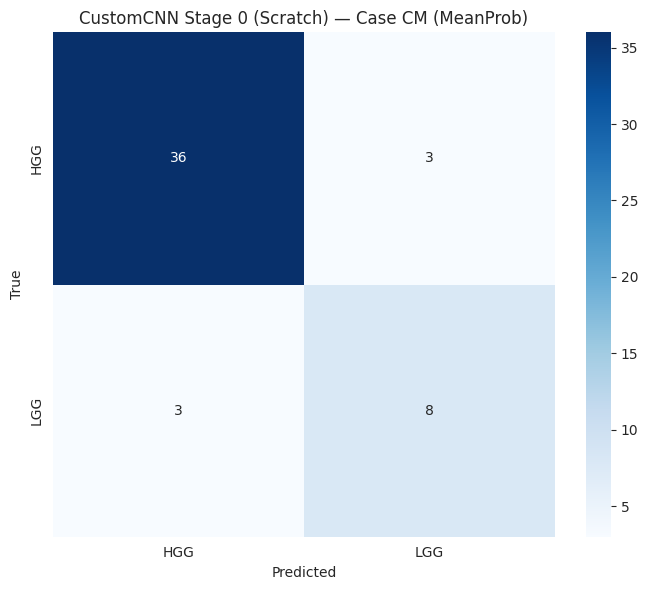

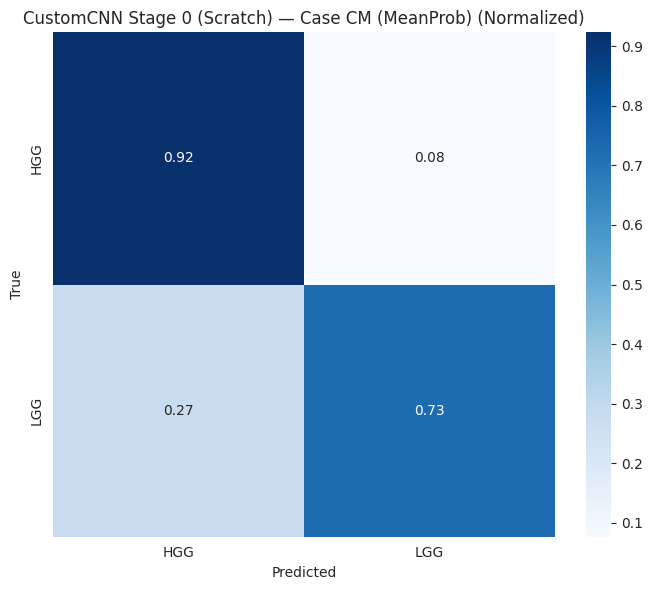

In [41]:
# ============================================================
# CELL 5 — STAGE 0: Train custom CNN from scratch + evaluate
# ============================================================
model_cnn_s0 = build_custom_cnn_hgglgg_4ch(
    head_dropout1=0.50,
    head_dropout2=0.40,
    block_dropout=(0.20, 0.20, 0.30, 0.30, 0.40),
    l2_reg=1e-4
)

compile_custom_cnn(model_cnn_s0, lr=1e-3)
print(model_cnn_s0.summary())

history_s0 = model_cnn_s0.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=make_callbacks("stage0"),
    verbose=1
)

plot_learning_curves(history_s0, title_prefix="CustomCNN Stage 0 —")
eval_all(model_cnn_s0, "CustomCNN Stage 0 (Scratch)", test_gen, clean_case_index)


In [42]:
# ============================================================
# CELL 6 — STAGE 1: Build same model with reduced dropout + transfer weights
# ============================================================
model_cnn_s1 = build_custom_cnn_hgglgg_4ch(
    head_dropout1=0.30,  # reduced
    head_dropout2=0.20,  # reduced
    block_dropout=(0.15, 0.15, 0.20, 0.20, 0.30),  # reduced
    l2_reg=1e-4
)

# Transfer weights by layer name (Dropout has no weights anyway)
transferred = 0
for layer in model_cnn_s1.layers:
    try:
        src = model_cnn_s0.get_layer(layer.name)
        w = src.get_weights()
        if w:
            layer.set_weights(w)
            transferred += 1
    except ValueError:
        pass

print(f"✅ Weight transfer done. Layers transferred: {transferred} / {len(model_cnn_s1.layers)}")


✅ Weight transfer done. Layers transferred: 29 / 56


Epoch 1/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.8083 - auc: 0.8843 - loss: 0.5627 - precision: 0.8083 - recall: 0.8083
Epoch 1: val_auc improved from -inf to 0.88181, saving model to best_customcnn_stage1_reduced_dropout.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 108s 898ms/step - accuracy: 0.8083 - auc: 0.8843 - loss: 0.5626 - precision: 0.8083 - recall: 0.8083 - val_accuracy: 0.7909 - val_auc: 0.8818 - val_loss: 0.5945 - val_precision: 0.7909 - val_recall: 0.7909 - learning_rate: 1.0000e-04
Epoch 2/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.8115 - auc: 0.8949 - loss: 0.5276 - precision: 0.8115 - recall: 0.8115
Epoch 2: val_auc did not improve from 0.88181
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 758ms/step - accuracy: 0.8115 - auc: 0.8948 - loss: 0.5278 - precision: 0.8115 - recall: 0.8115 - val_accuracy: 0.7500 - val_auc: 0.8660 - val_loss: 0.7935 - val_precision: 0.7500 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 3/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step

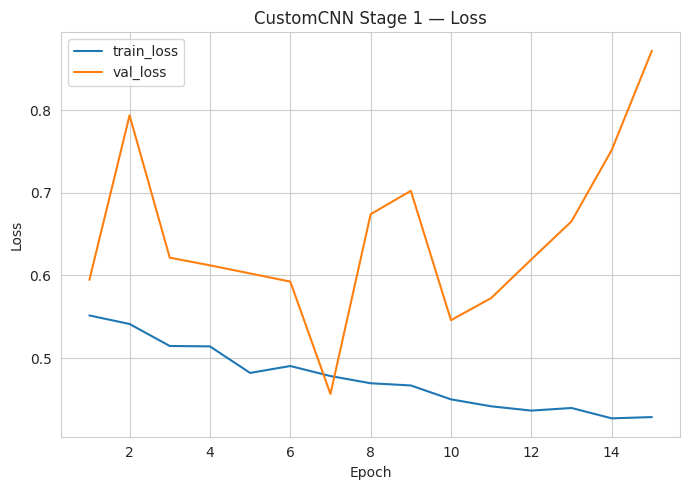

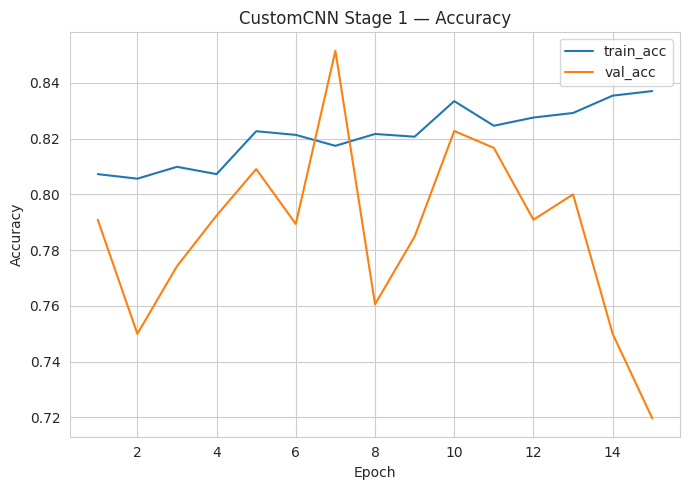

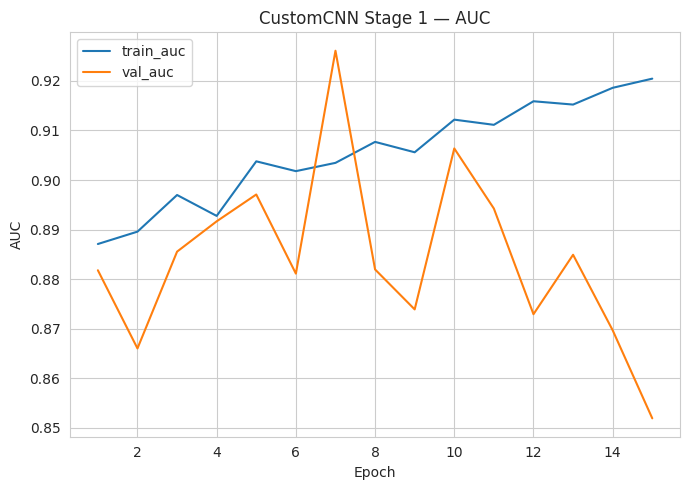


📊 EVALUATION — CustomCNN Stage 1 (Reduced Dropout, Weight Transfer)
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 541ms/step - accuracy: 0.8280 - auc: 0.9185 - loss: 0.4640 - precision: 0.8280 - recall: 0.8280

Keras metrics: {'loss': 0.5681979656219482, 'compile_metrics': 0.7694656252861023}
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step

--- SLICE LEVEL ---
Accuracy: 76.95%

              precision    recall  f1-score   support

         HGG     0.8323    0.8483    0.8402       468
         LGG     0.6011    0.5722    0.5863       187

    accuracy                         0.7695       655
   macro avg     0.7167    0.7102    0.7133       655
weighted avg     0.7663    0.7695    0.7677       655



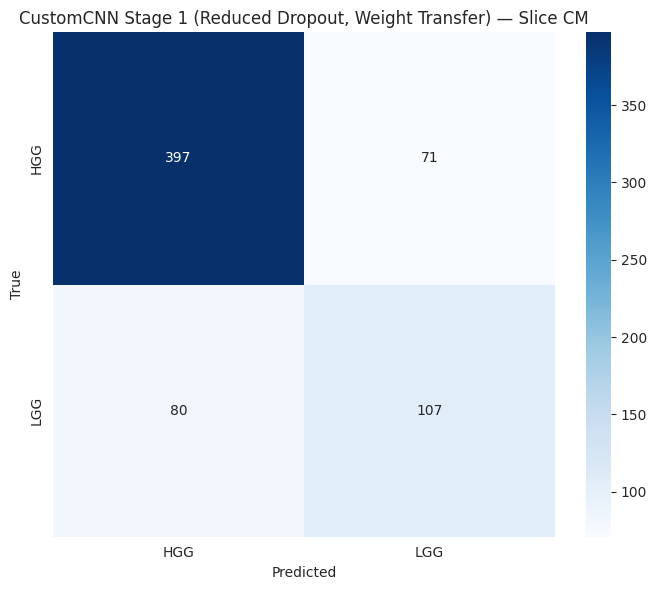

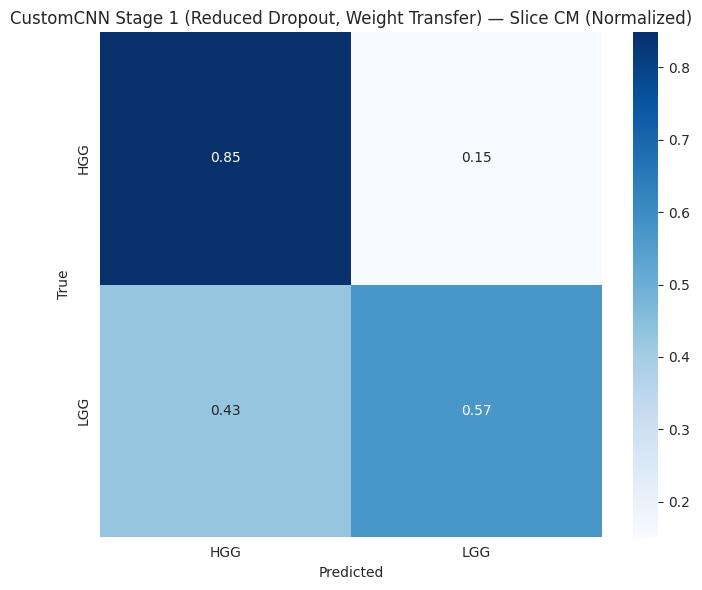


--- CASE LEVEL (Majority Vote) ---
Accuracy: 78.00%

              precision    recall  f1-score   support

         HGG     0.8684    0.8462    0.8571        39
         LGG     0.5000    0.5455    0.5217        11

    accuracy                         0.7800        50
   macro avg     0.6842    0.6958    0.6894        50
weighted avg     0.7874    0.7800    0.7834        50



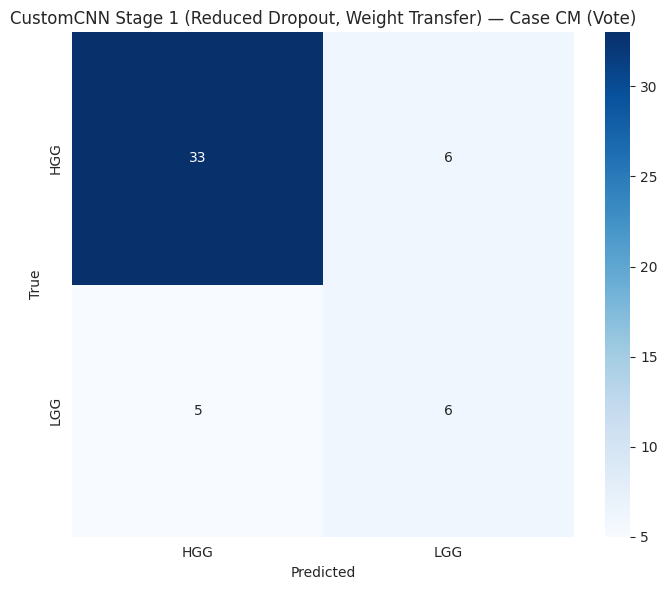

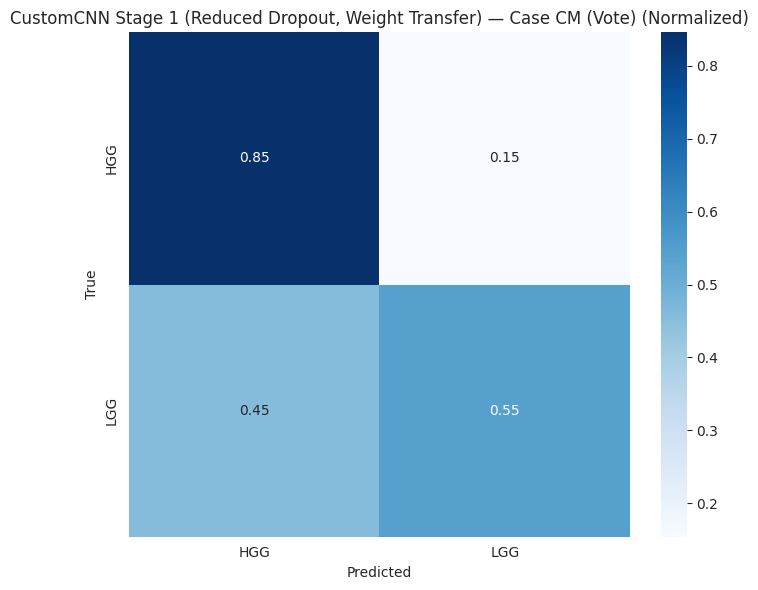


--- CASE LEVEL (Mean Probability) ---
Accuracy: 80.00%

              precision    recall  f1-score   support

         HGG     0.8718    0.8718    0.8718        39
         LGG     0.5455    0.5455    0.5455        11

    accuracy                         0.8000        50
   macro avg     0.7086    0.7086    0.7086        50
weighted avg     0.8000    0.8000    0.8000        50



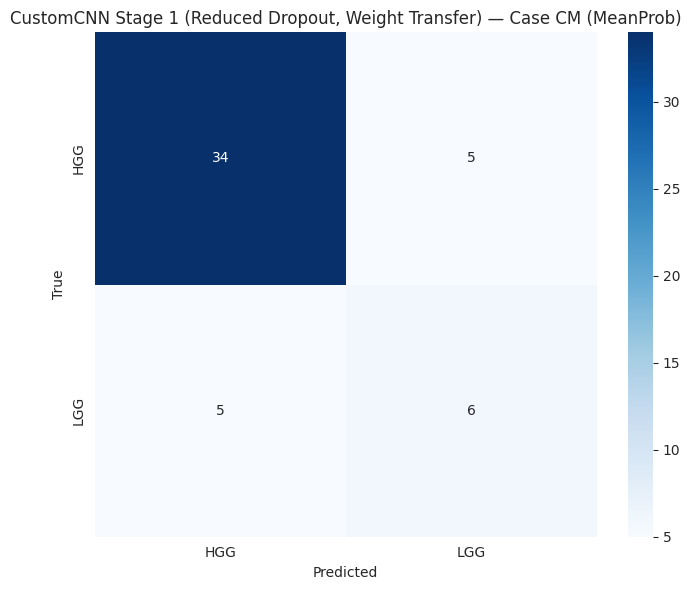

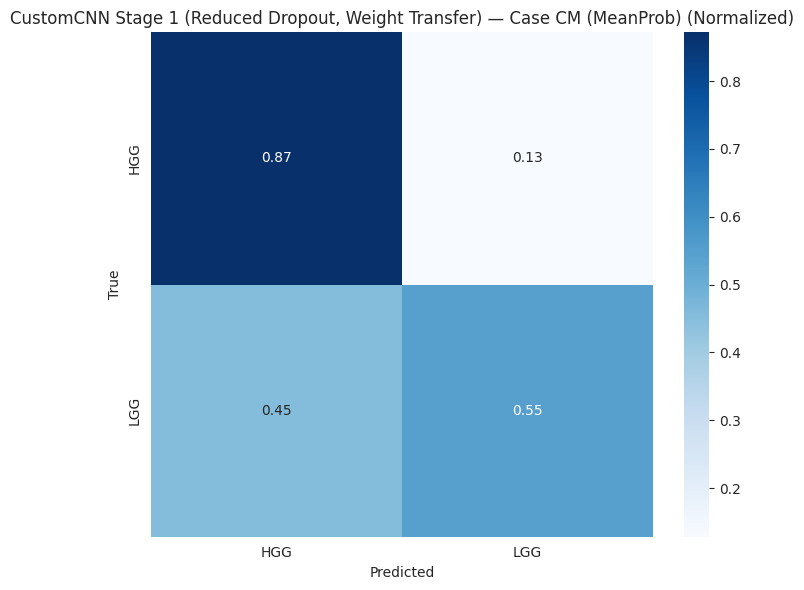

In [43]:
# ============================================================
# CELL 7 — STAGE 1: Fine-tune with reduced dropout + evaluate
# ============================================================
compile_custom_cnn(model_cnn_s1, lr=1e-4)

history_s1 = model_cnn_s1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=make_callbacks("stage1_reduced_dropout"),
    verbose=1
)

plot_learning_curves(history_s1, title_prefix="CustomCNN Stage 1 —")
eval_all(model_cnn_s1, "CustomCNN Stage 1 (Reduced Dropout, Weight Transfer)", test_gen, clean_case_index)


In [ ]:
# ============================================================
# CELL 8 — Optional: sanity check weight equality on one layer
# ============================================================
layer_name = "block3_conv2"
w0 = model_cnn_s0.get_layer(layer_name).get_weights()
w1 = model_cnn_s1.get_layer(layer_name).get_weights()

print(layer_name, "same weights?", all([np.allclose(a, b) for a, b in zip(w0, w1)]))


In [44]:
# ============================================================
# CELL — STAGE 2: Build same model with even lower dropout
#         + transfer weights from Stage 1
# ============================================================

model_cnn_s2 = build_custom_cnn_hgglgg_4ch(
    head_dropout1=0.15,  # reduced more
    head_dropout2=0.10,  # reduced more
    block_dropout=(0.10, 0.10, 0.15, 0.15, 0.20),  # reduced more
    l2_reg=1e-4
)

# Transfer weights from Stage 1 -> Stage 2
transferred = 0
for layer in model_cnn_s2.layers:
    try:
        src = model_cnn_s1.get_layer(layer.name)
        w = src.get_weights()
        if w:
            layer.set_weights(w)
            transferred += 1
    except ValueError:
        pass

print(f"✅ Stage 2 weight transfer done. Layers transferred: {transferred} / {len(model_cnn_s2.layers)}")


✅ Stage 2 weight transfer done. Layers transferred: 29 / 56


Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 981ms/step - accuracy: 0.8208 - auc: 0.9011 - loss: 0.4836 - precision: 0.8208 - recall: 0.8208
Epoch 1: val_auc improved from -inf to 0.88862, saving model to best_customcnn_stage2_more_reduced_dropout.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8208 - auc: 0.9012 - loss: 0.4835 - precision: 0.8208 - recall: 0.8208 - val_accuracy: 0.7955 - val_auc: 0.8886 - val_loss: 0.6100 - val_precision: 0.7955 - val_recall: 0.7955 - learning_rate: 3.0000e-05
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.8384 - auc: 0.9151 - loss: 0.4486 - precision: 0.8384 - recall: 0.8384
Epoch 2: val_auc improved from 0.88862 to 0.89300, saving model to best_customcnn_stage2_more_reduced_dropout.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 981ms/step - accuracy: 0.8382 - auc: 0.9150 - loss: 0.4487 - precision: 0.8382 - recall: 0.8382 - val_accuracy: 0.8106 - val_auc: 0.8930 - val_loss: 0.5988 - val_precision: 0.8106 - val_recall: 0.8106 - learn

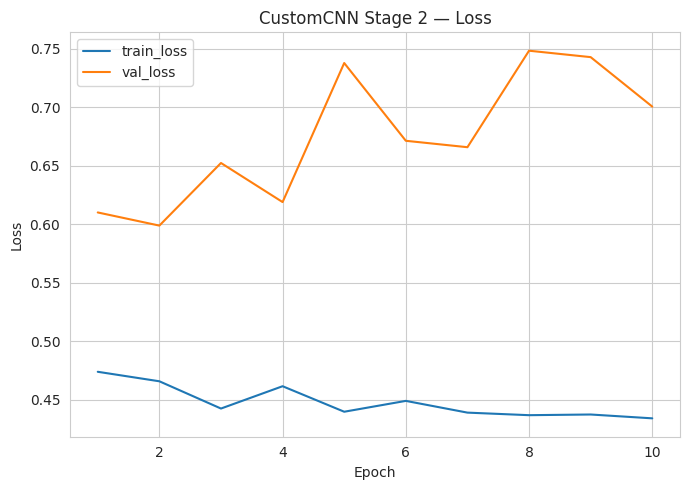

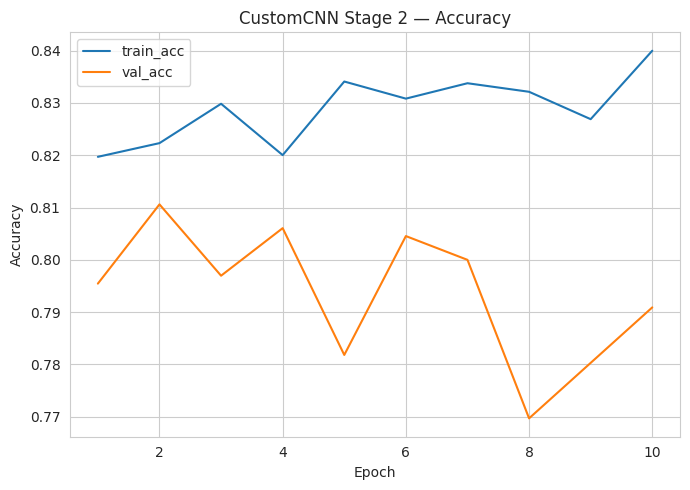

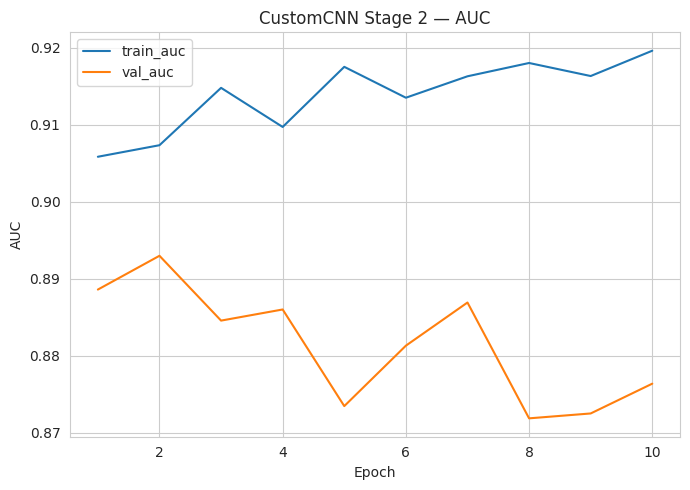


📊 EVALUATION — CustomCNN Stage 2 (More Reduced Dropout, Weight Transfer)
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 313ms/step - accuracy: 0.8246 - auc: 0.9158 - loss: 0.5021 - precision: 0.8246 - recall: 0.8246

Keras metrics: {'loss': 0.7065520286560059, 'compile_metrics': 0.7343511581420898}
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step

--- SLICE LEVEL ---
Accuracy: 73.44%

              precision    recall  f1-score   support

         HGG     0.7500    0.9423    0.8352       468
         LGG     0.5970    0.2139    0.3150       187

    accuracy                         0.7344       655
   macro avg     0.6735    0.5781    0.5751       655
weighted avg     0.7063    0.7344    0.6867       655



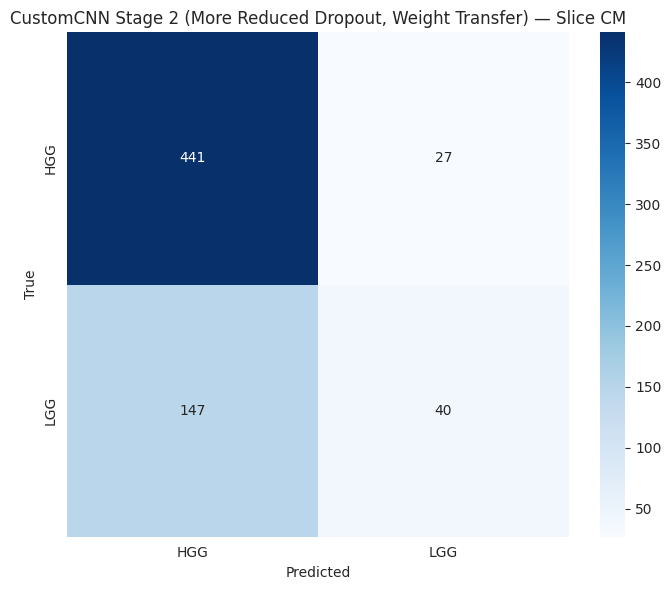

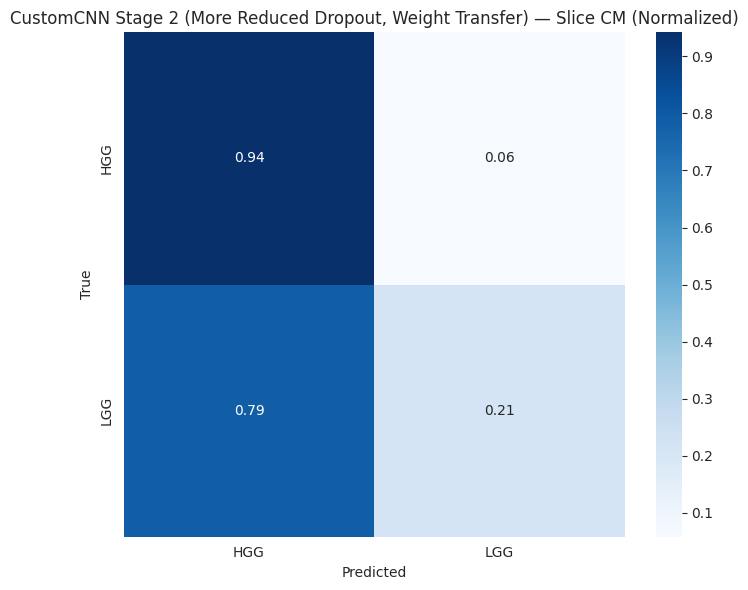


--- CASE LEVEL (Majority Vote) ---
Accuracy: 82.00%

              precision    recall  f1-score   support

         HGG     0.8261    0.9744    0.8941        39
         LGG     0.7500    0.2727    0.4000        11

    accuracy                         0.8200        50
   macro avg     0.7880    0.6235    0.6471        50
weighted avg     0.8093    0.8200    0.7854        50



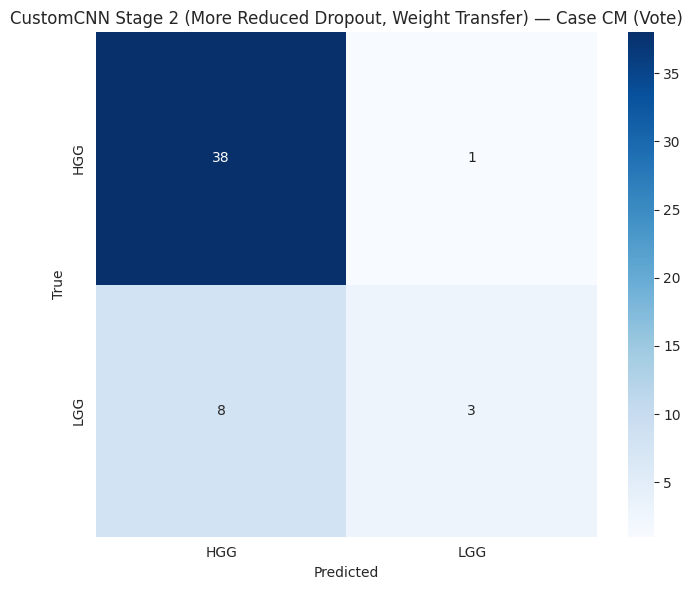

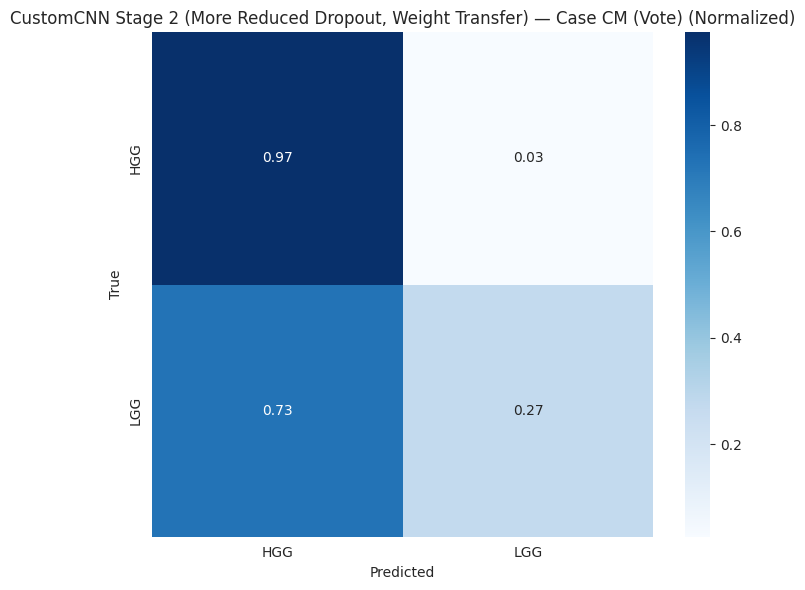


--- CASE LEVEL (Mean Probability) ---
Accuracy: 84.00%

              precision    recall  f1-score   support

         HGG     0.8298    1.0000    0.9070        39
         LGG     1.0000    0.2727    0.4286        11

    accuracy                         0.8400        50
   macro avg     0.9149    0.6364    0.6678        50
weighted avg     0.8672    0.8400    0.8017        50



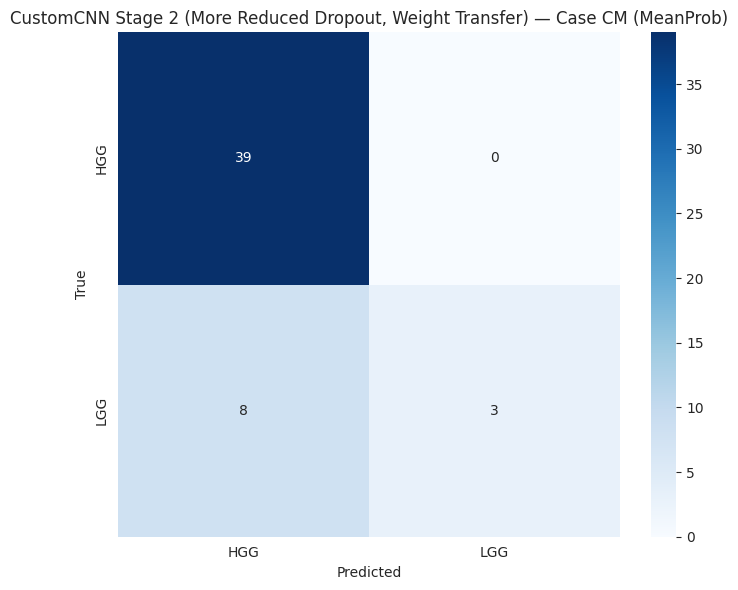

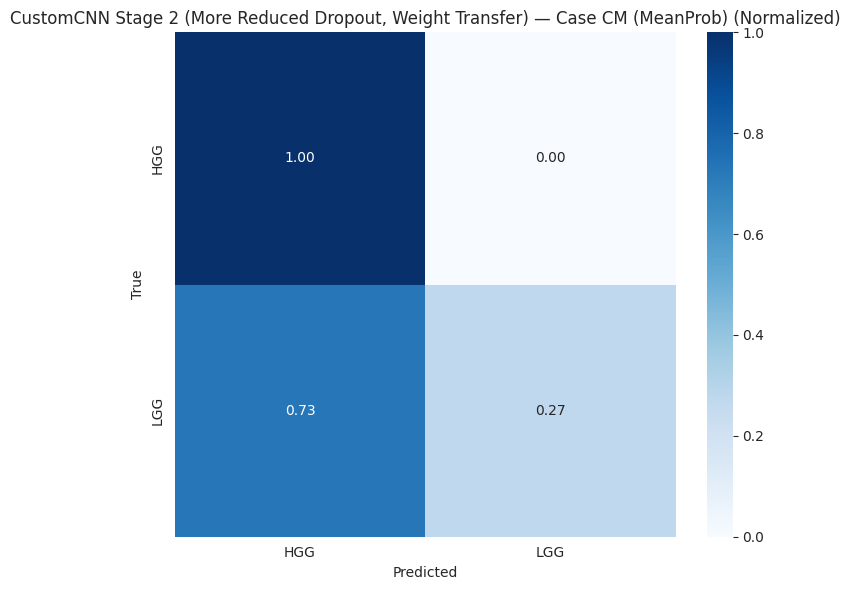

In [45]:
# ============================================================
# CELL — STAGE 2: Fine-tune with very low LR + evaluate
# ============================================================

compile_custom_cnn(model_cnn_s2, lr=3e-5)

history_s2 = model_cnn_s2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,  # usually enough for stage 2
    class_weight=class_weight_dict,
    callbacks=make_callbacks("stage2_more_reduced_dropout"),
    verbose=1
)

plot_learning_curves(history_s2, title_prefix="CustomCNN Stage 2 —")
eval_all(model_cnn_s2, "CustomCNN Stage 2 (More Reduced Dropout, Weight Transfer)", test_gen, clean_case_index)


In [ ]:
compile_custom_cnn(model_cnn_s2, lr=1e-5)
